<a href="https://colab.research.google.com/github/ryeongeo/EdgeVL_attention_semantic/blob/main/EdgeVL_v4_attention_semantic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EdgeVL V4 — RGB–Depth Attention × Semantic KD



| Cell | 구성 | 결과 |
|---|---|---|
| 01 | 패키지 설치·GPU 확인 | 실행 환경 및 버전 확인 |
| 02 | 공통 설정·경로·seed·저장 함수 | V4 출력 경로, 3 seeds, 실험 설정 |
| 03 | SUN RGB-D 데이터 다운로드·압축 해제 | RGB/Depth 및 공식 split 준비 |
| 04 | 19개 클래스·train/validation/test 구성 | 고정 split과 샘플 manifest |
| 05 | RGB–Depth 전처리·Dataset·DataLoader | 공간 정렬 및 depth 복원 검사 |
| 06 | Teacher·텍스트 임베딩 | CLIP 교사와 클래스 prompt ensemble |
| 07 | Student·spatial feature 추출 | ResNet-18 전역·공간 특징 |
| 08 | Teacher feature 캐시 | 전역·공간 target 및 텍스트 신호 |
| 09 | 공통 warm-up·frozen anchor | seed별 공통 초기값 |
| 10 | Cross-Modal Attention Adapter | Depth Q, RGB K/V, residual adapter |
| 11 | Text semantic relevance | RGB 공간 특징의 텍스트 관련성 |
| 12 | Attention importance | attention 기반 중요도 및 진단 |
| 13 | Attended teacher target | attention으로 정렬한 교사 공간 target |
| 14 | A~F mode별 loss 분기 | 공통 손실과 모드별 공간 KD |
| 15 | F_SHUFFLED_RGB | 자기 자신을 제외한 고정 RGB donor |
| 16 | 1-batch forward/backward 검사 | shape·finite loss·gradient·shuffle 검사 |
| 17 | Training / validation loop | 학습 로그·검증·best/last 저장 |
| 18 | 3-seed × 6-mode 실행·재개 | 동일 seed 내 공정한 비교 |
| 19 | 최종 checkpoint 평가 | Depth 단독과 paired 추론 지표 구분 |
| 20 | 최종 결과표·분석 metric 저장 | 평균±표준편차·클래스별 결과·예측·가중치 진단 |



## Cell 01. 패키지 설치 및 GPU 환경 확인
설치 후 import와 GPU 인식을 확인하고 ENV_INFO를 만든다. 이 정보는 Cell 02에서 실행 설정과 함께 저장한다.


In [ ]:
# Cell 01 — 패키지 설치 및 GPU 환경 확인
import sys
import subprocess
import platform
import importlib.metadata as md

PACKAGES = [
    "open_clip_torch==3.3.0",
    "scipy",
    "scikit-learn",
    "pandas",
    "matplotlib",
    "tqdm",
    "pillow",
]
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", *PACKAGES
])

import torch
import torchvision
import open_clip
import numpy as np
import pandas as pd
import scipy
from PIL import Image

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU가 필요하다. Colab에서 런타임 → 런타임 유형 변경 → GPU를 선택한 뒤 다시 실행하자."
    )

DEVICE = torch.device("cuda")
gpu = torch.cuda.get_device_properties(0)
ENV_INFO = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "open_clip_torch": md.version("open_clip_torch"),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "cuda_runtime": torch.version.cuda,
    "gpu_name": gpu.name,
    "gpu_total_gib": round(gpu.total_memory / 1024**3, 2),
}
for key, value in ENV_INFO.items():
    print(f"{key}: {value}")
print("\nCell 01 완료 — 패키지 import 및 GPU 인식 확인")


python: 3.13.15
torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
open_clip_torch: 3.3.0
numpy: 2.1.3
pandas: 2.2.3
scipy: 1.16.3
cuda_runtime: 12.8
gpu_name: NVIDIA L4
gpu_total_gib: 22.03

Cell 01 완료 — 패키지 import 및 GPU 인식 확인


##Cell 02 — V4 공통 설정·경로·seed·저장 함수
기본 설정은 batch 32 / warm-up 5 epoch / mode별 20 epoch / FP16 AMP이다. Seed와 deterministic 옵션을 설정해 같은 환경에서 비교의 재현성을 높인다.

In [ ]:
# Cell 02 — V4 공통 설정·경로·seed·저장 함수
from pathlib import Path
import os
import json
import math
import random
import time
import copy
import hashlib

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from google.colab import drive

drive.mount("/content/drive")

MODES = [
    "A_UNIFORM", "B_TEXT", "C_ADAPTER",
    "D_ATTN_WEIGHT", "E_ATTN_SEMANTIC", "F_SHUFFLED_RGB",
]

CLASS_NAMES = [
    "bathroom", "bedroom", "classroom", "computer_room",
    "conference_room", "corridor", "dining_area", "dining_room",
    "discussion_area", "furniture_store", "home_office", "kitchen",
    "lab", "lecture_theatre", "library", "living_room",
    "office", "rest_space", "study_space",
]

PROMPT_TEMPLATES = [
    "a photo of a {}.",
    "an indoor scene of a {}.",
    "a room that is a {}.",
]

CFG = {
    "code_version": "v4.0.2",

    # 모델
    "teacher": "ViT-B-16-quickgelu",
    "teacher_pretrained": "openai",
    "student": "resnet18",
    "img_size": 224,
    "feature_dim": 512,

    # 데이터·학습
    "batch_size": 32,
    "num_workers": 0,
    "split_seed": 42,
    "val_fraction": 0.15,
    "seeds": [42, 3407, 2026],
    "warmup_epochs": 5,
    "experiment_epochs": 20,
    "lr": 1e-4,
    "weight_decay": 0.01,

    # 공통 loss·semantic weighting
    "local_coef": 0.20,
    "text_coef": 1.0,
    "text_logit_scale": 30.0,
    "class_tau": 0.05,
    "token_tau": 0.10,
    "weight_floor": 0.05,

    # Cross-modal attention
    "attn_dim": 512,
    "attn_heads": 4,
    "attn_dropout": 0.0,

    # 전처리·실행
    "max_depth_m": 10.0,
    "shard_size": 128,
    "amp": True,
    "amp_dtype": "float16",
    "selection": "depth_acc",
    "freeze_bn_stats": True,

    # 설정 파일에 함께 보관
    "modes": MODES,
    "class_names": CLASS_NAMES,
    "prompt_templates": PROMPT_TEMPLATES,
}

assert len(CLASS_NAMES) == 19
assert CFG["attn_dim"] % CFG["attn_heads"] == 0

# checkpoint·결과는 Drive,
# 압축 해제 데이터·캐시는 Colab 로컬에 저장한다.
ROOT = Path(
    "/content/drive/MyDrive/rgb_depth_kd_pilot/v4_attention_semantic"
)
ARCHIVE_DIR = ROOT.parent / "data" / "downloads"
RAW_BASE = Path("/content/sunrgbd_v4_raw")
LOCAL_CACHE = Path("/content/edgevl_v4_cache")

# 설정이 같으면 같은 경로, 설정이 달라지면 다른 경로 사용
config_text = json.dumps(CFG, sort_keys=True, ensure_ascii=False)
CONFIG_ID = hashlib.sha256(config_text.encode()).hexdigest()[:12]
OUT = ROOT / "runs" / CONFIG_ID

for p in (ARCHIVE_DIR, RAW_BASE, LOCAL_CACHE, OUT):
    p.mkdir(parents=True, exist_ok=True)

AMP_DTYPE = torch.float16
device = DEVICE  # Cell 01에서 만든 CUDA device


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)


def atomic_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    tmp.write_text(
        json.dumps(obj, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    os.replace(tmp, path)


def atomic_save(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def run_paths(seed, mode):
    if seed not in CFG["seeds"] or mode not in [*MODES, "WARMUP"]:
        raise ValueError(
            f"정의되지 않은 실험: seed={seed}, mode={mode}"
        )

    run_dir = OUT / f"seed_{seed}" / mode
    run_dir.mkdir(parents=True, exist_ok=True)

    return {
        "dir": run_dir,
        "best": run_dir / "best.pt",
        "last": run_dir / "last.pt",
        "history": run_dir / "history.csv",
    }


config_path = OUT / "config.json"

if config_path.exists() and json.loads(config_path.read_text()) != CFG:
    raise RuntimeError(
        "설정이 기존 파일과 다르다. "
        "Cell 02를 다시 실행해 경로를 확인하자."
    )

atomic_json(CFG, config_path)
atomic_json(
    ENV_INFO,
    OUT / f"environment_{time.time_ns()}.json",
)

set_seed(CFG["seeds"][0])

print("OUT:", OUT)
print("GPU:", ENV_INFO["gpu_name"])
print("MODES:", MODES)
print("SEEDS:", CFG["seeds"])
print("Training: batch=32 | warm-up=5 epochs | experiment=20 epochs")
print("AMP:", CFG["amp"], "| checkpoint selection:", CFG["selection"])
print("\nCell 02 완료 — 설정 및 출력 폴더 준비")

Mounted at /content/drive
OUT: /content/drive/MyDrive/rgb_depth_kd_pilot/v4_attention_semantic/runs/aa278fd83cd6
GPU: NVIDIA L4
MODES: ['A_UNIFORM', 'B_TEXT', 'C_ADAPTER', 'D_ATTN_WEIGHT', 'E_ATTN_SEMANTIC', 'F_SHUFFLED_RGB']
SEEDS: [42, 3407, 2026]
Training: batch=32 | warm-up=5 epochs | experiment=20 epochs
AMP: True | checkpoint selection: depth_acc

Cell 02 완료 — 설정 및 출력 폴더 준비


##Cell3
기존 다운로드 폴더의 정상 ZIP을 재사용한다. 필요한 RGB, Depth, scene.txt 및 allsplit.mat만 Colab 로컬에 추출한다. .part 파일 다운로드와 파일별 추출 재개를 지원한다. ZIP 중앙 디렉터리 검사 및 새로 추출한 파일의 CRC/크기를 확인하며, 기존에 추출한 파일은 크기로 완료 여부를 확인한다.

In [ ]:
# Cell 03 — SUN RGB-D 다운로드 및 선택 압축 해제
import shutil
import subprocess
import zipfile
from tqdm.auto import tqdm

AUTO_DOWNLOAD = True
OLD_ARCHIVE_DIR = ROOT.parent / "v3_semantic_spatial" / "downloads"

URLS = {
    "SUNRGBD.zip":
        "https://rgbd.cs.princeton.edu/data/SUNRGBD.zip",
    "SUNRGBDtoolbox.zip":
        "https://rgbd.cs.princeton.edu/data/SUNRGBDtoolbox.zip",
}


def valid_zip(path):
    path = Path(path)
    if not path.is_file():
        return False

    try:
        with zipfile.ZipFile(path) as z:
            return bool(z.infolist())
    except (zipfile.BadZipFile, OSError):
        return False


def ensure_zip(name, url):
    # 이전 V3 압축파일은 읽기만 하며 그대로 재사용한다.
    for folder in (ARCHIVE_DIR, OLD_ARCHIVE_DIR):
        path = folder / name
        if valid_zip(path):
            print(f"[재사용] {path}")
            return path

    if not AUTO_DOWNLOAD:
        raise FileNotFoundError(
            f"{ARCHIVE_DIR / name}에 압축파일을 넣고 다시 실행하자."
        )

    if shutil.which("wget") is None:
        raise RuntimeError(
            "wget을 찾지 못했다. Colab 환경인지 확인하자."
        )

    final = ARCHIVE_DIR / name
    partial = ARCHIVE_DIR / (name + ".part")

    print(f"[다운로드] {name} — .part 파일이 있으면 이어받기")

    subprocess.run([
        "wget",
        "--continue",
        "--tries=3",
        "--timeout=60",
        "--progress=bar:force:noscroll",
        "-O", str(partial),
        url,
    ], check=True)

    if not valid_zip(partial):
        raise RuntimeError(
            f"ZIP 구조가 불완전하다: {partial}"
        )

    os.replace(partial, final)
    return final


def select_members(z, archive_name):
    chosen = []

    for info in z.infolist():
        if info.is_dir():
            continue

        name = info.filename
        suffix = Path(name).suffix.lower()

        if archive_name == "SUNRGBD.zip":
            keep = (
                name.endswith("/scene.txt")
                or (
                    "/image/" in name
                    and suffix in {".jpg", ".jpeg", ".png"}
                )
                or (
                    "/depth/" in name
                    and suffix == ".png"
                )
            )
        else:
            keep = Path(name).name == "allsplit.mat"

        if keep:
            chosen.append(info)

    if not chosen:
        raise RuntimeError(
            f"필요한 파일을 찾지 못했다: {archive_name}"
        )

    return chosen


def extract_selected(archive, archive_name):
    base = RAW_BASE.resolve()

    with zipfile.ZipFile(archive) as z:
        chosen = select_members(z, archive_name)
        jobs = []

        for info in chosen:
            dest = (base / info.filename).resolve()

            if not dest.is_relative_to(base):
                raise RuntimeError(
                    f"잘못된 ZIP 경로: {info.filename}"
                )

            # 크기가 일치하는 기존 파일은 건너뛴다.
            if (
                dest.is_file()
                and dest.stat().st_size == info.file_size
            ):
                continue

            jobs.append((info, dest))

        needed = sum(info.file_size for info, _ in jobs)
        free = shutil.disk_usage(base).free

        if jobs and free < needed + 512 * 1024**2:
            raise RuntimeError(
                f"로컬 디스크 공간 부족: "
                f"필요한 약 {needed / 1024**3:.2f} GiB, "
                f"남은 {free / 1024**3:.2f} GiB"
            )

        print(
            f"[압축 해제] {archive_name}: "
            f"대상 {len(chosen):,}개, "
            f"새로 추출 {len(jobs):,}개"
        )

        for info, dest in tqdm(
            jobs, desc=f"extract {archive_name}"
        ):
            dest.parent.mkdir(parents=True, exist_ok=True)
            tmp = dest.with_name(dest.name + ".v4tmp")

            with z.open(info) as src, tmp.open("wb") as dst:
                shutil.copyfileobj(
                    src, dst, length=1024 * 1024
                )

            if tmp.stat().st_size != info.file_size:
                raise RuntimeError(
                    f"추출 크기 불일치: {info.filename}"
                )

            os.replace(tmp, dest)

        return len(chosen)


ARCHIVES = {}
EXTRACT_COUNTS = {}

for name, url in URLS.items():
    archive = ensure_zip(name, url)
    ARCHIVES[name] = str(archive)
    EXTRACT_COUNTS[name] = extract_selected(archive, name)

SUN_ROOT = RAW_BASE / "SUNRGBD"
split_matches = sorted(RAW_BASE.rglob("allsplit.mat"))

if not SUN_ROOT.is_dir() or len(split_matches) != 1:
    raise RuntimeError(
        f"데이터 구조를 확인하자: "
        f"SUN_ROOT={SUN_ROOT}, "
        f"allsplit.mat 개수={len(split_matches)}"
    )

SPLIT_MAT = split_matches[0]

atomic_json({
    "archives": ARCHIVES,
    "urls": URLS,
    "sun_root": str(SUN_ROOT),
    "split_mat": str(SPLIT_MAT),
    "selected_file_counts": EXTRACT_COUNTS,
}, OUT / "data_paths.json")

print("\nSUN_ROOT:", SUN_ROOT)
print("SPLIT_MAT:", SPLIT_MAT)
print(
    "Scene files:",
    sum(1 for _ in SUN_ROOT.rglob("scene.txt")),
)
print("\nCell 03 완료 — 데이터 및 공식 split 준비")

[재사용] /content/drive/MyDrive/rgb_depth_kd_pilot/v3_semantic_spatial/downloads/SUNRGBD.zip
[압축 해제] SUNRGBD.zip: 대상 31,005개, 새로 추출 31,005개


extract SUNRGBD.zip:   0%|          | 0/31005 [00:00<?, ?it/s]

[재사용] /content/drive/MyDrive/rgb_depth_kd_pilot/v3_semantic_spatial/downloads/SUNRGBDtoolbox.zip
[압축 해제] SUNRGBDtoolbox.zip: 대상 1개, 새로 추출 1개


extract SUNRGBDtoolbox.zip:   0%|          | 0/1 [00:00<?, ?it/s]


SUN_ROOT: /content/sunrgbd_v4_raw/SUNRGBD
SPLIT_MAT: /content/sunrgbd_v4_raw/SUNRGBDtoolbox/traintestSUNRGBD/allsplit.mat
Scene files: 10335

Cell 03 완료 — 데이터 및 공식 split 준비


##

##Cell 04. 19개 장면 클래스 및 고정 train/validation/test 분할

In [ ]:
# Cell 04 — 19개 장면 클래스 및 고정 train/validation/test 분할
import scipy.io as sio
from sklearn.model_selection import train_test_split
from IPython.display import display

def matlab_strings(x):
    result = []
    for value in np.asarray(x, dtype=object).reshape(-1):
        while isinstance(value, np.ndarray) and value.size == 1:
            value = value.item()
        if isinstance(value, np.ndarray):
            value = "".join(str(v) for v in value.reshape(-1))
        if isinstance(value, bytes):
            value = value.decode("utf-8")
        result.append(str(value).strip())
    return result

def canonical_seq(value):
    value = value.replace("\\", "/").strip()
    if "SUNRGBD/" in value:
        value = value.split("SUNRGBD/", 1)[1]
    return value.strip("/")

official = sio.loadmat(SPLIT_MAT)
assert {"alltrain", "alltest"}.issubset(official), list(official)
label_to_id = {name: i for i, name in enumerate(CLASS_NAMES)}
rows = []
base = SUN_ROOT.resolve()

for partition, key in [("official_train", "alltrain"), ("test", "alltest")]:
    for raw in tqdm(matlab_strings(official[key]), desc=partition):
        seq = canonical_seq(raw)
        directory = (base / seq).resolve()
        if not directory.is_relative_to(base) or not directory.is_dir():
            raise RuntimeError(f"공식 split 경로 오류: {raw} → {directory}")

        label_path = directory / "scene.txt"
        if not label_path.is_file():
            raise FileNotFoundError(label_path)
        name = "_".join(label_path.read_text().strip().lower().split())
        if name not in label_to_id:
            continue

        rgbs = sorted(p for p in (directory / "image").iterdir()
                      if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"})
        depths = sorted(p for p in (directory / "depth").iterdir()
                        if p.is_file() and p.suffix.lower() == ".png")
        if len(rgbs) != 1 or len(depths) != 1:
            raise RuntimeError(f"RGB–Depth pair 선택이 모호하다: {seq}")
        rows.append({
            "id": seq, "official_split": partition,
            "class_name": name, "label": label_to_id[name],
            "rgb": str(rgbs[0]), "depth": str(depths[0]),
        })

manifest = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
assert not manifest.empty
for col in ("id", "rgb", "depth"):
    assert manifest[col].is_unique, f"중복 sample 발견: {col}"

train_indices = manifest.index[
    manifest["official_split"] == "official_train"
].to_numpy()
fit_indices, val_indices = train_test_split(
    train_indices, test_size=CFG["val_fraction"],
    random_state=CFG["split_seed"],
    stratify=manifest.loc[train_indices, "label"],
)
manifest["split"] = "test"
manifest.loc[fit_indices, "split"] = "fit"
manifest.loc[val_indices, "split"] = "val"
manifest["pos"] = np.arange(len(manifest), dtype=np.int64)

ids = {s: set(manifest.loc[manifest["split"] == s, "id"])
       for s in ("fit", "val", "test")}
assert not (ids["fit"] & ids["val"])
assert not (ids["fit"] & ids["test"])
assert not (ids["val"] & ids["test"])

counts = pd.crosstab(manifest["class_name"], manifest["split"])
counts = counts.reindex(
    index=CLASS_NAMES, columns=["fit", "val", "test"], fill_value=0
)
assert (counts.to_numpy() > 0).all(), "누락된 클래스가 있다."

# 동일 설정 경로에 다른 데이터 분할이 섞이지 않도록 확인한다.
identity_cols = ["id", "official_split", "class_name", "label", "split", "pos"]
identity = manifest[identity_cols].to_dict("records")
DATA_ID = hashlib.sha256(
    json.dumps(identity, sort_keys=True).encode()
).hexdigest()[:12]
manifest_path = OUT / "manifest.csv"
if manifest_path.exists():
    old = pd.read_csv(manifest_path)
    if old[identity_cols].to_dict("records") != identity:
        raise RuntimeError("기존 manifest와 다르다. 설정과 데이터를 확인하자.")

tmp = manifest_path.with_name("manifest.csv.tmp")
manifest.to_csv(tmp, index=False)
os.replace(tmp, manifest_path)
counts.to_csv(OUT / "class_split_counts.csv")
atomic_json({
    "data_id": DATA_ID, "split_seed": CFG["split_seed"],
    "val_fraction": CFG["val_fraction"],
    "counts": manifest["split"].value_counts().to_dict(),
    "class_names": CLASS_NAMES,
    "split_unit": "official sample sequence",
}, OUT / "data_protocol.json")

display(counts)
print("DATA_ID:", DATA_ID)
print("Split counts:", manifest["split"].value_counts().to_dict())
print("\nCell 04 완료 — 19개 클래스 및 고정 데이터 분할")



official_train:   0%|          | 0/5285 [00:00<?, ?it/s]

test:   0%|          | 0/5050 [00:00<?, ?it/s]

split,fit,val,test
class_name,,,
bathroom,281,50,293
bedroom,474,84,526
classroom,434,77,512
computer_room,97,17,65
conference_room,84,15,191
corridor,189,33,151
dining_area,166,29,202
dining_room,92,16,92
discussion_area,83,14,104


DATA_ID: 02b804173b34
Split counts: {'test': 4659, 'fit': 4118, 'val': 727}

Cell 04 완료 — 19개 클래스 및 고정 데이터 분할


##Cell 05. RGB–Depth 전처리·Dataset·DataLoader·sanity check

rgb (32, 3, 224, 224) torch.float32
depth (32, 3, 224, 224) torch.float32
teacher_rgb (32, 3, 224, 224) torch.float32


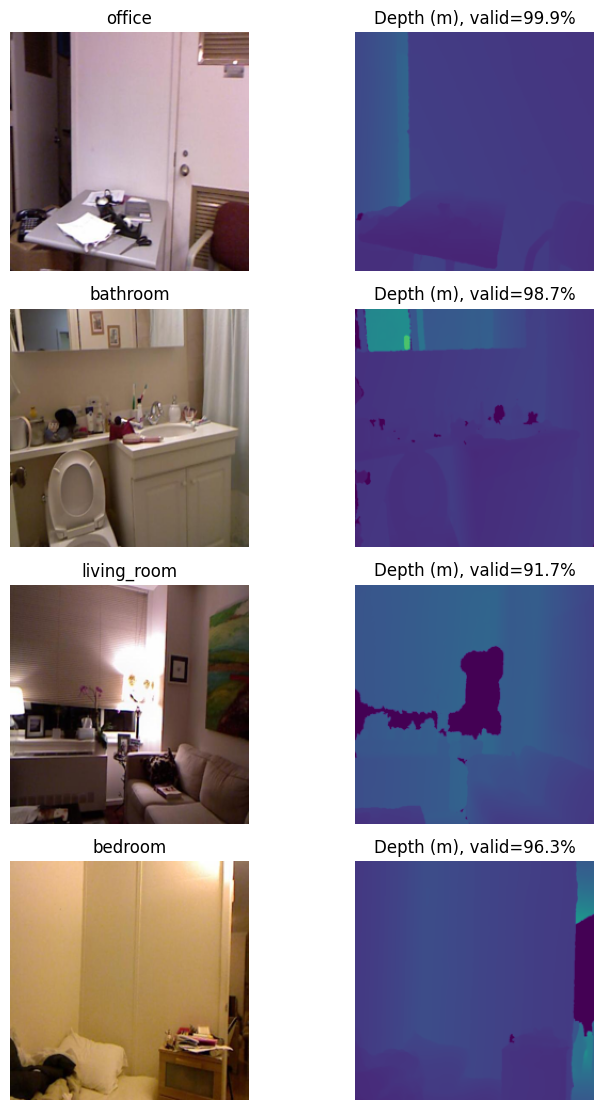

Raw dataset sizes: 4118 727 4659
Batch valid depth mean: 97.0%

Cell 05 완료 — 전처리·DataLoader·fit sanity check


In [ ]:
# Cell 05 — RGB–Depth 전처리·Dataset·DataLoader·sanity check
import matplotlib.pyplot as plt

CLIP_MEAN = torch.tensor((0.48145466, 0.4578275, 0.40821073))[:, None, None]
CLIP_STD = torch.tensor((0.26862954, 0.26130258, 0.27577711))[:, None, None]
IMNET_MEAN = torch.tensor((0.485, 0.456, 0.406))[:, None, None]
IMNET_STD = torch.tensor((0.229, 0.224, 0.225))[:, None, None]

def decode_depth(raw):
    raw = np.asarray(raw)
    if (raw.ndim != 2 or raw.dtype.kind not in "ui"
            or raw.min() < 0 or raw.max() > 65535):
        raise ValueError("Depth PNG는 0~65535 범위의 2차원 정수여야 한다.")
    # 16-bit 오른쪽 3-bit rotate → mm → m
    u = raw.astype(np.uint32)
    restored = ((u >> 3) | (u << 13)) & 0xFFFF
    return restored.astype(np.float32) / 1000.0

def read_pair(row):
    with Image.open(row["rgb"]) as image:
        rgb = np.array(image.convert("RGB"), copy=True)
    with Image.open(row["depth"]) as image:
        depth = decode_depth(np.array(image, copy=True))
    if rgb.shape[:2] != depth.shape:
        raise RuntimeError(f"RGB/Depth 해상도 불일치: {row['id']}")
    return rgb, depth

def resize_pair(rgb, depth):
    # 두 모달리티 모두 전체 화면을 동일한 좌표계로 resize한다.
    size = (CFG["img_size"], CFG["img_size"])
    rgb = np.array(
        Image.fromarray(rgb).resize(size, Image.Resampling.BICUBIC),
        copy=True,
    )
    depth = np.clip(depth, 0, CFG["max_depth_m"]).astype(np.float32)
    depth = np.array(
        Image.fromarray(depth).resize(size, Image.Resampling.BILINEAR),
        dtype=np.float32, copy=True,
    )
    rgb_u8 = torch.from_numpy(rgb).permute(2, 0, 1).contiguous()
    depth_m = torch.from_numpy(depth).contiguous()
    return rgb_u8, depth_m

def pair_tensors(rgb_u8, depth_m):
    rgb_01 = rgb_u8.float() / 255.0
    depth_01 = (depth_m / CFG["max_depth_m"]).unsqueeze(0).repeat(3, 1, 1)
    return {
        "rgb": (rgb_01 - IMNET_MEAN) / IMNET_STD,
        "depth": (depth_01 - IMNET_MEAN) / IMNET_STD,
        "teacher_rgb": (rgb_01 - CLIP_MEAN) / CLIP_STD,
    }

class RawPairs(Dataset):
    def __init__(self, split_name):
        self.positions = manifest.loc[
            manifest["split"] == split_name, "pos"
        ].to_numpy(dtype=np.int64)
        if len(self.positions) == 0:
            raise ValueError(f"빈 split: {split_name}")

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        pos = int(self.positions[index])
        row = manifest.iloc[pos]
        rgb, depth = read_pair(row)
        rgb_u8, depth_m = resize_pair(rgb, depth)
        item = pair_tensors(rgb_u8, depth_m)
        item.update({
            "pos": pos, "id": row["id"], "label": int(row["label"]),
            "depth_valid_fraction": float((depth > 0).mean()),
        })
        return item

def seed_worker(worker_id):
    seed = torch.initial_seed() % (2**32)
    np.random.seed(seed)
    random.seed(seed)

def make_loader(ds, shuffle=False, epoch_seed=0):
    generator = torch.Generator().manual_seed(epoch_seed)
    return DataLoader(
        ds, batch_size=CFG["batch_size"], shuffle=shuffle,
        num_workers=CFG["num_workers"], pin_memory=True,
        drop_last=False, generator=generator, worker_init_fn=seed_worker,
    )

FIT_RAW_DS = RawPairs("fit")
VAL_RAW_DS = RawPairs("val")
TEST_RAW_DS = RawPairs("test")

# 1-batch 확인은 fit 데이터만 사용한다.
batch = next(iter(make_loader(FIT_RAW_DS)))
expected = (len(batch["pos"]), 3, CFG["img_size"], CFG["img_size"])
for key in ("rgb", "depth", "teacher_rgb"):
    assert tuple(batch[key].shape) == expected
    assert torch.isfinite(batch[key]).all(), f"NaN/Inf 발견: {key}"
    print(key, tuple(batch[key].shape), batch[key].dtype)

preview = (
    manifest[manifest["split"] == "fit"]
    .groupby("label", sort=True).head(1).head(4)
)
fig, axes = plt.subplots(len(preview), 2, figsize=(8, 2.8 * len(preview)),
                         squeeze=False)
for axes_row, (_, row) in zip(axes, preview.iterrows()):
    rgb, depth = read_pair(row)
    rgb_u8, depth_m = resize_pair(rgb, depth)
    axes_row[0].imshow(rgb_u8.permute(1, 2, 0).numpy())
    axes_row[0].set_title(row["class_name"])
    axes_row[1].imshow(depth_m.numpy(), cmap="viridis",
                       vmin=0, vmax=CFG["max_depth_m"])
    axes_row[1].set_title(f"Depth (m), valid={(depth > 0).mean():.1%}")
    for ax in axes_row:
        ax.axis("off")
fig.tight_layout()
fig.savefig(OUT / "pair_sanity.png", dpi=140)
plt.show()
plt.close(fig)

atomic_json({
    "img_size": CFG["img_size"], "spatial_transform": "full_image_resize",
    "rgb_interpolation": "bicubic", "depth_interpolation": "bilinear",
    "depth_decode": "rotate_right_3_uint16_then_divide_1000",
    "max_depth_m": CFG["max_depth_m"], "depth_channels": 3,
    "invalid_depth": "zero_preserved_before_resize",
    "clip_mean": CLIP_MEAN.flatten().tolist(),
    "clip_std": CLIP_STD.flatten().tolist(),
    "imagenet_mean": IMNET_MEAN.flatten().tolist(),
    "imagenet_std": IMNET_STD.flatten().tolist(),
}, OUT / "preprocessing.json")

print("Raw dataset sizes:",
      len(FIT_RAW_DS), len(VAL_RAW_DS), len(TEST_RAW_DS))
print("Batch valid depth mean:",
      f"{batch['depth_valid_fraction'].mean().item():.1%}")
print("\nCell 05 완료 — 전처리·DataLoader·fit sanity check")



##Cell 06 — CLIP Teacher 및 클래스 텍스트 임베딩 구성

In [ ]:
# Cell 06 — CLIP Teacher 및 클래스 텍스트 임베딩 구성

MODEL_CACHE = LOCAL_CACHE / "pretrained_models"
MODEL_CACHE.mkdir(parents=True, exist_ok=True)

teacher, _, _ = open_clip.create_model_and_transforms(
    model_name=CFG["teacher"],
    pretrained=CFG["teacher_pretrained"],
    precision="fp32",
    device=device,
    cache_dir=str(MODEL_CACHE),
)
teacher.eval()
teacher.requires_grad_(False)
teacher.visual.output_tokens = False

tokenizer = open_clip.get_tokenizer(CFG["teacher"])

# Cell 05에서 teacher_rgb가 이미 resize·CLIP 정규화되므로
# OpenCLIP 기본 transform을 추가 적용하지 않는다.
assert tuple(teacher.visual.image_size) == (
    CFG["img_size"], CFG["img_size"]
)
assert not teacher.training
assert all(not p.requires_grad for p in teacher.parameters())

# 클래스 순서는 CLASS_NAMES 및 manifest의 label 순서와 동일하다.
# 예: computer_room → computer room
TEXT_PROMPTS = [
    template.format(name.replace("_", " "))
    for name in CLASS_NAMES
    for template in PROMPT_TEMPLATES
]
text_tokens = tokenizer(TEXT_PROMPTS).to(device)

with torch.no_grad(), torch.autocast("cuda", enabled=False):
    prompt_features = teacher.encode_text(text_tokens).float()
    prompt_features = F.normalize(prompt_features, dim=-1)
    prompt_features = prompt_features.reshape(
        len(CLASS_NAMES),
        len(PROMPT_TEMPLATES),
        CFG["feature_dim"],
    )

    # 각 문장 벡터 정규화 → 클래스별 평균 → 다시 정규화
    text_features = F.normalize(
        prompt_features.mean(dim=1), dim=-1
    )

assert tuple(text_features.shape) == (19, CFG["feature_dim"])
assert torch.isfinite(text_features).all()
assert torch.allclose(
    text_features.norm(dim=-1),
    torch.ones(len(CLASS_NAMES), device=device),
    atol=1e-5,
)


@torch.no_grad()
def encode_teacher_global(teacher_rgb):
    """Cell 05 형식의 입력 → 정규화된 CLIP 전역 특징 [B, 512]."""
    teacher.eval()
    images = teacher_rgb.to(
        device=device,
        dtype=torch.float32,
        non_blocking=True,
    )

    # 교사 target은 FP32로 생성한다.
    # 학생 학습의 AMP 설정은 그대로 유지한다.
    with torch.autocast("cuda", enabled=False):
        features = teacher.encode_image(images).float()
        features = F.normalize(features, dim=-1)

    return features


# fit 샘플 4개로 shape·finite·텍스트 비교 경로를 확인한다.
sanity_batch = next(
    iter(make_loader(FIT_RAW_DS, shuffle=False))
)
sanity_global = encode_teacher_global(
    sanity_batch["teacher_rgb"][:4]
)
sanity_cosine = sanity_global @ text_features.T
sanity_pred = sanity_cosine.argmax(dim=-1).cpu().tolist()

assert tuple(sanity_global.shape) == (4, CFG["feature_dim"])
assert tuple(sanity_cosine.shape) == (4, len(CLASS_NAMES))
assert torch.isfinite(sanity_global).all()
assert torch.isfinite(sanity_cosine).all()
assert torch.allclose(
    sanity_global.norm(dim=-1),
    torch.ones(4, device=device),
    atol=1e-5,
)

atomic_save({
    "config_id": CONFIG_ID,
    "class_names": CLASS_NAMES,
    "prompt_templates": PROMPT_TEMPLATES,
    "prompts": TEXT_PROMPTS,
    "text_features": text_features.detach().cpu(),
}, OUT / "text_embeddings.pt")

atomic_json({
    "teacher": CFG["teacher"],
    "pretrained": CFG["teacher_pretrained"],
    "open_clip_torch": ENV_INFO["open_clip_torch"],
    "teacher_frozen": True,
    "teacher_precision": "float32",
    "image_preprocessing": "Cell05_teacher_rgb",
    "text_ensemble": "normalize_each_then_mean_then_normalize",
    "text_feature_shape": list(text_features.shape),
    "visual_grid_size": list(teacher.visual.grid_size),
    "sanity_split": "fit",
    "sanity_samples": 4,
}, OUT / "teacher_protocol.json")

print("Teacher:", CFG["teacher"], "/", CFG["teacher_pretrained"])
print(
    "Teacher frozen:",
    all(not p.requires_grad for p in teacher.parameters()),
)
print("Text prompts:", len(TEXT_PROMPTS))
print(
    "text_features:",
    tuple(text_features.shape), text_features.dtype,
)
print(
    "Teacher global:",
    tuple(sanity_global.shape), sanity_global.dtype,
)
print("Teacher patch grid:", tuple(teacher.visual.grid_size))

print("\nSanity 예측 — fit 샘플 4개이며 성능 평가가 아니다.")
for i, pred in enumerate(sanity_pred):
    label = int(sanity_batch["label"][i])
    print(
        f"  {i}: 실제={CLASS_NAMES[label]} "
        f"| 예측={CLASS_NAMES[pred]}"
    )

print(
    "\nCell 06 완료 — frozen Teacher 및 클래스 텍스트 임베딩 준비"
)

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

Teacher: ViT-B-16-quickgelu / openai
Teacher frozen: True
Text prompts: 57
text_features: (19, 512) torch.float32
Teacher global: (4, 512) torch.float32
Teacher patch grid: (14, 14)

Sanity 예측 — fit 샘플 4개이며 성능 평가가 아니다.
  0: 실제=office | 예측=office
  1: 실제=office | 예측=office
  2: 실제=office | 예측=lab
  3: 실제=office | 예측=classroom

Cell 06 완료 — frozen Teacher 및 클래스 텍스트 임베딩 준비


## Cell 07 — ResNet-18 Student 및 전역·공간 특징 추출
Cell 06 완료 후 같은 런타임에서 실행한다.

In [ ]:
# Cell 07 — ResNet-18 Student 및 전역·공간 특징 추출
# Cell 06 완료 후 같은 런타임에서 실행한다.

class Student(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        assert CFG["feature_dim"] == 512

        weights = ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = resnet18(weights=weights)
        self.backbone.fc = nn.Identity()

        # RGB와 Depth가 같은 backbone과 projection을 공유한다.
        # ImageNet 특징을 CLIP 공간에 맞추기 위한 학습 가능한 층이다.
        self.proj = nn.Linear(
            512, CFG["feature_dim"], bias=False
        )
        with torch.no_grad():
            self.proj.weight.copy_(torch.eye(512))

        self.freeze_bn_stats = bool(CFG["freeze_bn_stats"])
        self.train()

    def train(self, mode=True):
        super().train(mode)

        if mode and self.freeze_bn_stats:
            # BN 통계는 고정하고 affine 파라미터는 학습한다.
            for module in self.backbone.modules():
                if isinstance(module, nn.BatchNorm2d):
                    module.eval()

        return self

    def forward_features(self, images):
        """RGB 또는 Depth [B,3,224,224] → [B,512,7,7]."""
        x = self.backbone.conv1(images)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        return self.backbone.layer4(x)

    def forward(self, images):
        feature_map = self.forward_features(images)

        # 7×7 공간 위치를 행 순서대로 49개 토큰으로 변환
        spatial_raw = feature_map.flatten(2).transpose(1, 2)
        global_raw = feature_map.mean(dim=(2, 3))

        # 전역·공간 특징에 동일한 projection 적용
        global_features = self.proj(global_raw)
        spatial_features = self.proj(spatial_raw)

        # AMP 학습에서도 정규화는 float32로 계산한다.
        return {
            "global": F.normalize(
                global_features.float(), dim=-1
            ),
            "spatial": F.normalize(
                spatial_features.float(), dim=-1
            ),
            "spatial_raw": spatial_raw,
        }


# 구조 확인용 모델이다.
# 실제 seed별 학습 모델은 Cell 09에서 새로 만든다.
set_seed(CFG["seeds"][0])
student_probe = Student(pretrained=True).to(device)
student_probe.train()

bn_modules = [
    m for m in student_probe.backbone.modules()
    if isinstance(m, nn.BatchNorm2d)
]

if CFG["freeze_bn_stats"]:
    assert all(not m.training for m in bn_modules)

assert all(
    p.requires_grad for p in student_probe.parameters()
)

probe_batch = next(
    iter(make_loader(FIT_RAW_DS, shuffle=False))
)
student_probe.eval()

with torch.no_grad(), torch.autocast("cuda", enabled=False):
    for modality in ("rgb", "depth"):
        images = probe_batch[modality][:4].to(
            device=device,
            dtype=torch.float32,
            non_blocking=True,
        )
        features = student_probe(images)

        assert tuple(features["global"].shape) == (4, 512)
        assert tuple(features["spatial"].shape) == (4, 49, 512)
        assert tuple(features["spatial_raw"].shape) == (4, 49, 512)

        for key, value in features.items():
            assert torch.isfinite(value).all(), (
                f"{modality}/{key}: NaN/Inf"
            )

        for key in ("global", "spatial"):
            norms = features[key].norm(dim=-1)
            assert torch.allclose(
                norms, torch.ones_like(norms), atol=1e-5
            )

        # 클래스 텍스트와의 비교 경로만 확인한다.
        logits = CFG["text_logit_scale"] * (
            features["global"] @ text_features.T
        )

        assert tuple(logits.shape) == (4, 19)
        assert torch.isfinite(logits).all()

        print(
            f"{modality}: "
            f"global={tuple(features['global'].shape)} | "
            f"spatial={tuple(features['spatial'].shape)} | "
            f"text logits={tuple(logits.shape)}"
        )

parameter_count = sum(
    p.numel() for p in student_probe.parameters()
)
trainable_count = sum(
    p.numel() for p in student_probe.parameters()
    if p.requires_grad
)

atomic_json({
    "student": "resnet18",
    "pretrained": "ResNet18_Weights.IMAGENET1K_V1",
    "shared_rgb_depth_backbone": True,
    "classification_head": "removed",
    "projection": "shared_linear_512_to_512_no_bias",
    "projection_initialization": "identity",
    "global_pooling": "mean_before_projection_and_L2_normalization",
    "spatial_grid": [7, 7],
    "spatial_tokens": 49,
    "spatial_order": "row_major",
    "feature_dim": CFG["feature_dim"],
    "freeze_bn_stats": CFG["freeze_bn_stats"],
    "bn_affine_trainable": True,
    "parameters": parameter_count,
    "trainable_parameters": trainable_count,
    "sanity_split": "fit",
    "sanity_samples_per_modality": 4,
}, OUT / "student_protocol.json")

print(f"Student parameters: {parameter_count:,}")
print(f"Trainable parameters: {trainable_count:,}")
print("BN running stats frozen:", CFG["freeze_bn_stats"])
print(
    "\nCell 07 완료 — Student 구조 및 RGB/Depth 특징 추출 확인"
)

# 구조 확인용 모델 정리
del student_probe, images, features, logits
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 234MB/s]


rgb: global=(4, 512) | spatial=(4, 49, 512) | text logits=(4, 19)
depth: global=(4, 512) | spatial=(4, 49, 512) | text logits=(4, 19)
Student parameters: 11,438,656
Trainable parameters: 11,438,656
BN running stats frozen: True

Cell 07 완료 — Student 구조 및 RGB/Depth 특징 추출 확인


##Cell08

Teacher 전역·공간 특징 캐시 및 Cached Dataset

In [ ]:
# Cell 08 — Teacher 전역·공간 특징 캐시 및 Cached Dataset
from functools import lru_cache
from torch.utils.data import Subset

TEACHER_GRID = tuple(teacher.visual.grid_size)
STUDENT_GRID = (7, 7)

assert TEACHER_GRID == (14, 14)
assert teacher.visual.pool_type == "tok"
assert teacher.visual.attn_pool is None
assert not teacher.visual.final_ln_after_pool
assert tuple(teacher.visual.proj.shape) == (768, 512)
assert ENV_INFO["open_clip_torch"] == "3.3.0"


@torch.no_grad()
def encode_teacher_features(teacher_rgb):
    """전역 [B,512], 공간 [B,49,512]; 정규화된 FP32."""
    teacher.eval()
    images = teacher_rgb.to(
        device=device,
        dtype=torch.float32,
        non_blocking=True,
    )

    previous = teacher.visual.output_tokens

    try:
        teacher.visual.output_tokens = True

        with torch.autocast("cuda", enabled=False):
            pooled, tokens = teacher.visual(images)

            # 이 모델의 patch 출력에는 ln_post가 적용되어 있다.
            # projection은 전역 특징에만 적용되므로 patch에도 직접 적용한다.
            assert tuple(tokens.shape[1:]) == (196, 768)

            projected = (
                tokens.float() @ teacher.visual.proj.float()
            )

            spatial_map = projected.transpose(1, 2).reshape(
                -1, 512, 14, 14
            )
            spatial_map = F.avg_pool2d(
                spatial_map, kernel_size=2, stride=2
            )
            spatial = spatial_map.flatten(2).transpose(1, 2)

            return {
                "global": F.normalize(pooled.float(), dim=-1),
                "spatial": F.normalize(spatial.float(), dim=-1),
            }

    finally:
        # Cell 06의 전역 특징 함수도 계속 사용할 수 있게 복원
        teacher.visual.output_tokens = previous


# 캐시 생성 전에 Cell 06의 전역 출력과 같은지 확인한다.
check_batch = next(iter(make_loader(FIT_RAW_DS)))

check_features = encode_teacher_features(
    check_batch["teacher_rgb"][:2]
)
check_global = encode_teacher_global(
    check_batch["teacher_rgb"][:2]
)

assert torch.allclose(
    check_features["global"],
    check_global,
    atol=1e-5,
    rtol=1e-4,
)
assert tuple(check_features["spatial"].shape) == (2, 49, 512)
assert torch.isfinite(check_features["spatial"]).all()
assert torch.allclose(
    check_features["spatial"].norm(dim=-1),
    torch.ones(2, 49, device=device),
    atol=1e-5,
)

print("Teacher global 일치 검사 및 7×7 공간 특징 검사 통과")
del check_features, check_global


# 설정·데이터·특징 추출 방식이 같은 캐시만 재사용한다.
CACHE_PROTOCOL = {
    "version": "v4_teacher_cache_01",
    "config_id": CONFIG_ID,
    "data_id": DATA_ID,
    "open_clip_torch": ENV_INFO["open_clip_torch"],
    "teacher": CFG["teacher"],
    "pretrained": CFG["teacher_pretrained"],
    "spatial_rule": "ln_post_patch_then_visual_proj_then_2x2_avg_then_L2",
    "rgb_storage": "uint8_3x224x224",
    "depth_storage": "float32_meters_224x224",
    "teacher_storage": "float32_normalized",
    "shard_size": CFG["shard_size"],
    "sample_count": len(manifest),
}

CACHE_ID = hashlib.sha256(
    json.dumps(CACHE_PROTOCOL, sort_keys=True).encode()
).hexdigest()[:12]

CACHE_DIR = LOCAL_CACHE / CACHE_ID
CACHE_DIR.mkdir(parents=True, exist_ok=True)
atomic_json(CACHE_PROTOCOL, CACHE_DIR / "protocol.json")

SHARD_SIZE = CFG["shard_size"]
N_SAMPLES = len(manifest)

assert np.array_equal(
    manifest["pos"].to_numpy(), np.arange(N_SAMPLES)
)


class CacheSource(Dataset):
    def __len__(self):
        return N_SAMPLES

    def __getitem__(self, pos):
        row = manifest.iloc[pos]
        rgb, depth = read_pair(row)
        rgb_u8, depth_m = resize_pair(rgb, depth)

        return {
            "pos": pos,
            "rgb_u8": rgb_u8,
            "depth_m": depth_m,
            "teacher_rgb": pair_tensors(
                rgb_u8, depth_m
            )["teacher_rgb"],
            "depth_valid_fraction": float((depth > 0).mean()),
        }


def shard_path(shard_id):
    return CACHE_DIR / f"shard_{shard_id:04d}.pt"


def read_cache_shard(shard_id):
    # 필요한 부분을 읽도록 memory mapping 사용
    data = torch.load(
        shard_path(shard_id),
        map_location="cpu",
        weights_only=True,
        mmap=True,
    )

    start = shard_id * SHARD_SIZE
    count = min(SHARD_SIZE, N_SAMPLES - start)

    assert data["cache_id"] == CACHE_ID
    assert torch.equal(
        data["pos"], torch.arange(start, start + count)
    )

    for key, shape, dtype in [
        ("rgb_u8", (count, 3, 224, 224), torch.uint8),
        ("depth_m", (count, 224, 224), torch.float32),
        ("teacher_global", (count, 512), torch.float32),
        ("teacher_spatial", (count, 49, 512), torch.float32),
        ("depth_valid_fraction", (count,), torch.float32),
    ]:
        assert tuple(data[key].shape) == shape, key
        assert data[key].dtype == dtype, key

    return data


source = CacheSource()
jobs = []

for shard_id in range(math.ceil(N_SAMPLES / SHARD_SIZE)):
    if shard_path(shard_id).exists():
        # 기존 파일의 설정·순서·shape를 확인한다.
        existing = read_cache_shard(shard_id)
        del existing
    else:
        jobs.append(shard_id)

bytes_per_sample = (
    3 * 224 * 224
    + 4 * 224 * 224
    + 4 * 512 * 50
)
remaining_samples = sum(
    min(SHARD_SIZE, N_SAMPLES - sid * SHARD_SIZE)
    for sid in jobs
)
needed = remaining_samples * bytes_per_sample + 256 * 1024**2

if jobs and shutil.disk_usage(CACHE_DIR).free < needed:
    raise RuntimeError(
        f"캐시 공간 부족: 약 {needed / 1024**3:.2f} GiB 필요"
    )

print("CACHE_DIR:", CACHE_DIR)
print(
    f"총 {N_SAMPLES:,}개 샘플 | "
    f"새로 만들 shard {len(jobs)}개"
)
started = time.monotonic()

for shard_id in tqdm(jobs, desc="Teacher cache"):
    start = shard_id * SHARD_SIZE
    stop = min(start + SHARD_SIZE, N_SAMPLES)

    parts = {
        key: [] for key in [
            "pos", "rgb_u8", "depth_m", "teacher_global",
            "teacher_spatial", "depth_valid_fraction",
        ]
    }

    for raw_batch in make_loader(
        Subset(source, range(start, stop))
    ):
        targets = encode_teacher_features(
            raw_batch["teacher_rgb"]
        )

        for value in targets.values():
            assert torch.isfinite(value).all(), (
                "Teacher target NaN/Inf"
            )

        for key in ("pos", "rgb_u8", "depth_m"):
            parts[key].append(raw_batch[key])

        parts["depth_valid_fraction"].append(
            raw_batch["depth_valid_fraction"].float()
        )
        parts["teacher_global"].append(
            targets["global"].cpu()
        )
        parts["teacher_spatial"].append(
            targets["spatial"].cpu()
        )

    payload = {
        key: torch.cat(value, dim=0)
        for key, value in parts.items()
    }
    payload["cache_id"] = CACHE_ID

    atomic_save(payload, shard_path(shard_id))

    verified = read_cache_shard(shard_id)
    del verified, payload, parts, targets

atomic_json({
    "cache_id": CACHE_ID,
    "protocol": CACHE_PROTOCOL,
    "shard_count": math.ceil(N_SAMPLES / SHARD_SIZE),
    "complete": True,
}, CACHE_DIR / "index.json")

atomic_json({
    "cache_id": CACHE_ID,
    "local_cache_dir": str(CACHE_DIR),
    "protocol": CACHE_PROTOCOL,
}, OUT / "teacher_cache_protocol.json")


class CachedPairs(Dataset):
    def __init__(self, split_name):
        self.positions = manifest.loc[
            manifest["split"] == split_name, "pos"
        ].to_numpy(dtype=np.int64)

        assert len(self.positions) > 0
        self.allowed_positions = set(self.positions.tolist())

    def __len__(self):
        return len(self.positions)

    @lru_cache(maxsize=8)
    def _shard(self, shard_id):
        return read_cache_shard(shard_id)

    def item_by_pos(self, pos):
        # 이후 F 통제군에서 fit RGB donor를 가져올 때도 사용
        pos = int(pos)

        if pos not in self.allowed_positions:
            raise IndexError(
                f"현재 split에 없는 position: {pos}"
            )

        data = self._shard(pos // SHARD_SIZE)
        offset = pos % SHARD_SIZE
        row = manifest.iloc[pos]

        item = pair_tensors(
            data["rgb_u8"][offset],
            data["depth_m"][offset],
        )
        item.update({
            "pos": pos,
            "id": row["id"],
            "label": int(row["label"]),
            "teacher_global": data["teacher_global"][offset],
            "teacher_spatial": data["teacher_spatial"][offset],
            "depth_valid_fraction": data[
                "depth_valid_fraction"
            ][offset],
        })
        return item

    def __getitem__(self, index):
        return self.item_by_pos(self.positions[index])


FIT_DS = CachedPairs("fit")
VAL_DS = CachedPairs("val")
TEST_DS = CachedPairs("test")

cached_batch = next(iter(make_loader(FIT_DS)))

for key in (
    "rgb", "depth", "teacher_rgb",
    "teacher_global", "teacher_spatial",
):
    assert torch.isfinite(cached_batch[key]).all(), key
    print(
        key,
        tuple(cached_batch[key].shape),
        cached_batch[key].dtype,
    )

# 캐시가 기존 입력을 그대로 복원하는지 확인
assert torch.allclose(
    cached_batch["rgb"], check_batch["rgb"], atol=0, rtol=0
)
assert torch.allclose(
    cached_batch["depth"], check_batch["depth"], atol=0, rtol=0
)

print("Raw / cached RGB·Depth 입력 일치 검사 통과")
print(
    "Cached dataset sizes:",
    len(FIT_DS), len(VAL_DS), len(TEST_DS),
)
print(
    f"이번 캐시 작업 시간: "
    f"{(time.monotonic() - started) / 60:.1f}분"
)
print(
    "\nCell 08 완료 — Teacher 캐시 및 Cached Dataset 준비"
)

Teacher global 일치 검사 및 7×7 공간 특징 검사 통과
CACHE_DIR: /content/edgevl_v4_cache/b56bce152f6c
총 9,504개 샘플 | 새로 만들 shard 75개


Teacher cache:   0%|          | 0/75 [00:00<?, ?it/s]

rgb (32, 3, 224, 224) torch.float32
depth (32, 3, 224, 224) torch.float32
teacher_rgb (32, 3, 224, 224) torch.float32
teacher_global (32, 512) torch.float32
teacher_spatial (32, 49, 512) torch.float32
Raw / cached RGB·Depth 입력 일치 검사 통과
Cached dataset sizes: 4118 727 4659
이번 캐시 작업 시간: 3.5분

Cell 08 완료 — Teacher 캐시 및 Cached Dataset 준비


## Cell 09. 공통 warm-up 학습 및 frozen anchor 준비

3개 seed에서 각각 5 epoch 동안 교사의 전역 특징과 텍스트 예측 분포를 이용해 학생을 학습한다. 검증 Depth 정확도가 가장 높은 체크포인트를 각 seed의 공통 초기값으로 저장한다. 이 모델을 복제하고 고정한 frozen anchor는 이후 RGB–Depth attention 계산에 사용한다. 라벨은 검증에만 사용하며, A~F의 공간 KD 비교는 이후 단계에서 진행한다.

In [ ]:
# Cell 09 — 공통 warm-up 학습 및 frozen anchor 준비
# 3 seeds × 5 epochs. 라벨은 validation accuracy 계산에만 사용한다.

WARMUP_PROTOCOL = {
    "version": "v4_warmup_01",
    "config_id": CONFIG_ID,
    "data_id": DATA_ID,
    "cache_id": CACHE_ID,
    "loss": "mean_RGB_Depth_global_cosine_KD_plus_text_KL",
    "local_KD": False,
    "epochs": CFG["warmup_epochs"],
    "selection": "val_depth_acc",
    "validation_precision": "float32",
    "text_sha256": hashlib.sha256(
        text_features.detach().cpu().contiguous().numpy().tobytes()
    ).hexdigest(),
}
WARMUP_ID = hashlib.sha256(
    json.dumps(WARMUP_PROTOCOL, sort_keys=True).encode()
).hexdigest()[:12]

atomic_json(
    WARMUP_PROTOCOL,
    OUT / f"warmup_protocol_{WARMUP_ID}.json",
)
assert CFG["selection"] == "depth_acc"
assert not text_features.requires_grad


def common_kd_loss(rgb_global, depth_global, teacher_global):
    """Warm-up 및 A~F에서 공통으로 사용하는 전역·텍스트 KD."""
    with torch.autocast("cuda", enabled=False):
        target = F.normalize(
            teacher_global.detach().float(), dim=-1
        )
        rgb = rgb_global.float()
        depth = depth_global.float()

        global_loss = 0.5 * (
            (1 - (rgb * target).sum(dim=-1)).mean()
            + (1 - (depth * target).sum(dim=-1)).mean()
        )

        scale = CFG["text_logit_scale"]
        teacher_probs = F.softmax(
            scale * (target @ text_features.T), dim=-1
        )
        text_loss = 0.5 * (
            F.kl_div(
                F.log_softmax(
                    scale * (rgb @ text_features.T), dim=-1
                ),
                teacher_probs,
                reduction="batchmean",
            )
            + F.kl_div(
                F.log_softmax(
                    scale * (depth @ text_features.T), dim=-1
                ),
                teacher_probs,
                reduction="batchmean",
            )
        )

        total = global_loss + CFG["text_coef"] * text_loss

    return total, {
        "global_loss": global_loss,
        "text_loss": text_loss,
    }


@torch.no_grad()
def evaluate_plain_student(model, dataset):
    """RGB·Depth 단독 accuracy. C의 paired 평가는 별도 구현."""
    model.eval()
    counts = {"rgb": 0, "depth": 0, "teacher": 0}
    total = 0

    for batch in make_loader(dataset, shuffle=False):
        labels = batch["label"].to(device)

        with torch.autocast("cuda", enabled=False):
            for modality in ("rgb", "depth"):
                features = model(
                    batch[modality].to(device)
                )["global"]
                prediction = (
                    features @ text_features.T
                ).argmax(dim=-1)

                counts[modality] += int(
                    (prediction == labels).sum().item()
                )

            teacher_prediction = (
                batch["teacher_global"].to(device)
                @ text_features.T
            ).argmax(dim=-1)

            counts["teacher"] += int(
                (teacher_prediction == labels).sum().item()
            )

        total += len(labels)

    assert total > 0
    return {
        "rgb_acc": counts["rgb"] / total,
        "depth_acc": counts["depth"] / total,
        "mean_acc": (
            counts["rgb"] + counts["depth"]
        ) / (2 * total),
        "teacher_rgb_acc": counts["teacher"] / total,
    }


def capture_rng():
    numpy_state = np.random.get_state()
    return {
        "python": random.getstate(),
        "torch": torch.get_rng_state(),
        "cuda": torch.cuda.get_rng_state_all(),
        "numpy": [
            numpy_state[0],
            numpy_state[1].tolist(),
            int(numpy_state[2]),
            int(numpy_state[3]),
            float(numpy_state[4]),
        ],
    }


def restore_rng(state):
    random.setstate(state["python"])
    torch.set_rng_state(state["torch"])
    torch.cuda.set_rng_state_all(state["cuda"])

    ns = state["numpy"]
    np.random.set_state((
        ns[0],
        np.asarray(ns[1], dtype=np.uint32),
        ns[2],
        ns[3],
        ns[4],
    ))


def checked_warmup_load(path, seed):
    checkpoint = torch.load(
        path, map_location="cpu", weights_only=True
    )
    assert checkpoint["warmup_id"] == WARMUP_ID, (
        "Warm-up protocol 불일치"
    )
    assert checkpoint["seed"] == seed
    return checkpoint


def save_history(history, path):
    tmp = path.with_name(path.name + ".tmp")
    pd.DataFrame(history).to_csv(tmp, index=False)
    os.replace(tmp, path)


def run_warmup(seed):
    paths = run_paths(seed, "WARMUP")
    set_seed(seed)

    previous = (
        checked_warmup_load(paths["last"], seed)
        if paths["last"].exists()
        else None
    )
    completed = (
        int(previous["epoch"]) if previous is not None else 0
    )

    if completed < CFG["warmup_epochs"]:
        model = Student(
            pretrained=previous is None
        ).to(device)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=CFG["lr"],
            weight_decay=CFG["weight_decay"],
        )
        scaler = torch.amp.GradScaler(
            "cuda", enabled=CFG["amp"]
        )

        history, best_score, best_epoch = [], -1.0, 0

        if previous is not None:
            model.load_state_dict(
                previous["model"], strict=True
            )
            optimizer.load_state_dict(previous["optimizer"])
            scaler.load_state_dict(previous["scaler"])
            history = previous["history"]
            best_score = previous["best_score"]
            best_epoch = previous["best_epoch"]
            restore_rng(previous["rng"])

            print(
                f"seed {seed}: epoch {completed + 1}부터 재개"
            )

        del previous

        for epoch in range(
            completed + 1, CFG["warmup_epochs"] + 1
        ):
            model.train()
            started = time.monotonic()
            sums = {
                "loss": 0.0,
                "global_loss": 0.0,
                "text_loss": 0.0,
            }
            seen, skipped = 0, 0

            loader = make_loader(
                FIT_DS,
                shuffle=True,
                epoch_seed=seed * 1000 + epoch,
            )

            for batch in tqdm(
                loader,
                desc=f"Warm-up seed={seed} epoch={epoch}",
                leave=False,
            ):
                optimizer.zero_grad(set_to_none=True)

                rgb = batch["rgb"].to(
                    device, non_blocking=True
                )
                depth = batch["depth"].to(
                    device, non_blocking=True
                )
                target = batch["teacher_global"].to(
                    device, non_blocking=True
                )

                with torch.autocast(
                    "cuda",
                    dtype=AMP_DTYPE,
                    enabled=CFG["amp"],
                ):
                    rgb_global = model(rgb)["global"]
                    depth_global = model(depth)["global"]

                loss, components = common_kd_loss(
                    rgb_global, depth_global, target
                )

                if not torch.isfinite(loss):
                    raise RuntimeError(
                        f"Non-finite warm-up loss: "
                        f"seed={seed}, epoch={epoch}"
                    )

                scaler.scale(loss).backward()
                old_scale = scaler.get_scale()
                scaler.step(optimizer)
                scaler.update()

                skipped += int(
                    scaler.get_scale() < old_scale
                )

                n = len(rgb)
                sums["loss"] += loss.detach().item() * n
                for key, value in components.items():
                    sums[key] += value.detach().item() * n
                seen += n

            if skipped == len(loader):
                raise RuntimeError(
                    "해당 epoch의 모든 AMP update가 "
                    "건너뛰어졌다. 출력 확인 필요."
                )

            val = evaluate_plain_student(model, VAL_DS)
            score = val["depth_acc"]
            assert math.isfinite(score)

            row = {
                "seed": seed,
                "epoch": epoch,
                **{
                    key: value / seen
                    for key, value in sums.items()
                },
                **{
                    f"val_{key}": value
                    for key, value in val.items()
                },
                "amp_skipped_steps": skipped,
                "seconds": time.monotonic() - started,
            }
            history.append(row)

            state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

            if score > best_score:
                best_score, best_epoch = score, epoch
                atomic_save({
                    "warmup_id": WARMUP_ID,
                    "seed": seed,
                    "epoch": epoch,
                    "model": state,
                    "val": val,
                }, paths["best"])

            # 완료한 epoch의 학습 상태와 RNG를 보관
            atomic_save({
                "warmup_id": WARMUP_ID,
                "seed": seed,
                "epoch": epoch,
                "model": state,
                "optimizer": optimizer.state_dict(),
                "scaler": scaler.state_dict(),
                "rng": capture_rng(),
                "history": history,
                "best_score": best_score,
                "best_epoch": best_epoch,
            }, paths["last"])

            save_history(history, paths["history"])

            print(
                f"seed={seed} | "
                f"epoch={epoch}/{CFG['warmup_epochs']} | "
                f"loss={row['loss']:.4f} | "
                f"val RGB={val['rgb_acc']:.2%} | "
                f"val Depth={val['depth_acc']:.2%} | "
                f"best epoch={best_epoch} | "
                f"AMP skipped={skipped}"
            )

        del model, optimizer, scaler, state
        torch.cuda.empty_cache()

    else:
        print(
            f"seed {seed}: warm-up 완료, "
            f"기존 checkpoint 재사용"
        )
        save_history(previous["history"], paths["history"])
        del previous

    best = checked_warmup_load(paths["best"], seed)
    return {
        "seed": seed,
        "best_epoch": best["epoch"],
        **{
            f"val_{key}": value
            for key, value in best["val"].items()
        },
        "best_path": str(paths["best"]),
    }


def load_warmup_student(seed):
    """각 mode의 공통 시작 모델. 파라미터는 학습 가능."""
    checkpoint = checked_warmup_load(
        run_paths(seed, "WARMUP")["best"], seed
    )

    # 복원 과정이 이후 adapter 초기화의 RNG를 바꾸지 않게 한다.
    with torch.random.fork_rng(devices=[]):
        student = Student(pretrained=False)

    student.load_state_dict(
        checkpoint["model"], strict=True
    )
    return student.to(device).train()


def load_frozen_anchor(seed):
    frozen = load_warmup_student(seed).eval()
    return frozen.requires_grad_(False)


warmup_rows = [
    run_warmup(seed) for seed in CFG["seeds"]
]

WARMUP_SUMMARY = pd.DataFrame(warmup_rows)
WARMUP_SUMMARY.to_csv(
    OUT / "warmup_summary.csv", index=False
)
WARMUP_BEST_PATHS = {
    row["seed"]: row["best_path"] for row in warmup_rows
}

display(WARMUP_SUMMARY.drop(columns=["best_path"]))

# 첫 seed anchor는 이후 셀의 구조 검사에 사용한다.
# 본 실험에서는 해당 seed의 anchor를 별도로 불러온다.
anchor_seed = CFG["seeds"][0]
anchor = load_frozen_anchor(anchor_seed)

assert not anchor.training
assert all(
    not p.requires_grad for p in anchor.parameters()
)

anchor_batch = next(iter(make_loader(FIT_DS)))
with torch.no_grad():
    anchor_output = anchor(
        anchor_batch["depth"][:2].to(device)
    )

assert tuple(anchor_output["spatial"].shape) == (2, 49, 512)
assert torch.isfinite(anchor_output["spatial"]).all()

del anchor_output

print(f"Frozen anchor ready: seed={anchor_seed}")
print(
    "\nCell 09 완료 — 3-seed warm-up 및 frozen anchor 준비"
)

Warm-up seed=42 epoch=1:   0%|          | 0/129 [00:00<?, ?it/s]

seed=42 | epoch=1/5 | loss=0.5043 | val RGB=25.03% | val Depth=23.66% | best epoch=1 | AMP skipped=0


Warm-up seed=42 epoch=2:   0%|          | 0/129 [00:00<?, ?it/s]

seed=42 | epoch=2/5 | loss=0.3187 | val RGB=25.58% | val Depth=27.79% | best epoch=2 | AMP skipped=0


Warm-up seed=42 epoch=3:   0%|          | 0/129 [00:00<?, ?it/s]

...

seed=2026 | epoch=4/5 | loss=0.2299 | val RGB=32.60% | val Depth=35.35% | best epoch=4 | AMP skipped=0


Warm-up seed=2026 epoch=5:   0%|          | 0/129 [00:00<?, ?it/s]

seed=2026 | epoch=5/5 | loss=0.2066 | val RGB=34.66% | val Depth=35.76% | best epoch=5 | AMP skipped=0


,seed,best_epoch,val_rgb_acc,val_depth_acc,val_mean_acc,val_teacher_rgb_acc
0,42,5,0.392022,0.361761,0.376891,0.500688
1,3407,5,0.433287,0.422283,0.427785,0.500688
2,2026,5,0.346630,0.357634,0.352132,0.500688


Frozen anchor ready: seed=42

Cell 09 완료 — 3-seed warm-up 및 frozen anchor 준비


## Cell 10. Cross-Modal Attention Adapter 구성

C_ADAPTER에서 사용할 학습 가능한 cross-attention adapter를 구성한다. Depth 특징을 Query, RGB 특징을 Key·Value로 사용해 RGB 정보를 참고한 보정값을 만들고, 기존 Depth 특징에 더한다. RGB+Depth paired 경로와 Depth 단독 경로를 각각 검사한다. D·E의 frozen-anchor 기반 attention은 이후 Cell 12에서 별도로 구성한다.

In [ ]:
# Cell 10 — C_ADAPTER용 Cross-Modal Attention Adapter
# Cell 09가 정상 완료된 뒤 실행한다.

class CrossModalAttentionAdapter(nn.Module):
    def __init__(self):
        super().__init__()
        dim = CFG["attn_dim"]
        assert dim == CFG["feature_dim"] == 512

        self.depth_norm = nn.LayerNorm(dim)
        self.rgb_norm = nn.LayerNorm(dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=CFG["attn_heads"],
            dropout=CFG["attn_dropout"],
            batch_first=True,
        )

        # 시작 시점에는 기존 warm-up 특징을 보존한다.
        # 출력 projection은 이후 KD 학습으로 갱신된다.
        nn.init.zeros_(self.attn.out_proj.weight)
        nn.init.zeros_(self.attn.out_proj.bias)

    def forward(
        self, depth_tokens, rgb_tokens, return_attention=False
    ):
        if depth_tokens.ndim != 3 or rgb_tokens.ndim != 3:
            raise ValueError(
                "Adapter 입력은 [B, N, 512]이어야 한다."
            )

        if (
            depth_tokens.shape[0] != rgb_tokens.shape[0]
            or depth_tokens.shape[-1] != CFG["attn_dim"]
            or rgb_tokens.shape[-1] != CFG["attn_dim"]
        ):
            raise ValueError(
                "RGB/Depth batch 또는 feature 차원이 맞지 않는다."
            )

        query = self.depth_norm(depth_tokens)
        rgb_kv = self.rgb_norm(rgb_tokens)

        correction, attention = self.attn(
            query=query,
            key=rgb_kv,
            value=rgb_kv,
            need_weights=return_attention,
            average_attn_weights=False,
        )

        enhanced = depth_tokens + correction
        return enhanced, attention


class AdapterStudent(nn.Module):
    """C_ADAPTER: 공통 Student + RGB-guided Depth adapter."""
    def __init__(self, student):
        super().__init__()
        self.student = student

        self.adapter = CrossModalAttentionAdapter().to(
            next(student.parameters()).device
        )

    def forward(self, images):
        # RGB 또는 Depth 단독 입력은 기존 Student 경로로 처리
        return self.student(images)

    def forward_pair(
        self, rgb, depth, return_attention=False
    ):
        rgb_features = self.student(rgb)
        depth_features = self.student(depth)

        enhanced_raw, attention = self.adapter(
            depth_features["spatial_raw"],
            rgb_features["spatial_raw"],
            return_attention=return_attention,
        )

        # 기존 Student와 같은 projection 사용
        paired_global = self.student.proj(
            enhanced_raw.mean(dim=1)
        )
        paired_spatial = self.student.proj(enhanced_raw)

        paired_depth = {
            "global": F.normalize(
                paired_global.float(), dim=-1
            ),
            "spatial": F.normalize(
                paired_spatial.float(), dim=-1
            ),
            "spatial_raw": enhanced_raw,
        }

        return {
            "rgb": rgb_features,
            "depth": depth_features,
            "paired_depth": paired_depth,
            "attention": attention,
        }


def make_adapter_student(seed):
    # 본 학습에서는 이 호출 전에 set_seed(seed)를 실행한다.
    return AdapterStudent(
        load_warmup_student(seed)
    ).to(device)


# 구조 검사 전용 모델로 테스트한다.
# 저장된 체크포인트와 anchor는 변경하지 않는다.
with torch.random.fork_rng(devices=[]):
    adapter_probe = make_adapter_student(CFG["seeds"][0])

adapter_probe.eval()
assert all(
    p.requires_grad for p in adapter_probe.adapter.parameters()
)

probe_batch = next(iter(make_loader(FIT_DS)))

with torch.no_grad(), torch.autocast("cuda", enabled=False):
    rgb_input = probe_batch["rgb"][:2].to(device)
    depth_input = probe_batch["depth"][:2].to(device)

    pair_output = adapter_probe.forward_pair(
        rgb_input,
        depth_input,
        return_attention=True,
    )
    single_depth = adapter_probe(depth_input)

for name in ("rgb", "depth", "paired_depth"):
    assert tuple(
        pair_output[name]["global"].shape
    ) == (2, 512)
    assert tuple(
        pair_output[name]["spatial"].shape
    ) == (2, 49, 512)

    for key, value in pair_output[name].items():
        assert torch.isfinite(value).all(), (
            f"{name}/{key}: NaN/Inf"
        )

    for key in ("global", "spatial"):
        norms = pair_output[name][key].norm(dim=-1)
        assert torch.allclose(
            norms, torch.ones_like(norms), atol=1e-5
        )

attention = pair_output["attention"]

assert tuple(attention.shape) == (
    2, CFG["attn_heads"], 49, 49
)
assert torch.isfinite(attention).all()
assert (attention >= 0).all()
assert torch.allclose(
    attention.sum(dim=-1),
    torch.ones_like(attention.sum(dim=-1)),
    atol=1e-5,
)

# 출력 projection을 0으로 초기화했으므로
# 최초 paired 특징은 기존 Depth 특징과 같다.
for key in ("global", "spatial"):
    assert torch.allclose(
        pair_output["depth"][key],
        single_depth[key],
        atol=1e-5,
        rtol=1e-4,
    )
    assert torch.allclose(
        pair_output["paired_depth"][key],
        single_depth[key],
        atol=1e-5,
        rtol=1e-4,
    )

adapter_parameters = sum(
    p.numel() for p in adapter_probe.adapter.parameters()
)
total_parameters = sum(
    p.numel() for p in adapter_probe.parameters()
)

atomic_json({
    "mode": "C_ADAPTER",
    "query": "current_student_depth_spatial_raw",
    "key_value": "current_student_rgb_spatial_raw",
    "input_normalization": "separate_Depth_RGB_LayerNorm",
    "attention_dim": CFG["attn_dim"],
    "heads": CFG["attn_heads"],
    "dropout": CFG["attn_dropout"],
    "residual": "Depth_plus_attention_output",
    "output_projection_initialization": "zero",
    "shared_student_projection": True,
    "depth_only_path": "plain_Student_without_adapter",
    "paired_path": "RGB_guided_adapter_then_shared_projection",
    "adapter_parameters": adapter_parameters,
    "total_parameters": total_parameters,
    "warmup_id": WARMUP_ID,
}, OUT / "adapter_protocol.json")

print(
    "Paired Depth global:",
    tuple(pair_output["paired_depth"]["global"].shape),
)
print(
    "Paired Depth spatial:",
    tuple(pair_output["paired_depth"]["spatial"].shape),
)
print(
    "Attention [B, heads, Depth 위치, RGB 위치]:",
    tuple(attention.shape),
)
print(f"Adapter parameters: {adapter_parameters:,}")
print(f"C_ADAPTER total parameters: {total_parameters:,}")
print("초기 paired/Depth 단독 특징 일치 검사: OK")
print(
    "\nCell 10 완료 — C_ADAPTER 구조 및 paired/Depth 단독 경로 확인"
)

del (
    adapter_probe, pair_output, single_depth,
    attention, rgb_input, depth_input,
)
torch.cuda.empty_cache()

Paired Depth global: (2, 512)
Paired Depth spatial: (2, 49, 512)
Attention [B, heads, Depth 위치, RGB 위치]: (2, 4, 49, 49)
Adapter parameters: 1,052,672
C_ADAPTER total parameters: 12,491,328
초기 paired/Depth 단독 특징 일치 검사: OK

Cell 10 완료 — C_ADAPTER 구조 및 paired/Depth 단독 경로 확인


## Cell 11. Text semantic relevance 및 KD 가중치 구성

교사의 RGB 전역 특징으로 클래스 예측 분포를 계산하고, 이를 이용해 대표 텍스트 벡터를 만든다. RGB의 각 공간 특징과 대표 텍스트 벡터의 유사도를 양수 가중치로 변환한 뒤, 이미지별 평균을 1로 정규화한다. B_TEXT에서는 이 가중치를 직접 사용하고, E_ATTN_SEMANTIC에서는 attention과 결합한다. 의미 신호는 교사 특징만으로 계산하며 정답 라벨은 사용하지 않는다.

Text semantic cache:   0%|          | 0/75 [00:00<?, ?it/s]

Text semantic cache 생성: text_semantic_9b56c500f9a0.pt
Semantic weights shape: (9504, 49)
fit_weight_mean: 1.000000
fit_weight_min: 0.401620
fit_weight_max: 1.755177
fit_mean_within_image_std: 0.158578
fit_effective_tokens_mean: 47.773621


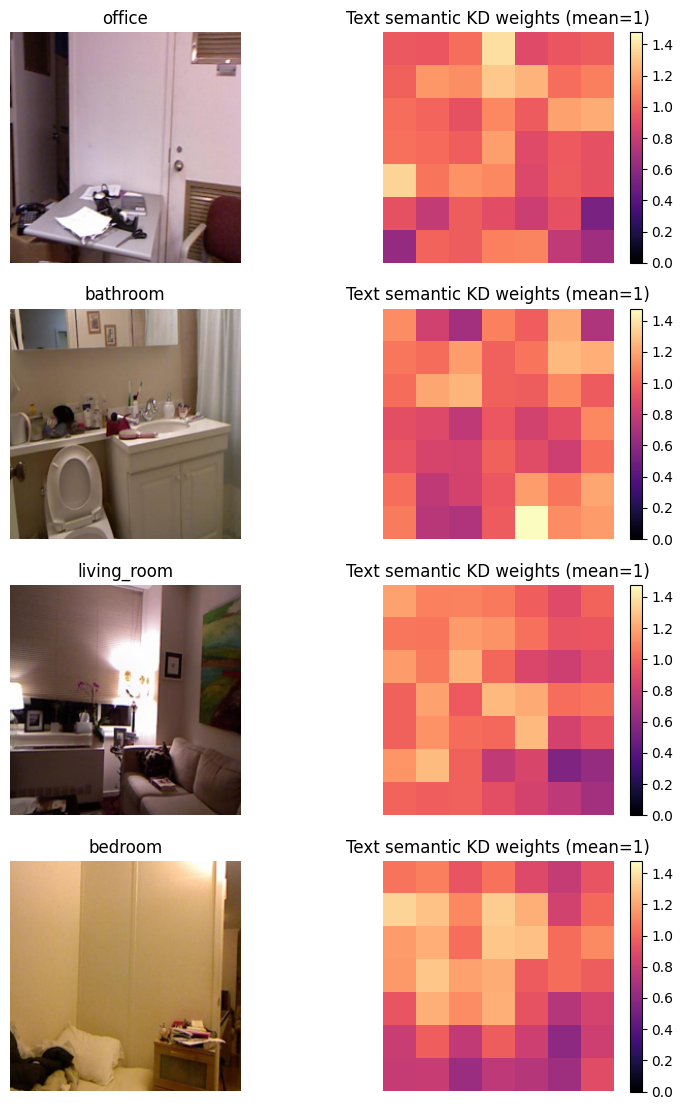


Cell 11 완료 — Text semantic relevance 및 평균 1 KD 가중치 준비


In [ ]:
# Cell 11 — RGB 공간 특징의 text semantic relevance 및 KD 가중치

assert CFG["class_tau"] > 0 and CFG["token_tau"] > 0
assert 0 < CFG["weight_floor"] <= 1


def mean_normalize(weights):
    """각 이미지의 위치별 가중치 평균을 1로 맞춘다."""
    weights = weights.float()

    if not torch.isfinite(weights).all() or (weights < 0).any():
        raise ValueError("가중치에 NaN/Inf 또는 음수가 있다.")

    weights = weights.clamp_min(1e-8)
    return weights / weights.mean(dim=-1, keepdim=True)


def positive_relevance(cosine):
    # V3의 계산식 유지: exp 변환 후 하한 적용
    scaled = cosine.float() / CFG["token_tau"]
    relative = torch.exp(
        scaled - scaled.amax(dim=-1, keepdim=True)
    )
    return relative.clamp_min(CFG["weight_floor"])


@torch.no_grad()
def text_semantic_signals(teacher_global, teacher_spatial):
    """교사 특징만 사용. 정답 라벨·학생 예측은 사용하지 않는다."""
    assert teacher_global.ndim == 2
    assert teacher_spatial.ndim == 3
    assert teacher_global.shape[0] == teacher_spatial.shape[0]
    assert (
        teacher_global.shape[-1]
        == teacher_spatial.shape[-1]
        == 512
    )
    assert teacher_global.device == teacher_spatial.device

    with torch.autocast("cuda", enabled=False):
        global_features = F.normalize(
            teacher_global.detach().float(), dim=-1
        )
        spatial_features = F.normalize(
            teacher_spatial.detach().float(), dim=-1
        )
        texts = text_features.detach().to(
            global_features.device, dtype=torch.float32
        )

        class_probs = F.softmax(
            (global_features @ texts.T) / CFG["class_tau"],
            dim=-1,
        )
        prototype = F.normalize(
            class_probs @ texts, dim=-1
        )

        cosine = (
            spatial_features * prototype[:, None, :]
        ).sum(dim=-1)

        relevance = positive_relevance(cosine)
        weights = mean_normalize(relevance)

    return {
        "class_probs": class_probs,
        "prototype": prototype,
        "cosine": cosine,
        "relevance": relevance,
        "weights": weights,
    }


# 동일한 relevance에는 균일 가중치가 부여되는지 확인
constant_weights = mean_normalize(
    positive_relevance(torch.full((2, 49), 0.2))
)
assert torch.allclose(
    constant_weights, torch.ones_like(constant_weights)
)

ordered_weights = mean_normalize(
    positive_relevance(torch.tensor([[0.2, 0.7]]))
)
assert ordered_weights[0, 1] > ordered_weights[0, 0]


SEMANTIC_PROTOCOL = {
    "version": "v4_text_semantic_01",
    "config_id": CONFIG_ID,
    "data_id": DATA_ID,
    "cache_id": CACHE_ID,
    "class_tau": CFG["class_tau"],
    "token_tau": CFG["token_tau"],
    "weight_floor": CFG["weight_floor"],
    "prototype": "L2_normalized_teacher_class_probability_weighted_text",
    "positive_relevance": "exp_score_minus_max_then_clamp_floor",
    "KD_weights": "per_image_mean_normalized_relevance",
    "spatial_tokens": 49,
    "text_sha256": hashlib.sha256(
        text_features.detach().cpu().contiguous().numpy().tobytes()
    ).hexdigest(),
}
SEMANTIC_ID = hashlib.sha256(
    json.dumps(SEMANTIC_PROTOCOL, sort_keys=True).encode()
).hexdigest()[:12]

SEMANTIC_PATH = OUT / f"text_semantic_{SEMANTIC_ID}.pt"


def validate_semantic_cache(result):
    assert result["semantic_id"] == SEMANTIC_ID
    assert result["protocol"] == SEMANTIC_PROTOCOL
    assert torch.equal(
        result["pos"], torch.arange(N_SAMPLES)
    )

    for key in ("cosine", "relevance", "weights"):
        assert tuple(result[key].shape) == (N_SAMPLES, 49)
        assert result[key].dtype == torch.float32
        assert torch.isfinite(result[key]).all(), key
        assert not result[key].requires_grad

    assert (
        result["relevance"] >= CFG["weight_floor"]
    ).all()
    assert (result["weights"] > 0).all()
    assert torch.allclose(
        result["weights"].mean(dim=-1),
        torch.ones(N_SAMPLES),
        atol=1e-5,
    )

    assert tuple(result["class_probs"].shape) == (
        N_SAMPLES, len(CLASS_NAMES)
    )
    assert torch.isfinite(result["class_probs"]).all()
    assert torch.allclose(
        result["class_probs"].sum(dim=-1),
        torch.ones(N_SAMPLES),
        atol=1e-5,
    )


if SEMANTIC_PATH.exists():
    SEMANTIC_SIGNALS = torch.load(
        SEMANTIC_PATH,
        map_location="cpu",
        weights_only=True,
    )
    validate_semantic_cache(SEMANTIC_SIGNALS)
    print("Text semantic cache 재사용:", SEMANTIC_PATH.name)

else:
    SEMANTIC_SIGNALS = {
        "semantic_id": SEMANTIC_ID,
        "protocol": SEMANTIC_PROTOCOL,
        "pos": torch.arange(N_SAMPLES),
        "cosine": torch.empty(
            N_SAMPLES, 49, dtype=torch.float32
        ),
        "relevance": torch.empty(
            N_SAMPLES, 49, dtype=torch.float32
        ),
        "weights": torch.empty(
            N_SAMPLES, 49, dtype=torch.float32
        ),
        "class_probs": torch.empty(
            N_SAMPLES, len(CLASS_NAMES), dtype=torch.float32
        ),
    }

    # 이미지를 다시 읽지 않고 캐시된 교사 특징만 읽는다.
    for shard_id in tqdm(
        range(math.ceil(N_SAMPLES / SHARD_SIZE)),
        desc="Text semantic cache",
    ):
        shard = read_cache_shard(shard_id)

        for start in range(
            0, len(shard["pos"]), CFG["batch_size"]
        ):
            stop = min(
                start + CFG["batch_size"], len(shard["pos"])
            )
            positions = shard["pos"][start:stop]

            signals = text_semantic_signals(
                shard["teacher_global"][start:stop].to(device),
                shard["teacher_spatial"][start:stop].to(device),
            )

            for key in (
                "cosine", "relevance", "weights", "class_probs"
            ):
                SEMANTIC_SIGNALS[key][positions] = (
                    signals[key].cpu()
                )

        del shard, signals

    validate_semantic_cache(SEMANTIC_SIGNALS)
    atomic_save(SEMANTIC_SIGNALS, SEMANTIC_PATH)
    print("Text semantic cache 생성:", SEMANTIC_PATH.name)


def semantic_by_pos(positions, target_device=None):
    """이미지 position으로 의미 신호를 가져온다."""
    indices = torch.as_tensor(
        positions, dtype=torch.long
    ).detach().cpu()

    if (
        indices.ndim != 1
        or ((indices < 0) | (indices >= N_SAMPLES)).any()
    ):
        raise ValueError(
            "positions는 유효한 sample index의 "
            "1차원 목록이어야 한다."
        )

    destination = (
        device if target_device is None else target_device
    )
    return {
        key: SEMANTIC_SIGNALS[key][indices].to(destination)
        for key in (
            "cosine", "relevance", "weights", "class_probs"
        )
    }


# 진단값은 fit 이미지만으로 계산한다.
fit_weights = SEMANTIC_SIGNALS["weights"][
    torch.from_numpy(FIT_DS.positions)
]
probabilities = (
    fit_weights / fit_weights.sum(dim=-1, keepdim=True)
)

semantic_stats = {
    "fit_weight_mean": float(fit_weights.mean()),
    "fit_weight_min": float(fit_weights.min()),
    "fit_weight_max": float(fit_weights.max()),
    "fit_mean_within_image_std": float(
        fit_weights.std(dim=-1, unbiased=False).mean()
    ),
    "fit_effective_tokens_mean": float(
        (1 / probabilities.square().sum(dim=-1)).mean()
    ),
}

atomic_json({
    "semantic_id": SEMANTIC_ID,
    "protocol": SEMANTIC_PROTOCOL,
    "fit_diagnostics": semantic_stats,
}, OUT / "semantic_protocol.json")

print(
    "Semantic weights shape:",
    tuple(SEMANTIC_SIGNALS["weights"].shape),
)
for key, value in semantic_stats.items():
    print(f"{key}: {value:.6f}")


# fit 이미지 4개에서 RGB와 7×7 weight map 확인
preview = (
    manifest[manifest["split"] == "fit"]
    .groupby("label", sort=True)
    .head(1)
    .head(4)
)
preview_positions = torch.tensor(
    preview["pos"].tolist(), dtype=torch.long
)
vmax = float(
    SEMANTIC_SIGNALS["weights"][preview_positions].max()
)

fig, axes = plt.subplots(
    len(preview), 2,
    figsize=(8, 2.8 * len(preview)),
    squeeze=False,
)

for axes_row, (_, row) in zip(axes, preview.iterrows()):
    item = FIT_DS.item_by_pos(int(row["pos"]))
    rgb_view = (
        item["rgb"] * IMNET_STD + IMNET_MEAN
    ).clamp(0, 1)

    axes_row[0].imshow(
        rgb_view.permute(1, 2, 0).numpy()
    )
    axes_row[0].set_title(row["class_name"])

    heatmap = axes_row[1].imshow(
        SEMANTIC_SIGNALS["weights"][int(row["pos"])]
        .reshape(7, 7).numpy(),
        cmap="magma",
        vmin=0,
        vmax=vmax,
        interpolation="nearest",
    )
    axes_row[1].set_title(
        "Text semantic KD weights (mean=1)"
    )
    fig.colorbar(
        heatmap, ax=axes_row[1], fraction=0.046, pad=0.04
    )

    for ax in axes_row:
        ax.axis("off")

fig.tight_layout()
fig.savefig(OUT / "semantic_sanity.png", dpi=140)
plt.show()
plt.close(fig)

print(
    "\nCell 11 완료 — Text semantic relevance 및 "
    "평균 1 KD 가중치 준비"
)

가중치 해석
- 1보다 크면 해당 위치의 지식을 더 강하게 전달
- 1보다 작으면 해당 위치의 지식을 약하게 전달
- fit_mean_within_image_std는 이미지 안에서 가중치가 얼마나 달라지는지 보여줌,  0에 가까울수록 균일

## Cell 12. Frozen-anchor attention 및 중요도 계산

각 seed의 warm-up best 모델을 고정하고, Depth 특징을 Query, RGB 특징을 Key로 사용해 위치 사이의 cosine attention을 계산한다. Attention의 entropy로 집중도를 구하고, 이를 평균 1의 KD 가중치로 변환해 D_ATTN_WEIGHT에서 사용한다. Fit·validation의 anchor 특징을 seed별로 캐시해 이후 E·F에서도 재사용한다.

In [ ]:
# Cell 12 — Frozen-anchor attention 및 D_ATTN_WEIGHT 중요도
from torch.utils.data import ConcatDataset

ATTENTION_TAU = 0.10

ACTIVE_ANCHOR_DS = ConcatDataset([FIT_DS, VAL_DS])
ACTIVE_POSITIONS = torch.from_numpy(
    np.concatenate([FIT_DS.positions, VAL_DS.positions])
).long()

ANCHOR_ROW_BY_POS = torch.full(
    (N_SAMPLES,), -1, dtype=torch.long
)
ANCHOR_ROW_BY_POS[ACTIVE_POSITIONS] = torch.arange(
    len(ACTIVE_POSITIONS)
)
ANCHOR_CACHE_INFO = {}


@torch.no_grad()
def frozen_attention(query_tokens, key_tokens):
    """Anchor Depth Q·RGB K → [B,49,49]."""
    assert query_tokens.ndim == key_tokens.ndim == 3
    assert query_tokens.shape[0] == key_tokens.shape[0]
    assert (
        query_tokens.shape[-1]
        == key_tokens.shape[-1]
        == 512
    )

    with torch.autocast("cuda", enabled=False):
        query = F.normalize(
            query_tokens.detach().float(), dim=-1
        )
        key = F.normalize(
            key_tokens.detach().float(), dim=-1
        )

        similarity = torch.bmm(
            query, key.transpose(1, 2)
        )
        return F.softmax(
            similarity / ATTENTION_TAU, dim=-1
        )


@torch.no_grad()
def attention_importance(attention):
    """Depth 위치별 attention 집중도 → 평균 1 KD weight."""
    assert attention.shape[-1] > 1

    with torch.autocast("cuda", enabled=False):
        probabilities = attention.detach().float()

        entropy = -(
            probabilities
            * probabilities.clamp_min(1e-12).log()
        ).sum(dim=-1)

        normalized_entropy = (
            entropy / math.log(attention.shape[-1])
        ).clamp(0, 1)

        concentration = 1 - normalized_entropy

        # 작은 집중도 차이를 유지하며 양수로 만들기 위해 floor를 더한다.
        weights = mean_normalize(
            concentration + CFG["weight_floor"]
        )

    return {
        "normalized_entropy": normalized_entropy,
        "concentration": concentration,
        "weights": weights,
    }


# 균일·집중 attention의 기본 동작 검사
uniform = torch.full((1, 49, 49), 1 / 49)
uniform_info = attention_importance(uniform)

assert torch.allclose(
    uniform_info["weights"],
    torch.ones(1, 49),
    atol=1e-5,
)
assert torch.allclose(
    uniform_info["normalized_entropy"],
    torch.ones(1, 49),
    atol=1e-5,
)

sharp_info = attention_importance(
    torch.eye(49).unsqueeze(0)
)
assert torch.allclose(
    sharp_info["normalized_entropy"],
    torch.zeros(1, 49),
    atol=1e-5,
)

mixed = uniform.clone()
mixed[:, 0, :] = 0
mixed[:, 0, 0] = 1
mixed_info = attention_importance(mixed)

assert (
    mixed_info["weights"][0, 0]
    > mixed_info["weights"][0, 1]
)
assert torch.allclose(
    mixed_info["weights"].mean(dim=-1),
    torch.ones(1),
    atol=1e-5,
)


def state_fingerprint(state):
    digest = hashlib.sha256()

    for name in sorted(state):
        value = state[name].detach().cpu().contiguous()
        digest.update(name.encode())
        digest.update(str(value.dtype).encode())
        digest.update(str(tuple(value.shape)).encode())
        digest.update(value.numpy().tobytes())

    return digest.hexdigest()


def read_anchor_shard(seed, shard_id):
    info = ANCHOR_CACHE_INFO[seed]

    data = torch.load(
        info["dir"] / f"shard_{shard_id:04d}.pt",
        map_location="cpu",
        weights_only=True,
        mmap=True,
    )

    start = shard_id * SHARD_SIZE
    expected = ACTIVE_POSITIONS[start:start + SHARD_SIZE]

    assert data["anchor_cache_id"] == info["id"]
    assert torch.equal(data["pos"], expected)

    for name in ("query", "key"):
        assert tuple(data[name].shape) == (
            len(expected), 49, 512
        )
        assert data[name].dtype == torch.float32

    for name in ("weights", "normalized_entropy"):
        assert tuple(data[name].shape) == (
            len(expected), 49
        )
        assert data[name].dtype == torch.float32

    return data


@torch.no_grad()
def prepare_anchor_cache(seed):
    checkpoint = checked_warmup_load(
        run_paths(seed, "WARMUP")["best"], seed
    )

    protocol = {
        "version": "v4_anchor_attention_01",
        "seed": seed,
        "warmup_id": WARMUP_ID,
        "best_epoch": checkpoint["epoch"],
        "checkpoint_sha256": state_fingerprint(
            checkpoint["model"]
        ),
        "data_id": DATA_ID,
        "cache_id": CACHE_ID,
        "split": "fit_and_val_only",
        "precision": "float32",
        "attention_tau": ATTENTION_TAU,
        "query": "anchor_depth_spatial",
        "key": "anchor_rgb_spatial",
        "spatial_tokens": 49,
        "importance": (
            "mean_normalize_one_minus_normalized_entropy_plus_floor"
        ),
        "importance_floor": CFG["weight_floor"],
        "shard_size": SHARD_SIZE,
    }

    cache_id = hashlib.sha256(
        json.dumps(protocol, sort_keys=True).encode()
    ).hexdigest()[:12]

    folder = LOCAL_CACHE / f"anchor_{seed}_{cache_id}"
    folder.mkdir(parents=True, exist_ok=True)

    ANCHOR_CACHE_INFO[seed] = {
        "id": cache_id,
        "dir": folder,
        "protocol": protocol,
    }
    atomic_json(protocol, folder / "protocol.json")

    count = math.ceil(
        len(ACTIVE_POSITIONS) / SHARD_SIZE
    )
    jobs = []

    for shard_id in range(count):
        if (folder / f"shard_{shard_id:04d}.pt").exists():
            existing = read_anchor_shard(seed, shard_id)
            del existing
        else:
            jobs.append(shard_id)

    remaining = sum(
        min(
            SHARD_SIZE,
            len(ACTIVE_POSITIONS) - sid * SHARD_SIZE,
        )
        for sid in jobs
    )
    needed = (
        remaining * (2 * 49 * 512 * 4 + 2 * 49 * 4)
        + 128 * 1024**2
    )

    if jobs and shutil.disk_usage(folder).free < needed:
        raise RuntimeError(
            f"Anchor cache 공간 부족: "
            f"약 {needed / 1024**3:.2f} GiB 필요"
        )

    print(
        f"seed={seed} | "
        f"anchor samples={len(ACTIVE_POSITIONS)} | "
        f"새 shard={len(jobs)}"
    )

    if jobs:
        with torch.random.fork_rng(devices=[]):
            frozen = Student(pretrained=False)

        frozen.load_state_dict(
            checkpoint["model"], strict=True
        )
        frozen = (
            frozen.to(device).eval().requires_grad_(False)
        )

        assert all(
            not p.requires_grad for p in frozen.parameters()
        )
        del checkpoint

        for shard_id in tqdm(
            jobs, desc=f"Anchor cache seed={seed}"
        ):
            start = shard_id * SHARD_SIZE
            stop = min(
                start + SHARD_SIZE, len(ACTIVE_POSITIONS)
            )

            parts = {
                name: [] for name in (
                    "pos", "query", "key",
                    "weights", "normalized_entropy",
                )
            }

            loader = make_loader(
                Subset(ACTIVE_ANCHOR_DS, range(start, stop))
            )

            for batch in loader:
                with torch.autocast("cuda", enabled=False):
                    query = frozen(
                        batch["depth"].to(device)
                    )["spatial"]
                    key = frozen(
                        batch["rgb"].to(device)
                    )["spatial"]

                attention = frozen_attention(query, key)
                importance = attention_importance(attention)

                values = {
                    "pos": batch["pos"],
                    "query": query.cpu(),
                    "key": key.cpu(),
                    "weights": importance["weights"].cpu(),
                    "normalized_entropy": importance[
                        "normalized_entropy"
                    ].cpu(),
                }

                for name, value in values.items():
                    assert torch.isfinite(value).all(), name
                    parts[name].append(value)

            payload = {
                name: torch.cat(value)
                for name, value in parts.items()
            }
            payload["anchor_cache_id"] = cache_id

            atomic_save(
                payload,
                folder / f"shard_{shard_id:04d}.pt",
            )

            verified = read_anchor_shard(seed, shard_id)
            del verified, payload, parts, values

        del frozen
        torch.cuda.empty_cache()

    else:
        del checkpoint

    fit_weights, fit_entropy = [], []

    for shard_id in range(
        math.ceil(len(FIT_DS) / SHARD_SIZE)
    ):
        payload = read_anchor_shard(seed, shard_id)
        n = min(
            SHARD_SIZE,
            len(FIT_DS) - shard_id * SHARD_SIZE,
        )
        fit_weights.append(payload["weights"][:n])
        fit_entropy.append(payload["normalized_entropy"][:n])

    weights = torch.cat(fit_weights)
    entropy = torch.cat(fit_entropy)
    within_std = weights.std(dim=-1, unbiased=False)

    diagnostics = {
        "seed": seed,
        "fit_entropy_mean": float(entropy.mean()),
        "fit_weight_mean": float(weights.mean()),
        "fit_weight_min": float(weights.min()),
        "fit_weight_max": float(weights.max()),
        "fit_mean_within_image_std": float(
            within_std.mean()
        ),
        "fit_near_uniform_fraction": float(
            (within_std < 1e-3).float().mean()
        ),
    }

    assert torch.allclose(
        weights.mean(dim=-1),
        torch.ones(len(FIT_DS)),
        atol=1e-5,
    )

    atomic_json({
        "protocol": protocol,
        "anchor_cache_id": cache_id,
        "local_cache_dir": str(folder),
        "fit_diagnostics": diagnostics,
    }, OUT / f"anchor_protocol_seed{seed}.json")

    return diagnostics


ANCHOR_DIAGNOSTICS = pd.DataFrame([
    prepare_anchor_cache(seed)
    for seed in CFG["seeds"]
])
ANCHOR_DIAGNOSTICS.to_csv(
    OUT / "anchor_diagnostics.csv", index=False
)
display(ANCHOR_DIAGNOSTICS)


@lru_cache(maxsize=8)
def cached_anchor_shard(seed, shard_id):
    return read_anchor_shard(seed, shard_id)


def anchor_tokens_by_pos(seed, positions, kind):
    """query는 Depth, key는 RGB. fit/val 위치만 허용."""
    if kind not in ("query", "key"):
        raise ValueError(kind)

    indices = torch.as_tensor(
        positions, dtype=torch.long
    ).detach().cpu()

    if (
        indices.ndim != 1
        or len(indices) == 0
        or ((indices < 0) | (indices >= N_SAMPLES)).any()
    ):
        raise ValueError(
            "positions는 유효한 sample index의 "
            "1차원 목록이어야 한다."
        )

    rows = ANCHOR_ROW_BY_POS[indices]
    if (rows < 0).any():
        raise ValueError(
            "Anchor 신호는 fit/val에만 준비한다. "
            "test 위치는 허용하지 않는다."
        )

    tensors = [
        cached_anchor_shard(
            seed, int(row) // SHARD_SIZE
        )[kind][int(row) % SHARD_SIZE]
        for row in rows.tolist()
    ]
    return torch.stack(tensors).to(device)


@torch.no_grad()
def anchor_attention_by_pos(
    seed, depth_positions, rgb_positions=None
):
    # F에서는 rgb_positions에 고정 donor 위치를 전달한다.
    if rgb_positions is None:
        rgb_positions = depth_positions

    return frozen_attention(
        anchor_tokens_by_pos(seed, depth_positions, "query"),
        anchor_tokens_by_pos(seed, rgb_positions, "key"),
    )


# fit 샘플 2개로 실제 attention shape·가중치 검사
sample_positions = torch.from_numpy(FIT_DS.positions[:2])
sample_attention = anchor_attention_by_pos(
    CFG["seeds"][0], sample_positions
)
sample_importance = attention_importance(sample_attention)

assert tuple(sample_attention.shape) == (2, 49, 49)
assert torch.allclose(
    sample_attention.sum(dim=-1),
    torch.ones(2, 49, device=device),
    atol=1e-5,
)
assert tuple(
    sample_importance["weights"].shape
) == (2, 49)
assert torch.allclose(
    sample_importance["weights"].mean(dim=-1),
    torch.ones(2, device=device),
    atol=1e-5,
)

print("Frozen attention:", tuple(sample_attention.shape))
print(
    "D_ATTN_WEIGHT:",
    tuple(sample_importance["weights"].shape),
)
print(
    "\nCell 12 완료 — 3-seed frozen-anchor attention 및 중요도 준비"
)

seed=42 | anchor samples=4845 | 새 shard=38


Anchor cache seed=42:   0%|          | 0/38 [00:00<?, ?it/s]

seed=3407 | anchor samples=4845 | 새 shard=38


Anchor cache seed=3407:   0%|          | 0/38 [00:00<?, ?it/s]

seed=2026 | anchor samples=4845 | 새 shard=38


Anchor cache seed=2026:   0%|          | 0/38 [00:00<?, ?it/s]

,seed,fit_entropy_mean,fit_weight_mean,fit_weight_min,fit_weight_max,fit_mean_within_image_std,fit_near_uniform_fraction
0,42,0.982112,1.0,0.565312,2.737660,0.120478,0.0
1,3407,0.979123,1.0,0.528609,2.202375,0.121955,0.0
2,2026,0.983044,1.0,0.562203,2.676070,0.107957,0.0


Frozen attention: (2, 49, 49)
D_ATTN_WEIGHT: (2, 49)

Cell 12 완료 — 3-seed frozen-anchor attention 및 중요도 준비


### Cell 13 — Attended CLIP target 및 텍스트 중요도 투영

Frozen-anchor attention을 이용해 RGB 교사 공간 특징과 텍스트 relevance를
Depth의 각 공간 위치에 대응시킨다.

- 교사 target: L2_normalize(A @ T_RGB)
- KD 가중치: mean_normalize(A @ s_RGB)
- s_RGB: Cell 11에서 계산한 양수 text relevance
- Identity·uniform attention 검사와 3-seed 샘플 진단 수행

E_ATTN_SEMANTIC은 교사 target 대응과 텍스트 가중치 투영을 함께 적용한다.
전체 target을 추가 저장하지 않고 기존 캐시에서 필요할 때 계산한다.

Identity / uniform attention 검사 통과


,seed,sample_count,B_text_within_image_std,E_weight_mean,E_weight_min,E_weight_max,E_within_image_std,E_near_uniform_fraction,target_same_location_cosine,attended_raw_norm_min
0,42,64,0.159645,1.0,0.917295,1.136581,0.014602,0.0,0.895379,0.849265
1,3407,64,0.159645,1.0,0.932127,1.131101,0.016528,0.0,0.896172,0.849392
2,2026,64,0.159645,1.0,0.923783,1.136754,0.013887,0.0,0.895224,0.848547


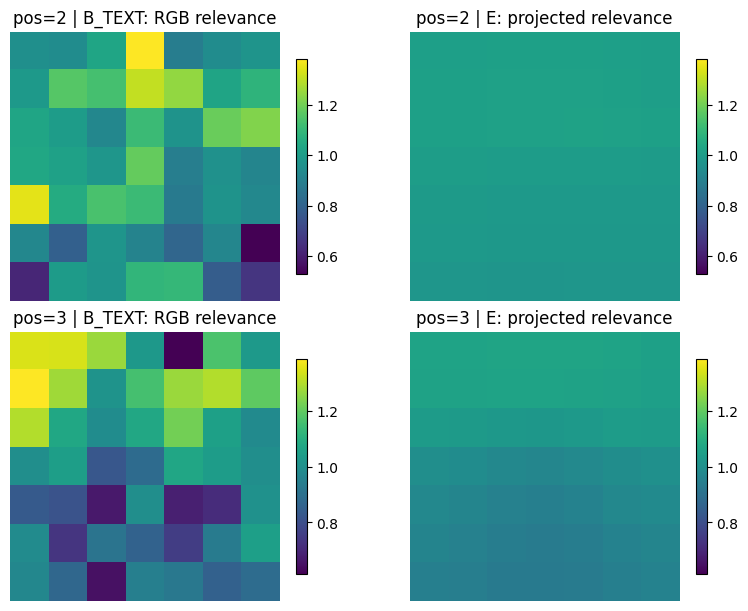

E target: (2, 49, 512)
E weight: (2, 49)
ATTENDED_TARGET_ID: 388a486c30db

Cell 13 완료 — attended CLIP target 및 semantic weight 계산 함수 준비


In [ ]:
# Cell 13 — Attended CLIP target 및 텍스트 중요도 투영
# E: target = normalize(A @ T_RGB), weight = mean_normalize(A @ s_RGB)
# s_RGB는 Cell 11의 양수 relevance이며, D의 entropy weight를 곱하지 않는다.

ATTENDED_TARGET_PROTOCOL = {
    "version": "v4_attended_target_01",
    "cache_id": CACHE_ID,
    "semantic_id": SEMANTIC_ID,
    "anchor_ids": {
        str(seed): ANCHOR_CACHE_INFO[seed]["id"]
        for seed in CFG["seeds"]
    },
    "target": "l2_normalize_attention_matmul_teacher_spatial",
    "weight": "mean_normalize_attention_matmul_positive_relevance",
    "rgb_signal": "cell11_relevance_before_mean_normalization",
    "entropy_weight_product": False,
    "donor_consistency": "same_rgb_position_for_key_teacher_spatial_relevance",
    "precision": "float32",
    "tokens": 49,
    "feature_dim": 512,
    "execution": "on_demand_from_frozen_caches",
}

ATTENDED_TARGET_ID = hashlib.sha256(
    json.dumps(ATTENDED_TARGET_PROTOCOL, sort_keys=True).encode()
).hexdigest()[:12]

atomic_json(
    {
        "attended_target_id": ATTENDED_TARGET_ID,
        "protocol": ATTENDED_TARGET_PROTOCOL,
    },
    OUT / "attended_target_protocol.json",
)


@torch.no_grad()
def attended_teacher_signals(attention, teacher_spatial, relevance):
    """RGB 교사 target/중요도를 Depth query 위치로 투영한다. 모두 detached FP32."""
    if (
        attention.ndim != 3
        or teacher_spatial.ndim != 3
        or relevance.ndim != 2
    ):
        raise ValueError(
            "입력 shape은 A=[B,Q,K], T=[B,K,512], s=[B,K]이어야 한다."
        )

    batch_size, query_count, key_count = attention.shape
    if (
        batch_size == 0
        or query_count != 49
        or key_count != 49
        or tuple(teacher_spatial.shape) != (batch_size, key_count, 512)
        or tuple(relevance.shape) != (batch_size, key_count)
    ):
        raise ValueError(
            "V4에서는 A=[B,49,49], T=[B,49,512], s=[B,49]를 사용한다."
        )

    if not (attention.device == teacher_spatial.device == relevance.device):
        raise ValueError("A, T, s는 같은 device에 있어야 한다.")

    with torch.autocast(device_type=attention.device.type, enabled=False):
        probabilities = attention.detach().float()
        rgb_target = teacher_spatial.detach().float()
        rgb_relevance = relevance.detach().float()

        if not (
            torch.isfinite(probabilities).all()
            and torch.isfinite(rgb_target).all()
            and torch.isfinite(rgb_relevance).all()
        ):
            raise ValueError("Attention 또는 교사 신호에 NaN/Inf가 있다.")

        if (probabilities < 0).any() or (rgb_relevance <= 0).any():
            raise ValueError("Attention은 비음수, relevance는 양수여야 한다.")

        if not torch.allclose(
            probabilities.sum(dim=-1),
            torch.ones_like(probabilities[..., 0]),
            atol=1e-5,
        ):
            raise ValueError("Attention의 RGB 방향 행 합이 1이어야 한다.")

        # RGB 교사 공간 특징을 attention으로 모아 Depth 위치에 대응시킨다.
        rgb_target = F.normalize(rgb_target, dim=-1, eps=1e-8)
        attended_raw = torch.bmm(probabilities, rgb_target)
        raw_norm = attended_raw.norm(dim=-1)

        if (raw_norm <= 1e-8).any():
            raise RuntimeError(
                "Attended target의 norm이 0에 가깝다. 교사 특징을 확인해야 한다."
            )

        target = F.normalize(attended_raw, dim=-1, eps=1e-8)

        # 텍스트 relevance에도 같은 attention을 적용한다.
        projected_relevance = torch.bmm(
            probabilities, rgb_relevance.unsqueeze(-1)
        ).squeeze(-1)

        weights = mean_normalize(projected_relevance)

    return {
        "target": target,
        "weights": weights,
        "projected_relevance": projected_relevance,
        "raw_norm": raw_norm,
    }


@lru_cache(maxsize=8)
def cached_teacher_target_shard(shard_id):
    return read_cache_shard(shard_id)


@torch.no_grad()
def teacher_spatial_by_pos(positions):
    """이미지 전처리 없이 Cell 08의 RGB 교사 공간 특징만 가져온다."""
    indices = torch.as_tensor(
        positions, dtype=torch.long
    ).detach().cpu()

    if (
        indices.ndim != 1
        or len(indices) == 0
        or ((indices < 0) | (indices >= N_SAMPLES)).any()
    ):
        raise ValueError(
            "positions는 유효한 sample index의 1차원 목록이어야 한다."
        )

    rows = [
        cached_teacher_target_shard(pos // SHARD_SIZE)["teacher_spatial"][
            pos % SHARD_SIZE
        ]
        for pos in indices.tolist()
    ]
    return torch.stack(rows).to(device)


@torch.no_grad()
def attended_signals_by_pos(seed, depth_positions, rgb_positions=None):
    """E는 동일 pair, F는 Cell 15에서 정할 RGB donor 위치를 전달한다."""
    rgb_positions = (
        depth_positions if rgb_positions is None else rgb_positions
    )

    # Anchor 함수가 fit/val 범위와 batch shape을 검사한다.
    # RGB key, 교사 특징, relevance는 모두 같은 RGB 위치에서 가져온다.
    attention = anchor_attention_by_pos(
        seed, depth_positions, rgb_positions
    )
    teacher_spatial = teacher_spatial_by_pos(rgb_positions)
    relevance = semantic_by_pos(rgb_positions)["relevance"]

    signals = attended_teacher_signals(
        attention, teacher_spatial, relevance
    )
    return {**signals, "attention": attention}


# ------------------------------------------------------------
# 1. 경계 조건 검사
# ------------------------------------------------------------
# Identity attention:
# 동일 위치 teacher target 및 B_TEXT 가중치와 일치해야 한다.
check_positions = torch.from_numpy(FIT_DS.positions[:2])
check_teacher = teacher_spatial_by_pos(check_positions)
check_semantic = semantic_by_pos(check_positions)

identity_attention = (
    torch.eye(49, device=device)
    .unsqueeze(0)
    .expand(2, -1, -1)
)
identity_signals = attended_teacher_signals(
    identity_attention,
    check_teacher,
    check_semantic["relevance"],
)

assert torch.allclose(
    identity_signals["target"],
    F.normalize(check_teacher.float(), dim=-1),
    atol=1e-5,
)
assert torch.allclose(
    identity_signals["weights"],
    check_semantic["weights"],
    atol=1e-5,
)

# Uniform attention:
# 모든 Depth 위치에 같은 target과 균일 가중치를 줘야 한다.
uniform_attention = torch.full(
    (2, 49, 49), 1 / 49, device=device
)
uniform_signals = attended_teacher_signals(
    uniform_attention,
    check_teacher,
    check_semantic["relevance"],
)

expected_uniform_target = F.normalize(
    check_teacher.float().mean(dim=1), dim=-1
)
assert torch.allclose(
    uniform_signals["target"],
    expected_uniform_target.unsqueeze(1).expand(-1, 49, -1),
    atol=1e-5,
)
assert torch.allclose(
    uniform_signals["weights"],
    torch.ones(2, 49, device=device),
    atol=1e-5,
)

print("Identity / uniform attention 검사 통과")


# ------------------------------------------------------------
# 2. 실제 frozen attention 기반 3-seed 샘플 진단
# ------------------------------------------------------------
# fit 전체에서 균등 간격으로 64개를 선택한다.
# 이 표는 샘플 진단이며 전체 fit 통계나 성능 평가가 아니다.
diagnostic_indices = np.linspace(
    0,
    len(FIT_DS) - 1,
    min(64, len(FIT_DS)),
    dtype=np.int64,
)
diagnostic_positions = torch.from_numpy(
    FIT_DS.positions[diagnostic_indices]
)
diagnostic_teacher = teacher_spatial_by_pos(diagnostic_positions)
diagnostic_semantic = semantic_by_pos(diagnostic_positions)

diagnostic_rows = []

for seed in CFG["seeds"]:
    diagnostic_attention = anchor_attention_by_pos(
        seed, diagnostic_positions
    )
    signals = attended_teacher_signals(
        diagnostic_attention,
        diagnostic_teacher,
        diagnostic_semantic["relevance"],
    )
    target, weights = signals["target"], signals["weights"]

    assert tuple(target.shape) == (
        len(diagnostic_positions), 49, 512
    )
    assert tuple(weights.shape) == (
        len(diagnostic_positions), 49
    )
    assert torch.isfinite(target).all()
    assert torch.isfinite(weights).all()
    assert torch.allclose(
        target.norm(dim=-1),
        torch.ones_like(weights),
        atol=1e-5,
    )
    assert torch.allclose(
        weights.mean(dim=-1),
        torch.ones_like(weights[:, 0]),
        atol=1e-5,
    )
    assert not target.requires_grad
    assert not weights.requires_grad

    within_std = weights.std(dim=-1, unbiased=False)

    diagnostic_rows.append({
        "seed": seed,
        "sample_count": len(diagnostic_positions),
        "B_text_within_image_std": float(
            diagnostic_semantic["weights"]
            .std(dim=-1, unbiased=False)
            .mean()
        ),
        "E_weight_mean": float(weights.mean()),
        "E_weight_min": float(weights.min()),
        "E_weight_max": float(weights.max()),
        "E_within_image_std": float(within_std.mean()),
        "E_near_uniform_fraction": float(
            (within_std < 1e-3).float().mean()
        ),
        "target_same_location_cosine": float(
            (target * diagnostic_teacher).sum(dim=-1).mean()
        ),
        "attended_raw_norm_min": float(signals["raw_norm"].min()),
    })

ATTENDED_TARGET_DIAGNOSTICS = pd.DataFrame(diagnostic_rows)
ATTENDED_TARGET_DIAGNOSTICS.to_csv(
    OUT / "attended_target_diagnostics.csv", index=False
)
display(ATTENDED_TARGET_DIAGNOSTICS)


# ------------------------------------------------------------
# 3. 투영 전후 가중치 시각화
# ------------------------------------------------------------
sample_attended_signals = attended_signals_by_pos(
    CFG["seeds"][0], check_positions
)

fig, axes = plt.subplots(
    2, 2, figsize=(8, 6), constrained_layout=True
)

for row in range(2):
    direct_weight = (
        check_semantic["weights"][row].cpu().reshape(7, 7)
    )
    projected_weight = (
        sample_attended_signals["weights"][row].cpu().reshape(7, 7)
    )
    vmin = min(
        float(direct_weight.min()), float(projected_weight.min())
    )
    vmax = max(
        float(direct_weight.max()), float(projected_weight.max())
    )

    for col, (title, weight) in enumerate([
        ("B_TEXT: RGB relevance", direct_weight),
        ("E: projected relevance", projected_weight),
    ]):
        heatmap = axes[row, col].imshow(
            weight.numpy(),
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        axes[row, col].set_title(
            f"pos={int(check_positions[row])} | {title}"
        )
        axes[row, col].axis("off")
        fig.colorbar(heatmap, ax=axes[row, col], shrink=0.8)

fig.savefig(OUT / "attended_target_sanity.png", dpi=140)
plt.show()

print("E target:", tuple(sample_attended_signals["target"].shape))
print("E weight:", tuple(sample_attended_signals["weights"].shape))
print("ATTENDED_TARGET_ID:", ATTENDED_TARGET_ID)
print(
    "\nCell 13 완료 — attended CLIP target 및 semantic weight 계산 함수 준비"
)

### Cell 14 — A~F 모드별 공간 KD 및 공통 손실 연결

모든 모드에 동일한 RGB 공간 KD와 RGB/Depth 단독 전역·텍스트 KD를 적용한다.
Depth 공간 KD의 특징 경로, 교사 target, 위치별 가중치는 모드에 따라 변경한다.

- A: 동일 위치 target + 균일 가중치
- B: 동일 위치 target + 텍스트 가중치
- C: adapter로 보강한 Depth 특징 + 동일 위치 target + 균일 가중치
- D: 동일 위치 target + attention 집중도 가중치
- E: attended target + attention으로 투영한 텍스트 가중치
- F: 잘못 대응된 RGB donor로 E와 같은 local supervision 구성

최종 손실:
L = L_global + text_coef × L_text
    + local_coef × (L_RGB_local + L_Depth_local) / 2

공간 KD의 수치·gradient 검사와 A~E 실제 배치 손실 검사를 수행한다.
F의 고정 donor는 Cell 15에서 준비한다.

In [ ]:
# Cell 14 — A~F 모드별 공간 KD와 공통 전역·텍스트 손실
# RGB 공간 KD와 RGB/Depth 단독 global/text KD는 모든 모드에서 동일하다.
# C의 adapter는 paired Depth 공간 KD로 학습한다.

MODE_LOSS_SPEC = {
    "A_UNIFORM": {
        "depth_path": "plain",
        "target": "same_location",
        "weight": "uniform",
    },
    "B_TEXT": {
        "depth_path": "plain",
        "target": "same_location",
        "weight": "text_relevance",
    },
    "C_ADAPTER": {
        "depth_path": "paired_adapter",
        "target": "same_location",
        "weight": "uniform",
    },
    "D_ATTN_WEIGHT": {
        "depth_path": "plain",
        "target": "same_location",
        "weight": "attention_concentration",
    },
    "E_ATTN_SEMANTIC": {
        "depth_path": "plain",
        "target": "attended_RGB",
        "weight": "projected_text_relevance",
    },
    "F_SHUFFLED_RGB": {
        "depth_path": "plain",
        "target": "attended_donor_RGB",
        "weight": "projected_donor_text_relevance",
    },
}
assert set(CFG["modes"]) == set(MODE_LOSS_SPEC)

LOSS_PROTOCOL = {
    "version": "v4_mode_loss_01",
    "config_id": CONFIG_ID,
    "data_id": DATA_ID,
    "cache_id": CACHE_ID,
    "warmup_id": WARMUP_ID,
    "semantic_id": SEMANTIC_ID,
    "attended_target_id": ATTENDED_TARGET_ID,
    "modes": MODE_LOSS_SPEC,
    "common_loss": "cell09_plain_RGB_Depth_global_cosine_and_text_KL",
    "RGB_local": "uniform_same_location_original_RGB_teacher",
    "Depth_local": "mode_specific_weighted_cosine",
    "local_reduction": "0.5_times_RGB_local_plus_Depth_local",
    "local_coef": float(CFG["local_coef"]),
    "text_coef": float(CFG["text_coef"]),
    "text_logit_scale": float(CFG["text_logit_scale"]),
    "C_adapter_supervision": "paired_Depth_local_only",
    "F_corruption_scope": "Depth_local_key_target_relevance_only",
    "labels_used_in_training_loss": False,
}
LOSS_ID = hashlib.sha256(
    json.dumps(LOSS_PROTOCOL, sort_keys=True).encode()
).hexdigest()[:12]
atomic_json(
    {"loss_id": LOSS_ID, "protocol": LOSS_PROTOCOL},
    OUT / "loss_protocol.json",
)


def weighted_local_kd(student_spatial, teacher_target, weights):
    """위치별 cosine KD. 학생에만 gradient를 전달한다."""
    if (
        student_spatial.ndim != 3
        or tuple(student_spatial.shape) != tuple(teacher_target.shape)
        or tuple(student_spatial.shape[1:]) != (49, 512)
        or tuple(weights.shape) != tuple(student_spatial.shape[:2])
    ):
        raise ValueError(
            "공간 특징은 [B,49,512], 가중치는 [B,49]이어야 한다."
        )

    if not (
        student_spatial.device == teacher_target.device == weights.device
    ):
        raise ValueError(
            "학생 특징, target, weights는 같은 device에 있어야 한다."
        )

    with torch.autocast(
        device_type=student_spatial.device.type, enabled=False
    ):
        prediction = F.normalize(
            student_spatial.float(), dim=-1, eps=1e-8
        )
        target = F.normalize(
            teacher_target.detach().float(), dim=-1, eps=1e-8
        )
        weight = weights.detach().float()

        if not torch.isfinite(weight).all() or (weight <= 0).any():
            raise ValueError("공간 KD 가중치는 유한한 양수여야 한다.")

        if not torch.allclose(
            weight.mean(dim=-1),
            torch.ones_like(weight[:, 0]),
            atol=1e-5,
        ):
            raise ValueError(
                "각 이미지의 공간 KD 가중치 평균이 1이어야 한다."
            )

        cosine = (prediction * target).sum(dim=-1).clamp(-1, 1)
        return (weight * (1 - cosine)).mean(dim=-1).mean()


@torch.no_grad()
def anchor_weights_by_pos(seed, positions):
    """Cell 12에서 저장한 동일 pair D_ATTN_WEIGHT 가중치를 재사용한다."""
    indices = torch.as_tensor(
        positions, dtype=torch.long
    ).detach().cpu()

    if (
        indices.ndim != 1
        or len(indices) == 0
        or ((indices < 0) | (indices >= N_SAMPLES)).any()
    ):
        raise ValueError(
            "positions는 유효한 sample index의 1차원 목록이어야 한다."
        )

    rows = ANCHOR_ROW_BY_POS[indices]
    if (rows < 0).any():
        raise ValueError("D의 anchor weight는 fit/val에만 준비한다.")

    values = [
        cached_anchor_shard(seed, row // SHARD_SIZE)["weights"][
            row % SHARD_SIZE
        ]
        for row in rows.tolist()
    ]
    return torch.stack(values).to(device)


@torch.no_grad()
def depth_local_supervision(
    seed, mode, positions, original_teacher, donor_positions=None
):
    """모드별 Depth 공간 target/weight. F donor 선택은 Cell 15에서 수행."""
    if mode not in MODE_LOSS_SPEC:
        raise ValueError(f"알 수 없는 mode: {mode}")
    if seed not in CFG["seeds"]:
        raise ValueError(f"설정에 없는 seed: {seed}")

    indices = torch.as_tensor(
        positions, dtype=torch.long
    ).detach().cpu()
    if (
        indices.ndim != 1
        or len(indices) == 0
        or ((indices < 0) | (indices >= N_SAMPLES)).any()
    ):
        raise ValueError("유효한 1차원 positions가 필요하다.")

    if tuple(original_teacher.shape) != (len(indices), 49, 512):
        raise ValueError(
            "positions와 teacher spatial batch가 일치하지 않는다."
        )

    if mode != "F_SHUFFLED_RGB" and donor_positions is not None:
        raise ValueError("RGB donor는 F_SHUFFLED_RGB에서만 사용한다.")

    target = original_teacher.detach().float()
    weights = torch.ones_like(target[..., 0])

    if mode == "B_TEXT":
        weights = semantic_by_pos(indices)["weights"]

    elif mode == "D_ATTN_WEIGHT":
        weights = anchor_weights_by_pos(seed, indices)

    elif mode == "E_ATTN_SEMANTIC":
        signals = attended_teacher_signals(
            anchor_attention_by_pos(seed, indices),
            target,
            semantic_by_pos(indices)["relevance"],
        )
        target, weights = signals["target"], signals["weights"]

    elif mode == "F_SHUFFLED_RGB":
        if donor_positions is None:
            raise ValueError(
                "F에는 Cell 15에서 준비할 고정 RGB donor 위치가 필요하다."
            )

        donors = torch.as_tensor(
            donor_positions, dtype=torch.long
        ).detach().cpu()

        if donors.shape != indices.shape:
            raise ValueError("F의 Depth/RGB donor batch 크기가 다르다.")

        fit_positions = FIT_DS.allowed_positions
        if (
            any(pos not in fit_positions for pos in indices.tolist())
            or any(pos not in fit_positions for pos in donors.tolist())
        ):
            raise ValueError(
                "F의 Depth와 donor RGB는 모두 fit split에서 가져와야 한다."
            )

        if torch.any(donors == indices):
            raise ValueError(
                "F에서는 자기 자신의 RGB를 donor로 사용할 수 없다."
            )

        signals = attended_signals_by_pos(
            seed, indices, rgb_positions=donors
        )
        target, weights = signals["target"], signals["weights"]

    return {"target": target, "weights": weights}


def compute_experiment_loss(
    model, batch, seed, mode, donor_positions=None
):
    """공통 forward + A~F loss. 정답 label을 읽지 않는다."""
    teacher_spatial = batch["teacher_spatial"].to(
        device, non_blocking=True
    )
    supervision = depth_local_supervision(
        seed,
        mode,
        batch["pos"],
        teacher_spatial,
        donor_positions,
    )

    if mode == "C_ADAPTER":
        if not isinstance(model, AdapterStudent):
            raise TypeError(
                "C_ADAPTER에는 Cell 10의 AdapterStudent가 필요하다."
            )
    elif isinstance(model, AdapterStudent):
        raise TypeError("A/B/D/E/F에는 공통 Student를 사용한다.")

    rgb_input = batch["rgb"].to(device, non_blocking=True)
    depth_input = batch["depth"].to(device, non_blocking=True)

    with torch.autocast(
        "cuda", dtype=AMP_DTYPE, enabled=CFG["amp"]
    ):
        if mode == "C_ADAPTER":
            outputs = model.forward_pair(rgb_input, depth_input)
            rgb_features = outputs["rgb"]
            depth_features = outputs["depth"]
            depth_local_features = outputs["paired_depth"]["spatial"]
        else:
            rgb_features = model(rgb_input)
            depth_features = model(depth_input)
            depth_local_features = depth_features["spatial"]

    # 모든 모드에서 원래 pair의 global teacher와 단독 Depth 경로 사용.
    # C도 공통 global/text KD는 plain Depth 특징에 적용한다.
    common_loss, components = common_kd_loss(
        rgb_features["global"],
        depth_features["global"],
        batch["teacher_global"].to(device, non_blocking=True),
    )

    # RGB 공간 KD는 모든 모드에서 동일한 target과 균일 가중치 사용.
    rgb_local = weighted_local_kd(
        rgb_features["spatial"],
        teacher_spatial,
        torch.ones_like(teacher_spatial[..., 0]),
    )

    depth_local = weighted_local_kd(
        depth_local_features,
        supervision["target"],
        supervision["weights"],
    )

    local_loss = 0.5 * (rgb_local + depth_local)
    total = common_loss + CFG["local_coef"] * local_loss

    if not torch.isfinite(total):
        raise RuntimeError(
            f"Non-finite experiment loss: seed={seed}, mode={mode}"
        )

    return total, {
        **components,
        "local_rgb_loss": rgb_local,
        "local_depth_loss": depth_local,
        "local_loss": local_loss,
        "depth_weight_mean": supervision["weights"].mean(),
        "depth_weight_std": (
            supervision["weights"]
            .std(dim=-1, unbiased=False)
            .mean()
        ),
    }


# ------------------------------------------------------------
# 1. 공간 KD의 수치 범위 및 gradient 경로 검사
# ------------------------------------------------------------
kd_target = torch.zeros(1, 49, 512)
kd_target[..., 0] = 1
kd_target.requires_grad_(True)

kd_prediction = torch.zeros_like(kd_target)
kd_prediction[..., 1] = 1
kd_prediction.requires_grad_(True)

kd_weights = torch.ones(1, 49, requires_grad=True)

# 같은 방향: 0, 반대 방향: 2, 직교 방향: 1
assert torch.allclose(
    weighted_local_kd(kd_target, kd_target, kd_weights),
    torch.tensor(0.0),
    atol=1e-6,
)
assert torch.allclose(
    weighted_local_kd(-kd_target, kd_target, kd_weights),
    torch.tensor(2.0),
    atol=1e-6,
)

kd_probe_loss = weighted_local_kd(
    kd_prediction, kd_target, kd_weights
)
assert torch.allclose(
    kd_probe_loss, torch.tensor(1.0), atol=1e-6
)

kd_probe_loss.backward()
assert kd_prediction.grad is not None
assert torch.isfinite(kd_prediction.grad).all()
assert kd_prediction.grad.abs().sum() > 0
assert kd_target.grad is None
assert kd_weights.grad is None

del kd_target, kd_prediction, kd_weights, kd_probe_loss
print(
    "Local KD 수치 / 학생 gradient / teacher·weight detach 검사 통과"
)


# ------------------------------------------------------------
# 2. 실제 fit batch에서 A~E loss 검사. 모델 update는 하지 않는다.
# ------------------------------------------------------------
first_batch = next(iter(make_loader(FIT_DS)))
loss_probe_batch = {
    key: first_batch[key][:2]
    for key in (
        "pos", "rgb", "depth", "teacher_global", "teacher_spatial"
    )
}
loss_probe_seed = CFG["seeds"][0]
loss_probe_rows = []

loss_probe_student = load_warmup_student(loss_probe_seed).eval()

with torch.no_grad():
    for mode in (
        "A_UNIFORM", "B_TEXT", "D_ATTN_WEIGHT", "E_ATTN_SEMANTIC"
    ):
        loss, logs = compute_experiment_loss(
            loss_probe_student, loss_probe_batch, loss_probe_seed, mode
        )
        loss_probe_rows.append({
            "mode": mode,
            "loss": float(loss),
            **{key: float(value) for key, value in logs.items()},
        })

    # F가 donor 없이 잘못 실행되는 것을 방지한다.
    try:
        compute_experiment_loss(
            loss_probe_student,
            loss_probe_batch,
            loss_probe_seed,
            "F_SHUFFLED_RGB",
        )
    except ValueError as error:
        assert "고정 RGB donor" in str(error)
        print(
            "F donor 누락 방어 검사 통과 — 실제 donor는 Cell 15에서 준비"
        )
    else:
        raise AssertionError("F가 donor 없이 실행되면 안 된다.")

del loss_probe_student

# C의 adapter 초기화가 이후 RNG 상태를 바꾸지 않도록 보호한다.
with torch.random.fork_rng(devices=[]):
    loss_probe_adapter = make_adapter_student(loss_probe_seed).eval()

with torch.no_grad():
    loss, logs = compute_experiment_loss(
        loss_probe_adapter,
        loss_probe_batch,
        loss_probe_seed,
        "C_ADAPTER",
    )
    loss_probe_rows.append({
        "mode": "C_ADAPTER",
        "loss": float(loss),
        **{key: float(value) for key, value in logs.items()},
    })

LOSS_SANITY = (
    pd.DataFrame(loss_probe_rows)
    .set_index("mode")
    .reindex([
        mode for mode in CFG["modes"]
        if mode != "F_SHUFFLED_RGB"
    ])
    .reset_index()
)
display(LOSS_SANITY)
LOSS_SANITY.to_csv(OUT / "loss_sanity.csv", index=False)

print("LOSS_ID:", LOSS_ID)
print(
    "\nCell 14 완료 — A~F 손실 연결, A~E forward loss 검사 완료"
)

del loss_probe_adapter, first_batch, loss_probe_batch, loss, logs
torch.cuda.empty_cache()

Local KD 수치 / 학생 gradient / teacher·weight detach 검사 통과
F donor 누락 방어 검사 통과 — 실제 donor는 Cell 15에서 준비


,mode,loss,global_loss,text_loss,local_rgb_loss,local_depth_loss,local_loss,depth_weight_mean,depth_weight_std
0,A_UNIFORM,0.354856,0.124384,0.155556,0.381535,0.367634,0.374584,1.0,0.000000
1,B_TEXT,0.353813,0.124384,0.155556,0.381535,0.357205,0.369370,1.0,0.180207
2,C_ADAPTER,0.354856,0.124384,0.155556,0.381535,0.367634,0.374584,1.0,0.000000
3,D_ATTN_WEIGHT,0.354097,0.124384,0.155556,0.381535,0.360042,0.370788,1.0,0.154735
4,E_ATTN_SEMANTIC,0.346968,0.124384,0.155556,0.381535,0.288750,0.335142,1.0,0.031401


LOSS_ID: f94a68a47fde

Cell 14 완료 — A~F 손실 연결, A~E forward loss 검사 완료


### Cell 15 — F_SHUFFLED_RGB용 seed별 고정 RGB donor

fit split 내부에서 자기 자신의 RGB를 제외한 일대일 donor 매핑을 생성한다.
seed별 매핑은 저장하며, 모든 epoch에서 동일하게 재사용한다.

F에서는 다음 신호를 같은 donor RGB에서 가져온다.
- Frozen-anchor RGB key
- CLIP RGB 교사 공간 특징
- RGB text relevance

학생의 RGB 입력과 공통 전역·텍스트 KD에는 원래 pair를 사용한다.
Donor 선택에 정답 라벨은 사용하지 않으며, 같은 클래스의 다른 샘플도 허용한다.

매핑 검사와 실제 E/F forward loss 비교를 수행한다.

In [ ]:
# Cell 15 — F_SHUFFLED_RGB용 seed별 고정 RGB donor
# fit 내부에서 자기 자신을 제외한 일대일 대응을 만들고 모든 epoch에서 재사용한다.

DONOR_SEED_OFFSET = 150_000
DONOR_FIT_POSITIONS = torch.from_numpy(FIT_DS.positions.copy()).long()
assert len(DONOR_FIT_POSITIONS) > 1
assert len(DONOR_FIT_POSITIONS.unique()) == len(DONOR_FIT_POSITIONS)

SHUFFLED_RGB_PROTOCOL = {
    "version": "v4_fixed_rgb_donor_01",
    "config_id": CONFIG_ID,
    "data_id": DATA_ID,
    "cache_id": CACHE_ID,
    "loss_id": LOSS_ID,
    "attended_target_id": ATTENDED_TARGET_ID,
    "seeds": list(CFG["seeds"]),
    "seed_offset": DONOR_SEED_OFFSET,
    "numpy_version": np.__version__,
    "rng": "local_numpy_Generator_PCG64",
    "algorithm": "random_permutation_reject_any_fixed_point",
    "split": "fit_only",
    "mapping": "one_to_one",
    "fixed_across_epochs": True,
    "labels_used_for_pairing": False,
    "same_class_donors_allowed": True,
    "fit_positions_sha256": hashlib.sha256(
        DONOR_FIT_POSITIONS.numpy()
        .astype("<i8", copy=False)
        .tobytes()
    ).hexdigest(),
    "shuffled_signals": [
        "anchor_RGB_key",
        "teacher_RGB_spatial",
        "RGB_text_relevance",
    ],
    "global_text_teacher": "original_paired_RGB",
    "student_RGB_input": "original_paired_RGB",
}
SHUFFLED_RGB_ID = hashlib.sha256(
    json.dumps(SHUFFLED_RGB_PROTOCOL, sort_keys=True).encode()
).hexdigest()[:12]

atomic_json(
    {
        "shuffled_rgb_id": SHUFFLED_RGB_ID,
        "protocol": SHUFFLED_RGB_PROTOCOL,
    },
    OUT / "shuffled_rgb_protocol.json",
)

DONOR_MAPS = {}
DONOR_MAP_INFO = {}


def make_fixed_donors(positions, seed):
    """라벨 없이 자기 대응이 없는 random permutation을 생성한다."""
    positions = np.asarray(positions, dtype=np.int64)

    if (
        positions.ndim != 1
        or len(positions) < 2
        or len(np.unique(positions)) != len(positions)
    ):
        raise ValueError(
            "donor 생성에는 중복 없는 2개 이상의 위치가 필요하다."
        )

    # 학습용 global RNG와 분리된 generator를 사용한다.
    rng = np.random.Generator(
        np.random.PCG64(int(seed) + DONOR_SEED_OFFSET)
    )

    for attempt in range(1, 10_001):
        donors = rng.permutation(positions)
        if np.all(donors != positions):
            return donors, attempt

    raise RuntimeError(
        "자기 대응이 없는 permutation을 생성하지 못했다."
    )


def donor_mapping_fingerprint(positions, donors):
    digest = hashlib.sha256()
    for values in (positions, donors):
        digest.update(
            values.detach().cpu().numpy()
            .astype("<i8", copy=False)
            .tobytes()
        )
    return digest.hexdigest()


def validate_donor_payload(payload, seed):
    assert payload["shuffled_rgb_id"] == SHUFFLED_RGB_ID
    assert payload["protocol"] == SHUFFLED_RGB_PROTOCOL
    assert payload["seed"] == seed

    positions = payload["pos"]
    donors = payload["donor_pos"]

    assert positions.dtype == donors.dtype == torch.long
    assert positions.ndim == donors.ndim == 1
    assert torch.equal(positions, DONOR_FIT_POSITIONS)
    assert donors.shape == positions.shape

    # 모든 fit RGB가 정확히 한 번씩 donor로 사용되어야 한다.
    assert torch.equal(
        donors.sort().values, positions.sort().values
    ), "donor는 fit의 일대일 순열이어야 한다."

    assert torch.all(
        donors != positions
    ), "자기 자신의 RGB가 포함되었다."

    assert payload["mapping_sha256"] == donor_mapping_fingerprint(
        positions, donors
    )


def prepare_fixed_rgb_donors(seed):
    path = OUT / f"shuffled_rgb_seed{seed}_{SHUFFLED_RGB_ID}.pt"

    if path.exists():
        payload = torch.load(
            path, map_location="cpu", weights_only=True
        )
        validate_donor_payload(payload, seed)
        print(f"seed={seed}: 기존 RGB donor 재사용")
    else:
        donors, attempts = make_fixed_donors(
            FIT_DS.positions, seed
        )
        payload = {
            "shuffled_rgb_id": SHUFFLED_RGB_ID,
            "protocol": SHUFFLED_RGB_PROTOCOL,
            "seed": seed,
            "pos": DONOR_FIT_POSITIONS.clone(),
            "donor_pos": torch.from_numpy(donors.copy()).long(),
            "permutation_attempts": attempts,
        }
        payload["mapping_sha256"] = donor_mapping_fingerprint(
            payload["pos"], payload["donor_pos"]
        )
        validate_donor_payload(payload, seed)
        atomic_save(payload, path)
        print(f"seed={seed}: 고정 RGB donor 생성")

    # Global sample position으로 조회한다.
    # val/test 위치는 -1로 유지한다.
    donor_of_pos = torch.full(
        (N_SAMPLES,), -1, dtype=torch.long
    )
    donor_of_pos[payload["pos"]] = payload["donor_pos"]

    DONOR_MAPS[seed] = donor_of_pos
    DONOR_MAP_INFO[seed] = {
        "shuffled_rgb_id": SHUFFLED_RGB_ID,
        "mapping_sha256": payload["mapping_sha256"],
        "path": str(path),
    }

    donors = payload["donor_pos"]
    fit_set = FIT_DS.allowed_positions

    return {
        "seed": seed,
        "fit_samples": len(payload["pos"]),
        "unique_donors": len(donors.unique()),
        "self_pair_count": int(
            (donors == payload["pos"]).sum()
        ),
        "outside_fit_count": sum(
            pos not in fit_set for pos in donors.tolist()
        ),
        "permutation_attempts": payload["permutation_attempts"],
        "mapping_id": payload["mapping_sha256"][:12],
    }


def donor_positions_by_pos(seed, positions):
    """학습 batch의 원래 위치로 고정 donor 위치를 조회한다. 반환값은 CPU tensor."""
    if seed not in DONOR_MAPS:
        raise ValueError(f"donor가 준비되지 않은 seed: {seed}")

    indices = torch.as_tensor(
        positions, dtype=torch.long
    ).detach().cpu()

    if (
        indices.ndim != 1
        or len(indices) == 0
        or ((indices < 0) | (indices >= N_SAMPLES)).any()
    ):
        raise ValueError(
            "positions는 유효한 sample index의 1차원 목록이어야 한다."
        )

    donors = DONOR_MAPS[seed][indices]
    if (donors < 0).any():
        raise ValueError(
            "RGB donor는 fit 위치에만 정의한다. val/test는 허용하지 않는다."
        )

    return donors.clone()


# ------------------------------------------------------------
# 1. 3-seed donor 생성 및 기본 검사
# ------------------------------------------------------------
donor_numpy_rng_before = np.random.get_state()
donor_torch_rng_before = torch.get_rng_state().clone()

DONOR_DIAGNOSTICS = pd.DataFrame([
    prepare_fixed_rgb_donors(seed)
    for seed in CFG["seeds"]
])

donor_numpy_rng_after = np.random.get_state()
assert donor_numpy_rng_before[0] == donor_numpy_rng_after[0]
assert np.array_equal(
    donor_numpy_rng_before[1], donor_numpy_rng_after[1]
)
assert donor_numpy_rng_before[2:] == donor_numpy_rng_after[2:]
assert torch.equal(
    donor_torch_rng_before, torch.get_rng_state()
)

display(DONOR_DIAGNOSTICS)
DONOR_DIAGNOSTICS.to_csv(
    OUT / "rgb_donor_diagnostics.csv", index=False
)
atomic_json(
    {str(seed): info for seed, info in DONOR_MAP_INFO.items()},
    OUT / "rgb_donor_maps.json",
)
print(
    "fit 범위 / 일대일 대응 / 자기 대응 없음 / global RNG 보존 검사 통과"
)

donor_probe_seed = CFG["seeds"][0]
donor_probe_positions = DONOR_FIT_POSITIONS[:5]

# 같은 위치를 조회하면 항상 같은 donor가 반환되어야 한다.
assert torch.equal(
    donor_positions_by_pos(
        donor_probe_seed, donor_probe_positions
    ),
    donor_positions_by_pos(
        donor_probe_seed, donor_probe_positions
    ),
)

display(pd.DataFrame({
    "depth_pos": donor_probe_positions.numpy(),
    "donor_rgb_pos": donor_positions_by_pos(
        donor_probe_seed, donor_probe_positions
    ).numpy(),
}))

# val/test 위치가 혼입되면 조회를 중단한다.
for donor_guard_name, donor_guard_ds in (
    ("val", VAL_DS), ("test", TEST_DS)
):
    try:
        donor_positions_by_pos(
            donor_probe_seed,
            torch.from_numpy(donor_guard_ds.positions[:1]),
        )
    except ValueError as error:
        assert "fit 위치" in str(error)
        print(f"{donor_guard_name} donor 조회 방어 검사 통과")
    else:
        raise AssertionError(
            f"{donor_guard_name} 위치에 donor가 정의되면 안 된다."
        )


# ------------------------------------------------------------
# 2. E/F의 실제 loss 비교. 모델 update는 하지 않는다.
# ------------------------------------------------------------
donor_probe_batch_full = next(iter(make_loader(FIT_DS)))
donor_probe_batch = {
    key: donor_probe_batch_full[key][:2]
    for key in (
        "pos", "rgb", "depth", "teacher_global", "teacher_spatial"
    )
}
donor_probe_model = load_warmup_student(donor_probe_seed).eval()
donor_loss_rows = []

with torch.no_grad():
    e_loss, e_logs = compute_experiment_loss(
        donor_probe_model,
        donor_probe_batch,
        donor_probe_seed,
        "E_ATTN_SEMANTIC",
    )

    f_donors = donor_positions_by_pos(
        donor_probe_seed, donor_probe_batch["pos"]
    )
    f_loss, f_logs = compute_experiment_loss(
        donor_probe_model,
        donor_probe_batch,
        donor_probe_seed,
        "F_SHUFFLED_RGB",
        donor_positions=f_donors,
    )

    # E/F에서도 공통 손실과 RGB 공간 KD는 같아야 한다.
    for name in ("global_loss", "text_loss", "local_rgb_loss"):
        assert torch.allclose(
            e_logs[name], f_logs[name], atol=1e-6
        ), name

    for mode, loss, logs in (
        ("E_ATTN_SEMANTIC", e_loss, e_logs),
        ("F_SHUFFLED_RGB", f_loss, f_logs),
    ):
        donor_loss_rows.append({
            "mode": mode,
            "loss": float(loss),
            **{key: float(value) for key, value in logs.items()},
        })

SHUFFLED_LOSS_SANITY = pd.DataFrame(donor_loss_rows)
display(SHUFFLED_LOSS_SANITY)
SHUFFLED_LOSS_SANITY.to_csv(
    OUT / "shuffled_rgb_loss_sanity.csv", index=False
)

print("SHUFFLED_RGB_ID:", SHUFFLED_RGB_ID)
print("E/F 공통 global·text·RGB local 손실 일치 검사 통과")
print(
    "\nCell 15 완료 — 3-seed 고정 RGB donor 및 F forward loss 연결 완료"
)

del donor_probe_model, donor_probe_batch_full, donor_probe_batch
del e_loss, e_logs, f_loss, f_logs, f_donors
torch.cuda.empty_cache()

seed=42: 고정 RGB donor 생성
seed=3407: 고정 RGB donor 생성
seed=2026: 고정 RGB donor 생성


,seed,fit_samples,unique_donors,self_pair_count,outside_fit_count,permutation_attempts,mapping_id
0,42,4118,4118,0,0,3,84b562f0d21a
1,3407,4118,4118,0,0,2,be46159b5510
2,2026,4118,4118,0,0,11,bf4603618255


fit 범위 / 일대일 대응 / 자기 대응 없음 / global RNG 보존 검사 통과


,depth_pos,donor_rgb_pos
0,2,4147
1,3,3390
2,5,1411
3,6,6380
4,7,1426


val donor 조회 방어 검사 통과
test donor 조회 방어 검사 통과


,mode,loss,global_loss,text_loss,local_rgb_loss,local_depth_loss,local_loss,depth_weight_mean,depth_weight_std
0,E_ATTN_SEMANTIC,0.346968,0.124384,0.155556,0.381535,0.28875,0.335142,1.0,0.031401
1,F_SHUFFLED_RGB,0.349322,0.124384,0.155556,0.381535,0.31229,0.346913,1.0,0.014088


SHUFFLED_RGB_ID: cdc6da2c6f8a
E/F 공통 global·text·RGB local 손실 일치 검사 통과

Cell 15 완료 — 3-seed 고정 RGB donor 및 F forward loss 연결 완료


### Cell 16 — A~F forward·backward·optimizer step 검사

첫 seed의 실제 학습 배치로 모드별 손실, gradient, 파라미터 업데이트를 검사한다.

- A/B/D/E/F: 유효한 optimizer step 1회
- C: 유효한 optimizer step 2회
  - 첫 역전파: adapter 출력 projection의 gradient 확인
  - 두 번째 역전파: Q/K/V projection의 gradient 연결 확인
- AMP overflow 발생 시 스케일을 낮춰 제한된 횟수 내에서 재시도
- 학생 파라미터 업데이트 및 BN running statistics 고정 확인
- 교사·anchor·텍스트·donor·샘플 캐시의 고정 상태 확인

검사 전용 모델을 사용하며 모델 가중치를 저장하지 않는다.
검사 후 RNG 상태를 복원한다.

In [ ]:
# Cell 16 — A~F forward / backward / optimizer-step sanity check
# Probe models only: reload warm-up for every mode; do not save model weights.

PROBE_SEED = CFG["seeds"][0]
MAX_PROBE_ATTEMPTS = 8

assert all(
    seed in DONOR_MAPS for seed in CFG["seeds"]
), "Cell 15를 먼저 완료해야 한다."
assert not text_features.requires_grad

for frozen_model in (teacher, anchor):
    assert not frozen_model.training
    assert all(
        not p.requires_grad and p.grad is None
        for p in frozen_model.parameters()
    )


def make_experiment_student(seed, mode):
    """모드별 공통 warm-up 시작 모델. 호출부에서 set_seed(seed)를 수행한다."""
    if mode not in CFG["modes"]:
        raise ValueError(f"알 수 없는 mode: {mode}")

    return (
        make_adapter_student(seed)
        if mode == "C_ADAPTER"
        else load_warmup_student(seed)
    )


def parameter_gradient_norm(parameters):
    gradients = [
        p.grad.detach().float()
        for p in parameters
        if p.grad is not None
    ]
    if not gradients:
        raise RuntimeError(
            "Gradient가 연결되지 않은 파라미터 그룹이다."
        )
    return float(
        torch.stack([g.norm() for g in gradients]).norm()
    )


def bn_running_snapshot(model):
    return {
        name: (
            module.running_mean.detach().cpu().clone(),
            module.running_var.detach().cpu().clone(),
            module.num_batches_tracked.detach().cpu().clone(),
        )
        for name, module in model.named_modules()
        if isinstance(module, nn.BatchNorm2d)
    }


def check_bn_running_unchanged(model, snapshot):
    for name, module in model.named_modules():
        if isinstance(module, nn.BatchNorm2d):
            assert not module.training, (
                f"{name}: BN running stats가 학습 모드이다."
            )
            current = (
                module.running_mean,
                module.running_var,
                module.num_batches_tracked,
            )
            assert all(
                torch.equal(value.detach().cpu(), previous)
                for value, previous in zip(current, snapshot[name])
            ), name


def run_training_probe(seed, mode, batch):
    set_seed(seed)
    model = make_experiment_student(seed, mode).train()
    student = model.student if mode == "C_ADAPTER" else model

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG["lr"],
        weight_decay=CFG["weight_decay"],
    )
    scaler = torch.amp.GradScaler(
        "cuda", enabled=CFG["amp"]
    )

    try:
        trainable = [
            (name, p)
            for name, p in model.named_parameters()
            if p.requires_grad
        ]
        frozen_ids = {
            id(p)
            for net in (teacher, anchor)
            for p in net.parameters()
        }
        optimizer_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }
        assert not (optimizer_ids & frozen_ids)

        bn_before = (
            bn_running_snapshot(student)
            if CFG["freeze_bn_stats"]
            else None
        )
        donors = (
            donor_positions_by_pos(seed, batch["pos"])
            if mode == "F_SHUFFLED_RGB"
            else None
        )

        # Check that local supervision is frozen FP32.
        supervision = depth_local_supervision(
            seed,
            mode,
            batch["pos"],
            batch["teacher_spatial"].to(device),
            donors,
        )
        for value in supervision.values():
            assert value.dtype == torch.float32
            assert not value.requires_grad
            assert torch.isfinite(value).all()
        del supervision

        required_steps = 2 if mode == "C_ADAPTER" else 1
        step_rows, skipped = [], 0

        torch.cuda.synchronize(device)
        torch.cuda.reset_peak_memory_stats(device)
        started = time.monotonic()

        for step in range(1, required_steps + 1):
            for attempt in range(1, MAX_PROBE_ATTEMPTS + 1):
                optimizer.zero_grad(set_to_none=True)

                loss, logs = compute_experiment_loss(
                    model,
                    batch,
                    seed,
                    mode,
                    donor_positions=donors,
                )
                assert loss.requires_grad
                assert torch.isfinite(loss)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)

                missing = [
                    name for name, p in trainable
                    if p.grad is None
                ]
                if missing:
                    raise RuntimeError(
                        f"{mode}: gradient 누락: {missing}"
                    )

                finite = bool(torch.stack([
                    torch.isfinite(p.grad).all()
                    for _, p in trainable
                ]).all())
                old_scale = scaler.get_scale()

                if not finite:
                    if not CFG["amp"]:
                        raise RuntimeError(
                            f"{mode}: FP32 gradient에 NaN/Inf가 있다."
                        )

                    # GradScaler skips the update, then reduces the scale.
                    scaler.step(optimizer)
                    scaler.update()
                    assert scaler.get_scale() < old_scale

                    skipped += 1
                    print(
                        f"{mode}: AMP overflow → "
                        f"scale={scaler.get_scale():.0f}, "
                        f"재시도 {attempt}"
                    )
                    del loss, logs
                    continue

                student_grad_norm = parameter_gradient_norm(
                    student.parameters()
                )
                assert math.isfinite(student_grad_norm)
                assert student_grad_norm > 0

                adapter_out_grad = adapter_qkv_grad = None
                watch = {
                    "projection": student.proj.weight,
                    "conv1": student.backbone.conv1.weight,
                }

                if mode == "C_ADAPTER":
                    adapter_out_grad = parameter_gradient_norm(
                        model.adapter.attn.out_proj.parameters()
                    )
                    adapter_qkv_grad = parameter_gradient_norm([
                        model.adapter.attn.in_proj_weight,
                        model.adapter.attn.in_proj_bias,
                    ])

                    assert math.isfinite(adapter_out_grad)
                    assert adapter_out_grad > 0
                    assert math.isfinite(adapter_qkv_grad)

                    if step == 1:
                        assert adapter_qkv_grad == 0, (
                            "0 초기화 시 첫 Q/K/V gradient는 "
                            "0이어야 한다."
                        )
                    else:
                        assert adapter_qkv_grad > 0, (
                            "두 번째 step에서도 Q/K/V gradient가 0이다."
                        )

                    watch["adapter_out"] = (
                        model.adapter.attn.out_proj.weight
                    )

                before = {
                    name: p.detach().clone()
                    for name, p in watch.items()
                }

                scaler.step(optimizer)
                scaler.update()
                assert scaler.get_scale() >= old_scale, (
                    "유한 gradient인데 AMP update가 건너뛰어졌다."
                )

                changes = {
                    name: float(
                        (p.detach() - before[name]).abs().max()
                    )
                    for name, p in watch.items()
                }
                assert all(
                    math.isfinite(delta) and delta > 0
                    for delta in changes.values()
                ), changes

                assert bool(torch.stack([
                    torch.isfinite(p).all()
                    for _, p in trainable
                ]).all())

                step_rows.append({
                    "loss": float(loss.detach()),
                    "student_grad_norm": student_grad_norm,
                    "adapter_out_grad": adapter_out_grad,
                    "adapter_qkv_grad": adapter_qkv_grad,
                    "projection_update_max": changes["projection"],
                    "conv1_update_max": changes["conv1"],
                    "adapter_out_update_max": changes.get("adapter_out"),
                })
                del loss, logs, before
                break

            else:
                raise RuntimeError(
                    f"{mode}: {MAX_PROBE_ATTEMPTS}회 시도 후에도 "
                    "유효한 AMP step이 없다."
                )

        if bn_before is not None:
            check_bn_running_unchanged(student, bn_before)

        torch.cuda.synchronize(device)
        row = {
            "seed": seed,
            "mode": mode,
            "batch_size": len(batch["pos"]),
            "effective_steps": len(step_rows),
            "amp_skipped_steps": skipped,
            "loss_first_step": step_rows[0]["loss"],
            "loss_last_step": step_rows[-1]["loss"],
            "student_grad_norm": step_rows[-1]["student_grad_norm"],
            "projection_update_max": (
                step_rows[-1]["projection_update_max"]
            ),
            "conv1_update_max": step_rows[-1]["conv1_update_max"],
            "adapter_out_grad_first": step_rows[0]["adapter_out_grad"],
            "adapter_qkv_grad_first": step_rows[0]["adapter_qkv_grad"],
            "adapter_qkv_grad_second": (
                step_rows[-1]["adapter_qkv_grad"]
                if mode == "C_ADAPTER"
                else None
            ),
            "adapter_out_update_max": (
                step_rows[-1]["adapter_out_update_max"]
            ),
            "peak_allocated_gib": (
                torch.cuda.max_memory_allocated(device) / 1024**3
            ),
            "probe_seconds": time.monotonic() - started,
            "status": "PASS",
        }
        print(
            f"{mode}: PASS | 유효 step={row['effective_steps']} | "
            f"AMP skip={skipped} | "
            f"peak={row['peak_allocated_gib']:.2f} GiB"
        )
        return row

    finally:
        optimizer.zero_grad(set_to_none=True)
        del optimizer, scaler, model, student
        torch.cuda.empty_cache()


# Protect RNG while testing disposable models.
probe_rng_before = capture_rng()

try:
    probe_batch_full = next(iter(
        make_loader(FIT_DS, shuffle=False)
    ))
    probe_batch = {
        key: probe_batch_full[key]
        for key in (
            "pos", "rgb", "depth",
            "teacher_global", "teacher_spatial",
        )
    }
    assert len(probe_batch["pos"]) == CFG["batch_size"]
    del probe_batch_full

    teacher_before = state_fingerprint(teacher.state_dict())
    anchor_before = state_fingerprint(anchor.state_dict())
    text_before = text_features.detach().clone()
    donor_before = DONOR_MAPS[PROBE_SEED].clone()
    teacher_batch_before = {
        key: probe_batch[key].clone()
        for key in ("teacher_global", "teacher_spatial")
    }

    cache_positions = probe_batch["pos"][:2]
    anchor_cache_before = {
        kind: anchor_tokens_by_pos(
            PROBE_SEED, cache_positions, kind
        ).cpu().clone()
        for kind in ("query", "key")
    }

    TRAINING_SANITY = pd.DataFrame([
        run_training_probe(PROBE_SEED, mode, probe_batch)
        for mode in CFG["modes"]
    ])

    for frozen_model in (teacher, anchor):
        assert not frozen_model.training
        assert all(
            not p.requires_grad and p.grad is None
            for p in frozen_model.parameters()
        )

    assert teacher_before == state_fingerprint(teacher.state_dict())
    assert anchor_before == state_fingerprint(anchor.state_dict())
    assert torch.equal(text_before, text_features)
    assert torch.equal(donor_before, DONOR_MAPS[PROBE_SEED])

    for key, previous in teacher_batch_before.items():
        assert torch.equal(probe_batch[key], previous), key

    for kind, previous in anchor_cache_before.items():
        assert torch.equal(
            anchor_tokens_by_pos(
                PROBE_SEED, cache_positions, kind
            ).cpu(),
            previous,
        ), kind

    print("교사·anchor·텍스트·donor·샘플 캐시 고정 상태 검사 통과")

finally:
    restore_rng(probe_rng_before)


TRAINING_SANITY.to_csv(
    OUT / "training_step_sanity.csv", index=False
)
atomic_json(
    {
        "seed": PROBE_SEED,
        "batch_size": CFG["batch_size"],
        "loss_id": LOSS_ID,
        "shuffled_rgb_id": SHUFFLED_RGB_ID,
        "steps": {
            mode: 2 if mode == "C_ADAPTER" else 1
            for mode in CFG["modes"]
        },
        "amp": CFG["amp"],
        "max_attempts_per_step": MAX_PROBE_ATTEMPTS,
        "bn_running_stats_frozen": CFG["freeze_bn_stats"],
        "probe_models_discarded": True,
    },
    OUT / "training_sanity_protocol.json",
)

display(TRAINING_SANITY)
print(
    "\nCell 16 완료 — A~F 유효 optimizer step 및 frozen 상태 검사 완료"
)

del probe_batch, teacher_batch_before, anchor_cache_before
del text_before, donor_before, probe_rng_before
torch.cuda.empty_cache()

A_UNIFORM: PASS | 유효 step=1 | AMP skip=0 | peak=1.53 GiB
B_TEXT: PASS | 유효 step=1 | AMP skip=0 | peak=1.53 GiB


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:124.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


C_ADAPTER: PASS | 유효 step=2 | AMP skip=0 | peak=1.66 GiB
D_ATTN_WEIGHT: PASS | 유효 step=1 | AMP skip=0 | peak=1.53 GiB
E_ATTN_SEMANTIC: PASS | 유효 step=1 | AMP skip=0 | peak=1.54 GiB
F_SHUFFLED_RGB: PASS | 유효 step=1 | AMP skip=0 | peak=1.54 GiB
교사·anchor·텍스트·donor·샘플 캐시 고정 상태 검사 통과


,seed,mode,batch_size,effective_steps,amp_skipped_steps,loss_first_step,loss_last_step,student_grad_norm,projection_update_max,conv1_update_max,adapter_out_grad_first,adapter_qkv_grad_first,adapter_qkv_grad_second,adapter_out_update_max,peak_allocated_gib,probe_seconds,status
0,42,A_UNIFORM,32,1,0,0.311429,0.311429,3.141710,0.000101,0.000101,NaN,NaN,NaN,NaN,1.532287,0.107938,PASS
1,42,B_TEXT,32,1,0,0.310681,0.310681,3.141729,0.000101,0.000101,NaN,NaN,NaN,NaN,1.532287,0.068690,PASS
2,42,C_ADAPTER,32,2,0,0.311429,0.609921,8.632290,0.000101,0.000100,0.008301,0.0,0.000346,0.0001,1.662823,0.155259,PASS
3,42,D_ATTN_WEIGHT,32,1,0,0.311409,0.311409,3.140777,0.000101,0.000101,NaN,NaN,NaN,NaN,1.532287,0.068104,PASS
4,42,E_ATTN_SEMANTIC,32,1,0,0.303262,0.303262,3.144953,0.000101,0.000101,NaN,NaN,NaN,NaN,1.535156,0.072782,PASS
5,42,F_SHUFFLED_RGB,32,1,0,0.305982,0.305982,3.149755,0.000101,0.000101,NaN,NaN,NaN,NaN,1.535156,0.132393,PASS



Cell 16 완료 — A~F 유효 optimizer step 및 frozen 상태 검사 완료


### Cell 17 — 학습·Validation·Checkpoint 저장 및 재개 함수

A~F 학습과 validation 평가, best/last checkpoint 저장 및 재개 함수를 준비한다.

- C의 attention은 Math backend로 지정
- 모든 모드의 best 선택 기준: validation Depth 단독 accuracy
- C의 RGB+Depth paired accuracy는 별도 기록
- Warm-up 시작점을 epoch 0 best 후보로 포함
- F의 고정 donor는 fit 학습에만 사용
- 완료한 epoch의 모델·optimizer·AMP·RNG를 저장하고 복원
- 설정별 run ID로 checkpoint를 구분
- 저장 중 중단되면 last checkpoint에서 best 파일을 복구

이번 셀에서는 함수를 준비하고 기본 검사만 수행한다.
3-seed × 6-mode 본 학습은 Cell 18에서 시작한다.

In [ ]:
# Cell 17 — Training, validation, checkpoint selection and resume
from contextlib import nullcontext
from torch.nn.attention import SDPBackend, sdpa_kernel

assert CFG["selection"] == "depth_acc"
assert set(TRAINING_SANITY["mode"]) == set(CFG["modes"])
assert TRAINING_SANITY["status"].eq("PASS").all()


def attention_backend(mode):
    return (
        sdpa_kernel(SDPBackend.MATH)
        if mode == "C_ADAPTER"
        else nullcontext()
    )


TRAIN_PROTOCOL = {
    "version": "v4_training_01",
    "config_id": CONFIG_ID,
    "data_id": DATA_ID,
    "loss_id": LOSS_ID,
    "attended_target_id": ATTENDED_TARGET_ID,
    "shuffled_rgb_id": SHUFFLED_RGB_ID,
    "epochs": CFG["experiment_epochs"],
    "batch_size": CFG["batch_size"],
    "optimizer": "AdamW",
    "lr": CFG["lr"],
    "weight_decay": CFG["weight_decay"],
    "scheduler": None,
    "amp": CFG["amp"],
    "amp_dtype": str(AMP_DTYPE),
    "freeze_bn_stats": CFG["freeze_bn_stats"],
    "selection": "validation_plain_depth_acc",
    "initial_epoch_zero_candidate": True,
    "tie_break": "earliest_epoch",
    "C_attention_backend": "SDPBackend.MATH",
    "validation_precision": "float32",
    "F_donor_scope": "fit_training_only",
    "epoch_order_seed": "seed_times_1000_plus_epoch",
    "resume_boundary": "completed_epoch",
    "authoritative_checkpoint": "last.pt",
    "torch_version": str(torch.__version__),
    "numpy_version": np.__version__,
}

TRAIN_ID = hashlib.sha256(
    json.dumps(TRAIN_PROTOCOL, sort_keys=True).encode()
).hexdigest()[:12]
atomic_json(
    {"train_id": TRAIN_ID, "protocol": TRAIN_PROTOCOL},
    OUT / "training_protocol.json",
)

# Check that each frozen anchor came from the current warm-up checkpoint.
TRAIN_WARMUP_SHA = {}
for seed in CFG["seeds"]:
    warmup_checkpoint = checked_warmup_load(
        run_paths(seed, "WARMUP")["best"], seed
    )
    fingerprint = state_fingerprint(warmup_checkpoint["model"])
    assert fingerprint == (
        ANCHOR_CACHE_INFO[seed]["protocol"]["checkpoint_sha256"]
    ), "Warm-up와 anchor 캐시가 다르다."
    TRAIN_WARMUP_SHA[seed] = fingerprint

del warmup_checkpoint
EXPERIMENT_RUN_INFO = {}


def experiment_run_info(seed, mode):
    if seed not in CFG["seeds"] or mode not in CFG["modes"]:
        raise ValueError(
            f"정의되지 않은 실험: seed={seed}, mode={mode}"
        )

    key = (seed, mode)
    if key not in EXPERIMENT_RUN_INFO:
        donor_sha = None
        if mode == "F_SHUFFLED_RGB":
            donor_sha = donor_mapping_fingerprint(
                DONOR_FIT_POSITIONS,
                DONOR_MAPS[seed][DONOR_FIT_POSITIONS],
            )
            assert donor_sha == (
                DONOR_MAP_INFO[seed]["mapping_sha256"]
            )

        protocol = {
            **TRAIN_PROTOCOL,
            "seed": seed,
            "mode": mode,
            "warmup_sha256": TRAIN_WARMUP_SHA[seed],
            "anchor_cache_id": ANCHOR_CACHE_INFO[seed]["id"],
            "donor_sha256": donor_sha,
        }
        run_id = hashlib.sha256(
            json.dumps(protocol, sort_keys=True).encode()
        ).hexdigest()[:12]
        EXPERIMENT_RUN_INFO[key] = {
            "run_id": run_id,
            "protocol": protocol,
        }

    return EXPERIMENT_RUN_INFO[key]


def experiment_paths(seed, mode):
    folder = (
        run_paths(seed, mode)["dir"]
        / experiment_run_info(seed, mode)["run_id"]
    )
    folder.mkdir(parents=True, exist_ok=True)
    return {
        "dir": folder,
        "best": folder / "best.pt",
        "last": folder / "last.pt",
        "history": folder / "history.csv",
        "protocol": folder / "protocol.json",
    }


def cpu_tree(value):
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, dict):
        return {
            key: cpu_tree(item)
            for key, item in value.items()
        }
    if isinstance(value, list):
        return [cpu_tree(item) for item in value]
    if isinstance(value, tuple):
        return tuple(cpu_tree(item) for item in value)
    return value


def checked_experiment_load(path, seed, mode):
    checkpoint = torch.load(
        path, map_location="cpu", weights_only=True
    )
    info = experiment_run_info(seed, mode)

    assert checkpoint["run_id"] == info["run_id"], (
        "실험 run ID 불일치"
    )
    assert checkpoint["protocol"] == info["protocol"], (
        "실험 protocol 불일치"
    )
    assert checkpoint["seed"] == seed
    assert checkpoint["mode"] == mode
    assert 0 <= checkpoint["epoch"] <= CFG["experiment_epochs"]
    assert checkpoint["kind"] in ("best", "last")

    if checkpoint["kind"] == "last":
        assert len(checkpoint["history"]) == checkpoint["epoch"]
        assert [
            row["epoch"] for row in checkpoint["history"]
        ] == list(range(1, checkpoint["epoch"] + 1))
        assert (
            0 <= checkpoint["best_epoch"] <= checkpoint["epoch"]
        )
        assert checkpoint["best_score"] == (
            checkpoint["best_val"]["depth_acc"]
        )

    return checkpoint


def write_best_checkpoint(last, paths):
    atomic_save(
        {
            "kind": "best",
            "run_id": last["run_id"],
            "protocol": last["protocol"],
            "seed": last["seed"],
            "mode": last["mode"],
            "epoch": last["best_epoch"],
            "model": last["best_model"],
            "val": last["best_val"],
            "best_score": last["best_score"],
        },
        paths["best"],
    )


def repair_best_checkpoint(last, paths):
    # last.pt is committed first.
    # Recover a stale/missing best export after interruption.
    needs_write = not paths["best"].exists()

    if not needs_write:
        best = checked_experiment_load(
            paths["best"], last["seed"], last["mode"]
        )
        assert best["kind"] == "best"
        needs_write = (
            best["epoch"] != last["best_epoch"]
            or best["val"] != last["best_val"]
            or state_fingerprint(best["model"])
            != state_fingerprint(last["best_model"])
        )

    if needs_write:
        write_best_checkpoint(last, paths)


@torch.no_grad()
def evaluate_experiment(model, dataset, mode):
    model.eval()
    counts = {
        "rgb": 0,
        "depth": 0,
        "teacher": 0,
        "paired_depth": 0,
    }
    total = 0

    with (
        attention_backend(mode),
        torch.autocast("cuda", enabled=False),
    ):
        for batch in make_loader(dataset, shuffle=False):
            labels = batch["label"].to(device)
            rgb = batch["rgb"].to(device)
            depth = batch["depth"].to(device)

            if mode == "C_ADAPTER":
                outputs = model.forward_pair(rgb, depth)
                features = {
                    name: outputs[name]["global"]
                    for name in ("rgb", "depth", "paired_depth")
                }
            else:
                features = {
                    "rgb": model(rgb)["global"],
                    "depth": model(depth)["global"],
                }

            for name, feature in features.items():
                assert torch.isfinite(feature).all(), (
                    f"{mode}/{name}: validation NaN/Inf"
                )
                prediction = (
                    feature @ text_features.T
                ).argmax(dim=-1)
                counts[name] += int(
                    (prediction == labels).sum().item()
                )

            teacher_prediction = (
                batch["teacher_global"].to(device)
                @ text_features.T
            ).argmax(dim=-1)
            counts["teacher"] += int(
                (teacher_prediction == labels).sum().item()
            )
            total += len(labels)

    assert total == len(dataset) and total > 0

    return {
        "samples": total,
        "rgb_acc": counts["rgb"] / total,
        "depth_acc": counts["depth"] / total,
        "mean_acc": (
            counts["rgb"] + counts["depth"]
        ) / (2 * total),
        "teacher_rgb_acc": counts["teacher"] / total,
        "paired_depth_acc": (
            counts["paired_depth"] / total
            if mode == "C_ADAPTER"
            else None
        ),
        "paired_mean_acc": (
            (counts["rgb"] + counts["paired_depth"]) / (2 * total)
            if mode == "C_ADAPTER"
            else None
        ),
    }


def train_experiment_epoch(
    model, optimizer, scaler, seed, mode, epoch
):
    model.train()
    sums, seen, skipped = {}, 0, 0
    started = time.monotonic()

    loader = make_loader(
        FIT_DS,
        shuffle=True,
        epoch_seed=seed * 1000 + epoch,
    )

    with attention_backend(mode):
        for batch in tqdm(
            loader,
            desc=f"{mode} seed={seed} epoch={epoch}",
            leave=False,
        ):
            optimizer.zero_grad(set_to_none=True)
            donors = (
                donor_positions_by_pos(seed, batch["pos"])
                if mode == "F_SHUFFLED_RGB"
                else None
            )

            loss, components = compute_experiment_loss(
                model,
                batch,
                seed,
                mode,
                donor_positions=donors,
            )
            scaler.scale(loss).backward()

            if not scaler.is_enabled():
                assert all(
                    p.grad is None or torch.isfinite(p.grad).all()
                    for p in model.parameters()
                ), "FP32 gradient NaN/Inf"

            old_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            skipped += int(scaler.get_scale() < old_scale)

            n = len(batch["pos"])
            for name, value in {
                "loss": loss, **components
            }.items():
                sums[name] = (
                    sums.get(name, 0.0)
                    + float(value.detach()) * n
                )
            seen += n

    assert seen == len(FIT_DS)
    if skipped == len(loader):
        raise RuntimeError(
            f"{mode}: 해당 epoch의 모든 AMP update가 건너뛰어졌다."
        )

    torch.cuda.synchronize(device)
    return {
        **{
            name: value / seen
            for name, value in sums.items()
        },
        "amp_skipped_steps": skipped,
        "optimizer_steps": len(loader) - skipped,
        "train_seconds": time.monotonic() - started,
    }


def experiment_summary(last, paths):
    return {
        "seed": last["seed"],
        "mode": last["mode"],
        "run_id": last["run_id"],
        "completed_epochs": last["epoch"],
        "best_epoch": last["best_epoch"],
        "best_is_epoch_zero": last["best_epoch"] == 0,
        **{
            f"val_{name}": value
            for name, value in last["best_val"].items()
        },
        "best_path": str(paths["best"]),
        "last_path": str(paths["last"]),
    }


def run_experiment(seed, mode):
    info = experiment_run_info(seed, mode)
    paths = experiment_paths(seed, mode)
    atomic_json(info, paths["protocol"])

    previous = (
        checked_experiment_load(paths["last"], seed, mode)
        if paths["last"].exists()
        else None
    )

    if previous is not None:
        assert previous["kind"] == "last"
        repair_best_checkpoint(previous, paths)
        save_history(previous["history"], paths["history"])

        if previous["epoch"] == CFG["experiment_epochs"]:
            print(
                f"{mode} seed={seed}: 이미 완료, 기존 결과 재사용"
            )
            return experiment_summary(previous, paths)

    elif paths["best"].exists():
        raise RuntimeError(
            "best만 있고 last가 없다. "
            "이 실행의 optimizer/RNG 상태를 확인해야 한다."
        )

    set_seed(seed)
    model = make_experiment_student(seed, mode)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG["lr"],
        weight_decay=CFG["weight_decay"],
    )
    scaler = torch.amp.GradScaler(
        "cuda", enabled=CFG["amp"]
    )

    try:
        if previous is not None:
            model.load_state_dict(previous["model"], strict=True)
            optimizer.load_state_dict(previous["optimizer"])
            scaler.load_state_dict(previous["scaler"])

            completed = previous["epoch"]
            history = previous["history"]
            best_score = previous["best_score"]
            best_epoch = previous["best_epoch"]
            best_model = previous["best_model"]
            best_val = previous["best_val"]

            restore_rng(previous["rng"])
            del previous
            print(
                f"{mode} seed={seed}: epoch {completed + 1}부터 재개"
            )

        else:
            completed, history = 0, []
            best_val = evaluate_experiment(model, VAL_DS, mode)
            best_score = best_val["depth_acc"]
            best_epoch = 0
            best_model = cpu_tree(model.state_dict())

            initial = {
                "kind": "last",
                **info,
                "seed": seed,
                "mode": mode,
                "epoch": 0,
                "model": best_model,
                "optimizer": cpu_tree(optimizer.state_dict()),
                "scaler": scaler.state_dict(),
                "rng": capture_rng(),
                "history": history,
                "best_score": best_score,
                "best_epoch": 0,
                "best_model": best_model,
                "best_val": best_val,
            }
            atomic_save(initial, paths["last"])
            write_best_checkpoint(initial, paths)
            del initial

            print(
                f"{mode} seed={seed}: "
                f"epoch 0 val Depth={best_score:.2%}"
            )

        for epoch in range(
            completed + 1, CFG["experiment_epochs"] + 1
        ):
            train_stats = train_experiment_epoch(
                model, optimizer, scaler, seed, mode, epoch
            )

            val_started = time.monotonic()
            val = evaluate_experiment(model, VAL_DS, mode)
            val_seconds = time.monotonic() - val_started
            score = val["depth_acc"]
            assert math.isfinite(score)

            state = cpu_tree(model.state_dict())
            improved = score > best_score
            if improved:
                best_score = score
                best_epoch = epoch
                best_model = state
                best_val = val

            history.append({
                "seed": seed,
                "mode": mode,
                "epoch": epoch,
                **train_stats,
                **{
                    f"val_{name}": value
                    for name, value in val.items()
                },
                "val_seconds": val_seconds,
                "best_score": best_score,
                "best_epoch": best_epoch,
                "lr": optimizer.param_groups[0]["lr"],
            })

            last = {
                "kind": "last",
                **info,
                "seed": seed,
                "mode": mode,
                "epoch": epoch,
                "model": state,
                "optimizer": cpu_tree(optimizer.state_dict()),
                "scaler": scaler.state_dict(),
                "rng": capture_rng(),
                "history": history,
                "best_score": best_score,
                "best_epoch": best_epoch,
                "best_model": best_model,
                "best_val": best_val,
            }

            # Commit authoritative last, then export best/history.
            atomic_save(last, paths["last"])
            if improved:
                write_best_checkpoint(last, paths)
            save_history(history, paths["history"])

            paired = (
                ""
                if val["paired_depth_acc"] is None
                else f" | paired Depth={val['paired_depth_acc']:.2%}"
            )
            print(
                f"{mode} | seed={seed} | "
                f"epoch={epoch}/{CFG['experiment_epochs']} | "
                f"loss={train_stats['loss']:.4f} | "
                f"val RGB={val['rgb_acc']:.2%} | "
                f"val Depth={score:.2%}{paired} | "
                f"best epoch={best_epoch} | "
                f"AMP skip={train_stats['amp_skipped_steps']}"
            )
            del last

        return experiment_summary(
            {
                "seed": seed,
                "mode": mode,
                **info,
                "epoch": CFG["experiment_epochs"],
                "best_epoch": best_epoch,
                "best_val": best_val,
            },
            paths,
        )

    finally:
        optimizer.zero_grad(set_to_none=True)
        del model, optimizer, scaler
        torch.cuda.empty_cache()


# Preflight only: do not start the 18 training runs here.
cell17_rng_before = capture_rng()

try:
    math_probe_full = next(iter(make_loader(FIT_DS)))
    math_probe_batch = {
        key: math_probe_full[key]
        for key in (
            "pos", "rgb", "depth",
            "teacher_global", "teacher_spatial",
        )
    }

    with attention_backend("C_ADAPTER"):
        C_MATH_SANITY = pd.DataFrame([
            run_training_probe(
                CFG["seeds"][0],
                "C_ADAPTER",
                math_probe_batch,
            )
        ])

    display(C_MATH_SANITY)
    C_MATH_SANITY.to_csv(
        OUT / "adapter_math_sanity.csv", index=False
    )

    validation_probe = load_warmup_student(CFG["seeds"][0])
    validation_result = evaluate_experiment(
        validation_probe, VAL_DS, "A_UNIFORM"
    )
    expected_val = (
        WARMUP_SUMMARY.set_index("seed")
        .loc[CFG["seeds"][0]]
    )

    for name in ("rgb_acc", "depth_acc", "teacher_rgb_acc"):
        assert abs(
            validation_result[name]
            - float(expected_val[f"val_{name}"])
        ) < 1e-12, name

    display(pd.DataFrame([
        {
            "seed": CFG["seeds"][0],
            "mode": "warmup_validation_check",
            **validation_result,
        }
    ]))
    print(
        "Validation helper와 Cell 09 warm-up 평가 일치 검사 통과"
    )

finally:
    restore_rng(cell17_rng_before)

del validation_probe, math_probe_full, math_probe_batch
del cell17_rng_before
torch.cuda.empty_cache()

print("TRAIN_ID:", TRAIN_ID)
print(
    "총 본 학습 실행 수:",
    len(CFG["seeds"]) * len(CFG["modes"]),
)
print(
    "\nCell 17 완료 — 학습·validation·checkpoint·resume 함수 준비"
)

C_ADAPTER: PASS | 유효 step=2 | AMP skip=0 | peak=1.67 GiB


,seed,mode,batch_size,effective_steps,amp_skipped_steps,loss_first_step,loss_last_step,student_grad_norm,projection_update_max,conv1_update_max,adapter_out_grad_first,adapter_qkv_grad_first,adapter_qkv_grad_second,adapter_out_update_max,peak_allocated_gib,probe_seconds,status
0,42,C_ADAPTER,32,2,0,0.311429,0.609921,8.632299,0.000101,0.0001,0.008301,0.0,0.000346,0.0001,1.669293,0.153118,PASS


,seed,mode,samples,rgb_acc,depth_acc,mean_acc,teacher_rgb_acc,paired_depth_acc,paired_mean_acc
0,42,warmup_validation_check,727,0.392022,0.361761,0.376891,0.500688,None,None


Validation helper와 Cell 09 warm-up 평가 일치 검사 통과
TRAIN_ID: a2454c413518
총 본 학습 실행 수: 18

Cell 17 완료 — 학습·validation·checkpoint·resume 함수 준비


### Cell 18 — A~F × 3-seed 본 학습 실행

각 seed의 공통 warm-up checkpoint에서 A~F 실험을 시작하고,
각 실험을 20 epoch 동안 학습한다.

- Validation의 일반 Depth 정확도로 best checkpoint를 선택한다.
- 매 epoch마다 학습 상태와 결과를 저장하여 재개를 지원한다.
- 실험이 완료될 때마다 전체 결과 요약을 갱신한다.
- Test 평가는 다음 Cell 19에서 진행한다.

In [ ]:
# Cell 18 — Run all 18 experiments with epoch-level checkpoint resume
assert TRAINING_SANITY["status"].eq("PASS").all()
assert C_MATH_SANITY["status"].eq("PASS").all()
assert set(TRAINING_SANITY["mode"]) == set(CFG["modes"])

for config_key, protocol_key in (
    ("experiment_epochs", "epochs"),
    ("batch_size", "batch_size"),
    ("lr", "lr"),
    ("weight_decay", "weight_decay"),
    ("amp", "amp"),
    ("freeze_bn_stats", "freeze_bn_stats"),
):
    assert CFG[config_key] == TRAIN_PROTOCOL[protocol_key], (
        f"Cell 17 이후 {config_key} 설정이 변경되었다."
    )

assert str(AMP_DTYPE) == TRAIN_PROTOCOL["amp_dtype"]
assert CFG["selection"] == "depth_acc"

EXPERIMENT_PLAN = [
    (seed, mode)
    for seed in CFG["seeds"]
    for mode in CFG["modes"]
]
assert len(EXPERIMENT_PLAN) == len(set(EXPERIMENT_PLAN)) == 18
assert CFG["experiment_epochs"] == 20

SUMMARY_PATH = OUT / f"training_summary_{TRAIN_ID}.csv"
PROGRESS_PATH = OUT / f"training_progress_{TRAIN_ID}.json"

plan_rows = [
    {
        "order": index,
        "seed": seed,
        "mode": mode,
        "epochs": CFG["experiment_epochs"],
    }
    for index, (seed, mode) in enumerate(EXPERIMENT_PLAN, start=1)
]

display(pd.DataFrame(plan_rows))
print(f"TRAIN_ID: {TRAIN_ID} | 총 {len(EXPERIMENT_PLAN)}개 실험 × 20 epoch")
print("완료된 실행은 재사용하고, 미완료 실행은 마지막 저장 epoch 다음부터 재개한다.")

# Checkpoints remain authoritative; rebuild the aggregate on every invocation.
summary_rows = []
progress_rows = [
    {
        **row,
        "run_id": experiment_run_info(row["seed"], row["mode"])["run_id"],
        "status": "pending",
    }
    for row in plan_rows
]
EXPERIMENT_SUMMARY = pd.DataFrame()
cell18_started = time.monotonic()


def save_training_progress():
    atomic_json(
        {
            "train_id": TRAIN_ID,
            "completed_runs": len(summary_rows),
            "total_runs": len(EXPERIMENT_PLAN),
            "runs": progress_rows,
        },
        PROGRESS_PATH,
    )


save_training_progress()

for index, (seed, mode) in enumerate(EXPERIMENT_PLAN):
    progress = progress_rows[index]
    progress["status"] = "running"
    save_training_progress()

    print(
        f"\n[{index + 1}/{len(EXPERIMENT_PLAN)}] seed={seed} | {mode}",
        flush=True,
    )
    invocation_started = time.monotonic()

    try:
        result = run_experiment(seed, mode)

        assert result["completed_epochs"] == CFG["experiment_epochs"]
        assert result["seed"] == seed and result["mode"] == mode
        assert result["run_id"] == progress["run_id"]

        # Includes resume/reuse overhead; this is not total training time.
        result["invocation_seconds"] = time.monotonic() - invocation_started

        summary_rows.append(result)
        EXPERIMENT_SUMMARY = pd.DataFrame(summary_rows)
        save_history(summary_rows, SUMMARY_PATH)

        progress.update(
            status="completed",
            best_epoch=int(result["best_epoch"]),
            val_depth_acc=float(result["val_depth_acc"]),
        )
        save_training_progress()

    except (KeyboardInterrupt, Exception) as error:
        progress["status"] = (
            "interrupted"
            if isinstance(error, KeyboardInterrupt)
            else "failed"
        )
        progress["error_type"] = type(error).__name__
        save_training_progress()

        print(
            "실행이 중단되었다. 원인을 확인한 뒤 같은 셀을 다시 실행하면 "
            "저장된 epoch부터 이어간다."
        )
        raise

    print(
        f"완료 {index + 1}/18 | best epoch={result['best_epoch']} | "
        f"val Depth={result['val_depth_acc']:.2%}",
        flush=True,
    )

assert len(EXPERIMENT_SUMMARY) == 18
assert not EXPERIMENT_SUMMARY.duplicated(["seed", "mode"]).any()
assert EXPERIMENT_SUMMARY["completed_epochs"].eq(20).all()

display(
    EXPERIMENT_SUMMARY[
        [
            "seed",
            "mode",
            "completed_epochs",
            "best_epoch",
            "best_is_epoch_zero",
            "val_rgb_acc",
            "val_depth_acc",
            "val_mean_acc",
            "val_paired_depth_acc",
        ]
    ]
)

print(f"이번 셀 실행 시간: {(time.monotonic() - cell18_started) / 60:.1f}분")
print("학습 요약:", SUMMARY_PATH)
print("진행 상태:", PROGRESS_PATH)
print(
    "\nCell 18 완료 — 18개 본 학습 완료. "
    "다음 Cell 19에서 test 평가 및 latency 측정"
)

,order,seed,mode,epochs
0,1,42,A_UNIFORM,20
1,2,42,B_TEXT,20
2,3,42,C_ADAPTER,20
3,4,42,D_ATTN_WEIGHT,20
4,5,42,E_ATTN_SEMANTIC,20
5,6,42,F_SHUFFLED_RGB,20
6,7,3407,A_UNIFORM,20
7,8,3407,B_TEXT,20
8,9,3407,C_ADAPTER,20
9,10,3407,D_ATTN_WEIGHT,20


TRAIN_ID: a2454c413518 | 총 18개 실험 × 20 epoch
완료된 실행은 재사용하고, 미완료 실행은 마지막 저장 epoch 다음부터 재개한다.

[1/18] seed=42 | A_UNIFORM
A_UNIFORM seed=42: epoch 0 val Depth=36.18%


A_UNIFORM seed=42 epoch=1:   0%|          | 0/129 [00:00<?, ?it/s]

A_UNIFORM | seed=42 | epoch=1/20 | loss=0.2687 | val RGB=43.33% | val Depth=40.30% | best epoch=1 | AMP skip=0


A_UNIFORM seed=42 epoch=2:   0%|          | 0/129 [00:00<?, ?it/s]

...

F_SHUFFLED_RGB | seed=2026 | epoch=19/20 | loss=0.1024 | val RGB=42.92% | val Depth=42.50% | best epoch=8 | AMP skip=0


F_SHUFFLED_RGB seed=2026 epoch=20:   0%|          | 0/129 [00:00<?, ?it/s]

F_SHUFFLED_RGB | seed=2026 | epoch=20/20 | loss=0.1007 | val RGB=41.54% | val Depth=41.13% | best epoch=8 | AMP skip=0
완료 18/18 | best epoch=8 | val Depth=44.15%


,seed,mode,completed_epochs,best_epoch,best_is_epoch_zero,val_rgb_acc,val_depth_acc,val_mean_acc,val_paired_depth_acc
0,42,A_UNIFORM,20,6,False,0.448418,0.426410,0.437414,NaN
1,42,B_TEXT,20,14,False,0.434663,0.430536,0.432600,NaN
2,42,C_ADAPTER,20,8,False,0.449794,0.427785,0.438790,0.342503
3,42,D_ATTN_WEIGHT,20,6,False,0.434663,0.426410,0.430536,NaN
4,42,E_ATTN_SEMANTIC,20,19,False,0.427785,0.425034,0.426410,NaN
5,42,F_SHUFFLED_RGB,20,13,False,0.418157,0.422283,0.420220,NaN
6,3407,A_UNIFORM,20,0,True,0.433287,0.422283,0.427785,NaN
7,3407,B_TEXT,20,0,True,0.433287,0.422283,0.427785,NaN
8,3407,C_ADAPTER,20,8,False,0.455296,0.425034,0.440165,0.361761
9,3407,D_ATTN_WEIGHT,20,0,True,0.433287,0.422283,0.427785,NaN


이번 셀 실행 시간: 129.1분
학습 요약: /content/drive/MyDrive/rgb_depth_kd_pilot/v4_attention_semantic/runs/aa278fd83cd6/training_summary_a2454c413518.csv
진행 상태: /content/drive/MyDrive/rgb_depth_kd_pilot/v4_attention_semantic/runs/aa278fd83cd6/training_progress_a2454c413518.json

Cell 18 완료 — 18개 본 학습 완료. 다음 Cell 19에서 test 평가 및 latency 측정


### Cell 19 — Best checkpoint의 test 평가 및 추론 latency 측정

Validation Depth 정확도로 선택한 18개 checkpoint와
3개 seed의 warm-up checkpoint를 test 데이터에서 평가한다.

- RGB, Depth 단독, 평균 정확도를 계산한다.
- C_ADAPTER의 RGB-guided paired Depth 성능을 별도로 계산한다.
- 샘플별 예측을 저장하여 이후 비교 분석에 사용한다.
- FP32, batch size 1에서 GPU 추론 latency를 측정한다.
- 데이터 읽기·전처리·CPU→GPU 전송 시간은 latency에서 제외한다.
- Test 결과로 checkpoint를 다시 선택하지 않는다.

In [ ]:
# Cell 19 — Test evaluation and batch-1 GPU inference latency (FP32)
assert len(EXPERIMENT_SUMMARY) == 18
assert EXPERIMENT_SUMMARY["completed_epochs"].eq(20).all()
assert not EXPERIMENT_SUMMARY.duplicated(["seed", "mode"]).any()
assert set(zip(EXPERIMENT_SUMMARY.seed, EXPERIMENT_SUMMARY["mode"])) == set(EXPERIMENT_PLAN)

EVAL_PROTOCOL = {
    "version": "v4_test_latency_01", "train_id": TRAIN_ID,
    "data_id": DATA_ID, "cache_id": CACHE_ID,
    "text_sha256": state_fingerprint({"text": text_features}),
    "test_positions_sha256": hashlib.sha256(
        np.asarray(TEST_DS.positions, dtype="<i8").tobytes()).hexdigest(),
    "accuracy_precision": "float32", "selection": "validation_plain_depth_acc",
    "latency_precision": "float32", "latency_batch_size": 1,
    "latency_warmup": 20, "latency_blocks": 3, "latency_repeats_per_block": 50,
    "latency_scope": "existing_model_forward_plus_text_argmax_GPU_only",
    "C_paired_scope": "forward_pair_plus_paired_depth_text_argmax",
    "C_attention_backend": "SDPBackend.MATH",
    "torch_version": str(torch.__version__),
    "gpu": torch.cuda.get_device_name(device),
}
EVAL_ID = hashlib.sha256(json.dumps(EVAL_PROTOCOL, sort_keys=True).encode()).hexdigest()[:12]
EVAL_DIR = OUT / f"evaluation_{EVAL_ID}"
EVAL_DIR.mkdir(parents=True, exist_ok=True)
atomic_json({"eval_id": EVAL_ID, "protocol": EVAL_PROTOCOL}, EVAL_DIR / "protocol.json")


@torch.no_grad()
def evaluate_test_with_predictions(model, mode):
    model.eval()
    rows = {key: [] for key in ("pos", "label", "rgb", "depth", "teacher")}
    if mode == "C_ADAPTER":
        rows["paired_depth"] = []

    with attention_backend(mode), torch.autocast("cuda", enabled=False):
        for batch in tqdm(make_loader(TEST_DS, shuffle=False), desc=f"Test {mode}", leave=False):
            rgb, depth = batch["rgb"].to(device), batch["depth"].to(device)

            if mode == "C_ADAPTER":
                pair = model.forward_pair(rgb, depth)
                features = {
                    key: pair[key]["global"]
                    for key in ("rgb", "depth", "paired_depth")
                }
            else:
                features = {
                    "rgb": model(rgb)["global"],
                    "depth": model(depth)["global"],
                }

            features["teacher"] = batch["teacher_global"].to(device)

            for key, feature in features.items():
                assert torch.isfinite(feature).all(), f"{mode}/{key}: NaN/Inf"
                rows[key].append(
                    (feature @ text_features.T).argmax(-1).cpu()
                )

            rows["pos"].append(batch["pos"].cpu())
            rows["label"].append(batch["label"].cpu())

    predictions = {
        key: torch.cat(values).long()
        for key, values in rows.items()
    }

    assert len(predictions["pos"]) == len(TEST_DS)
    assert np.array_equal(
        predictions["pos"].numpy(),
        np.asarray(TEST_DS.positions),
    )

    accuracies = {
        key: float(
            (predictions[key] == predictions["label"]).double().mean()
        )
        for key in rows if key not in ("pos", "label")
    }

    metrics = {
        "samples": len(TEST_DS),
        "rgb_acc": accuracies["rgb"],
        "depth_acc": accuracies["depth"],
        "mean_acc": (accuracies["rgb"] + accuracies["depth"]) / 2,
        "teacher_rgb_acc": accuracies["teacher"],
        "paired_depth_acc": accuracies.get("paired_depth"),
        "paired_mean_acc": (
            (accuracies["rgb"] + accuracies["paired_depth"]) / 2
            if "paired_depth" in accuracies else None
        ),
    }
    return metrics, predictions


def test_or_reuse(model, seed, mode, checkpoint):
    path = EVAL_DIR / f"test_seed{seed}_{mode}.pt"
    identity = {
        "eval_id": EVAL_ID,
        "seed": seed,
        "mode": mode,
        "checkpoint_sha256": state_fingerprint(checkpoint["model"]),
        "checkpoint_epoch": int(checkpoint["epoch"]),
    }

    if path.exists():
        payload = torch.load(path, map_location="cpu", weights_only=True)
        assert payload["identity"] == identity, "저장된 test 결과와 checkpoint 불일치"
        assert payload["metrics"]["samples"] == len(TEST_DS)
        print(f"Test seed={seed}/{mode}: 저장된 결과 재사용")
        return payload["metrics"], path

    metrics, predictions = evaluate_test_with_predictions(model, mode)
    atomic_save(
        {"identity": identity, "metrics": metrics, "predictions": predictions},
        path,
    )
    return metrics, path


@torch.no_grad()
def measure_inference_latency(model, mode, rgb, depth):
    model.eval()
    plain = model.student if mode == "C_ADAPTER" else model
    scopes = ["DEPTH_ONLY"] + (
        ["RGB_DEPTH_ADAPTER"] if mode == "C_ADAPTER" else []
    )
    results = []

    for scope in scopes:
        if scope == "DEPTH_ONLY":
            def infer():
                return (
                    plain(depth)["global"] @ text_features.T
                ).argmax(-1)

            deployed_parameters = sum(
                p.numel() for p in plain.parameters()
            )
        else:
            def infer():
                features = model.forward_pair(
                    rgb, depth
                )["paired_depth"]["global"]
                return (features @ text_features.T).argmax(-1)

            deployed_parameters = sum(
                p.numel() for p in model.parameters()
            )

        measurements = []
        with attention_backend(mode), torch.autocast("cuda", enabled=False):
            for _ in range(EVAL_PROTOCOL["latency_warmup"]):
                infer()
            torch.cuda.synchronize(device)

            for _ in range(EVAL_PROTOCOL["latency_blocks"]):
                for _ in range(EVAL_PROTOCOL["latency_repeats_per_block"]):
                    start = torch.cuda.Event(enable_timing=True)
                    end = torch.cuda.Event(enable_timing=True)
                    start.record()
                    infer()
                    end.record()
                    end.synchronize()
                    measurements.append(start.elapsed_time(end))

        values = np.asarray(measurements, dtype=np.float64)
        assert np.isfinite(values).all() and (values > 0).all()

        results.append({
            "scope": scope,
            "batch_size": 1,
            "precision": "float32",
            "median_ms": float(np.median(values)),
            "p95_ms": float(np.percentile(values, 95)),
            "mean_ms": float(values.mean()),
            "repeats": len(values),
            "deployed_parameters": deployed_parameters,
            "gpu": EVAL_PROTOCOL["gpu"],
        })

    return results


test_rows, latency_rows = [], []
TEST_SUMMARY = pd.DataFrame()
LATENCY_SUMMARY = pd.DataFrame()
cell19_started = time.monotonic()
cell19_rng = capture_rng()

latency_batch = next(iter(make_loader(FIT_DS, shuffle=False)))
latency_rgb = latency_batch["rgb"][:1].to(device)
latency_depth = latency_batch["depth"][:1].to(device)
del latency_batch

# Warm-up provides a reference; it is never selected using test accuracy.
jobs = [
    (seed, "WARMUP") for seed in CFG["seeds"]
] + list(EXPERIMENT_PLAN)

try:
    for index, (seed, mode) in enumerate(jobs, start=1):
        print(
            f"\n[{index}/{len(jobs)}] seed={seed} | {mode}",
            flush=True,
        )

        if mode == "WARMUP":
            checkpoint = checked_warmup_load(
                run_paths(seed, "WARMUP")["best"], seed
            )
            model = Student(pretrained=False).to(device)
        else:
            checkpoint = checked_experiment_load(
                experiment_paths(seed, mode)["best"], seed, mode
            )
            expected = EXPERIMENT_SUMMARY.query(
                "seed == @seed and mode == @mode"
            ).iloc[0]

            assert checkpoint["kind"] == "best"
            assert checkpoint["epoch"] == int(expected["best_epoch"])
            assert abs(
                checkpoint["val"]["depth_acc"]
                - float(expected["val_depth_acc"])
            ) < 1e-10

            model = (
                AdapterStudent(Student(pretrained=False))
                if mode == "C_ADAPTER"
                else Student(pretrained=False)
            ).to(device)

        try:
            model.load_state_dict(checkpoint["model"], strict=True)
            model.eval()

            metrics, prediction_path = test_or_reuse(
                model, seed, mode, checkpoint
            )
            test_rows.append({
                "seed": seed,
                "mode": mode,
                "best_epoch": int(checkpoint["epoch"]),
                **{f"test_{key}": value for key, value in metrics.items()},
                "prediction_path": str(prediction_path),
            })

            # Timing is always measured again on the current GPU session.
            if mode != "WARMUP":
                latency_rows.extend(
                    {"seed": seed, "mode": mode, **row}
                    for row in measure_inference_latency(
                        model, mode, latency_rgb, latency_depth
                    )
                )

            TEST_SUMMARY = pd.DataFrame(test_rows)
            LATENCY_SUMMARY = pd.DataFrame(latency_rows)

            save_history(test_rows, EVAL_DIR / "test_summary.csv")
            if latency_rows:
                save_history(latency_rows, EVAL_DIR / "latency_summary.csv")

            print(
                f"Test RGB={metrics['rgb_acc']:.2%} | "
                f"Depth={metrics['depth_acc']:.2%}",
                flush=True,
            )
        finally:
            del model, checkpoint
            torch.cuda.empty_cache()
finally:
    restore_rng(cell19_rng)
    del latency_rgb, latency_depth, cell19_rng
    torch.cuda.empty_cache()

assert len(TEST_SUMMARY) == 21 and len(LATENCY_SUMMARY) == 21
assert TEST_SUMMARY["test_samples"].eq(len(TEST_DS)).all()
assert TEST_SUMMARY["test_teacher_rgb_acc"].nunique() == 1
assert not TEST_SUMMARY.duplicated(["seed", "mode"]).any()

TEST_AGGREGATE = TEST_SUMMARY.groupby("mode", sort=False)[[
    "test_rgb_acc",
    "test_depth_acc",
    "test_mean_acc",
    "test_paired_depth_acc",
]].agg(["mean", "std"])

LATENCY_AGGREGATE = LATENCY_SUMMARY.groupby(
    ["mode", "scope"], sort=False
)[[
    "median_ms",
    "p95_ms",
    "deployed_parameters",
]].mean()

display(TEST_SUMMARY)
display((100 * TEST_AGGREGATE).round(3))
display(LATENCY_AGGREGATE.round(3))

print("EVAL_ID:", EVAL_ID)
print("결과 저장 경로:", EVAL_DIR)
print(f"Cell 19 실행 시간: {(time.monotonic() - cell19_started) / 60:.1f}분")
print(
    "\nCell 19 완료 — test 평가·예측 저장 및 "
    "FP32 batch-1 GPU latency 측정"
)


[1/21] seed=42 | WARMUP


Test WARMUP:   0%|          | 0/146 [00:00<?, ?it/s]

Test RGB=36.25% | Depth=29.41%

[2/21] seed=3407 | WARMUP


Test WARMUP:   0%|          | 0/146 [00:00<?, ?it/s]

Test RGB=40.18% | Depth=34.62%

[3/21] seed=2026 | WARMUP


...

Test RGB=40.57% | Depth=34.86%


,seed,mode,best_epoch,test_samples,test_rgb_acc,test_depth_acc,test_mean_acc,test_teacher_rgb_acc,test_paired_depth_acc,test_paired_mean_acc,prediction_path
0,42,WARMUP,5,4659,0.362524,0.294055,0.328289,0.522,NaN,NaN,/content/drive/MyDrive/rgb_depth_kd_pilot/v4_a...
1,3407,WARMUP,5,4659,0.401803,0.346212,0.374007,0.522,NaN,NaN,/content/drive/MyDrive/rgb_depth_kd_pilot/v4_a...
2,2026,WARMUP,5,4659,0.300064,0.272376,0.286220,0.522,NaN,NaN,/content/drive/MyDrive/rgb_depth_kd_pilot/v4_a...
3,42,A_UNIFORM,6,4659,0.418115,0.341490,0.379803,0.522,NaN,NaN,/content/drive/MyDrive/rgb_depth_kd_pilot/v4_a...
4,42,B_TEXT,14,4659,0.412535,0.364885,0.388710,0.522,NaN,NaN,/content/drive/MyDrive/rgb_depth_kd_pilot/v4_a...
5,42,C_ADAPTER,8,4659,0.400944,0.344709,0.372827,0.522,0.314445,0.357695,/content/drive/MyDrive/rgb_depth_kd_pilot/v4_a...
6,42,D_ATTN_WEIGHT,6,4659,0.415325,0.340416,0.377871,0.522,NaN,NaN,/content/drive/MyDrive/rgb_depth_kd_pilot/v4_a...
7,42,E_ATTN_SEMANTIC,19,4659,0.400944,0.345997,0.373471,0.522,NaN,NaN,/content/drive/MyDrive/rgb_depth_kd_pilot/v4_a...
8,42,F_SHUFFLED_RGB,13,4659,0.401159,0.345138,0.373149,0.522,NaN,NaN,/content/drive/MyDrive/rgb_depth_kd_pilot/v4_a...
9,3407,A_UNIFORM,0,4659,0.401803,0.346212,0.374007,0.522,NaN,NaN,/content/drive/MyDrive/rgb_depth_kd_pilot/v4_a...


test_rgb_acc        test_depth_acc        test_mean_acc  \
                        mean    std           mean    std          mean   
mode                                                                      
WARMUP                35.480  5.131         30.421  3.795        32.951   
A_UNIFORM             40.860  0.849         34.385  0.236        37.623   
B_TEXT                40.982  0.706         35.322  1.017        38.152   
C_ADAPTER             41.010  0.923         35.201  0.789        38.105   
D_ATTN_WEIGHT         40.946  0.694         34.528  0.447        37.737   
E_ATTN_SEMANTIC       40.280  0.252         34.564  0.081        37.422   
F_SHUFFLED_RGB        40.288  0.244         34.664  0.176        37.476   

                       test_paired_depth_acc         
                   std                  mean    std  
mode                                                 
WARMUP           4.391                   NaN    NaN  
A_UNIFORM        0.313                   NaN    NaN  
B_TEXT           0.736                   NaN    NaN  
C_ADAPTER        0.855                32.432  0.855  
D_ATTN_WEIGHT    0.314                   NaN    NaN  
E_ATTN_SEMANTIC  0.088                   NaN    NaN  
F_SHUFFLED_RGB   0.209                   NaN    NaN

median_ms  p95_ms  deployed_parameters
mode            scope                                                    
A_UNIFORM       DEPTH_ONLY             3.545   3.741           11438656.0
B_TEXT          DEPTH_ONLY             3.565   3.761           11438656.0
C_ADAPTER       DEPTH_ONLY             3.566   3.819           11438656.0
                RGB_DEPTH_ADAPTER      8.752   9.237           12491328.0
D_ATTN_WEIGHT   DEPTH_ONLY             3.586   3.802           11438656.0
E_ATTN_SEMANTIC DEPTH_ONLY             3.589   3.824           11438656.0
F_SHUFFLED_RGB  DEPTH_ONLY             3.565   3.747           11438656.0

EVAL_ID: c451ccdb9fe1
결과 저장 경로: /content/drive/MyDrive/rgb_depth_kd_pilot/v4_attention_semantic/runs/aa278fd83cd6/evaluation_c451ccdb9fe1
Cell 19 실행 시간: 3.1분

Cell 19 완료 — test 평가·예측 저장 및 FP32 batch-1 GPU latency 측정


### Cell 20 — 최종 결과표 및 상세 분석

Cell 18·19에서 저장한 학습 기록과 test 예측으로 V4 결과를 정리한다.

- 최종 정확도·latency·파라미터 비교표
- Seed별 Depth 성능 차이
- 클래스별 Depth 정확도와 샘플 수
- 학습 loss·validation 정확도 곡선
- 10→20 epoch의 추가 validation 개선

분석표는 CSV, 그래프는 PNG로 저장한다.
추가 학습이나 test 기반 checkpoint 재선택은 수행하지 않는다.

최종 성능: 평균 ± seed 간 표본 표준편차
Latency: seed별 median의 평균; WARMUP latency는 미측정


,mode,inference,RGB (%),Depth (%),Mean (%),Depth delta vs A (pp),Latency median (ms),Parameters (M),epoch 0 selected
0,WARMUP,Depth only,35.48 ± 5.13,30.42 ± 3.80,32.95 ± 4.39,-3.964,NaN,NaN,NaN
1,A_UNIFORM,Depth only,40.86 ± 0.85,34.39 ± 0.24,37.62 ± 0.31,-0.000,3.545,11.439,1.0
2,B_TEXT,Depth only,40.98 ± 0.71,35.32 ± 1.02,38.15 ± 0.74,0.937,3.565,11.439,1.0
3,C_ADAPTER,Depth only,41.01 ± 0.92,35.20 ± 0.79,38.11 ± 0.85,0.816,3.566,11.439,0.0
4,D_ATTN_WEIGHT,Depth only,40.95 ± 0.69,34.53 ± 0.45,37.74 ± 0.31,0.143,3.586,11.439,1.0
5,E_ATTN_SEMANTIC,Depth only,40.28 ± 0.25,34.56 ± 0.08,37.42 ± 0.09,0.179,3.589,11.439,1.0
6,F_SHUFFLED_RGB,Depth only,40.29 ± 0.24,34.66 ± 0.18,37.48 ± 0.21,0.279,3.565,11.439,1.0
7,C_ADAPTER,RGB + Depth adapter,41.01 ± 0.92,32.43 ± 0.86,36.72 ± 0.86,-1.953,8.752,12.491,0.0


Seed별 Depth 차이 (%p)


mode,A_UNIFORM,B_TEXT,C_ADAPTER,D_ATTN_WEIGHT,E_ATTN_SEMANTIC,F_SHUFFLED_RGB,E minus F,C paired minus plain
seed,,,,,,,,
42,0.0,2.340,0.322,-0.107,0.451,0.365,0.086,-3.026
3407,0.0,0.000,0.472,0.000,0.000,0.000,0.000,-2.189
2026,0.0,0.472,1.653,0.537,0.086,0.472,-0.386,-3.091


클래스별 Depth 개선 (%p); support는 test 샘플 수


mode,A_UNIFORM,B_TEXT,C_ADAPTER,D_ATTN_WEIGHT,E_ATTN_SEMANTIC,F_SHUFFLED_RGB,support
class,,,,,,,
bathroom,0.0,-0.683,1.365,0.114,0.455,0.228,293
bedroom,0.0,0.951,-4.373,-0.000,0.253,0.190,526
classroom,0.0,4.883,2.279,0.391,5.013,2.734,512
computer_room,0.0,4.615,20.000,-2.564,5.641,2.564,65
conference_room,0.0,-0.524,14.136,-1.571,-3.141,-3.141,191
corridor,0.0,0.221,-10.817,-0.221,-1.545,0.883,151
dining_area,0.0,-1.485,-0.495,-0.495,-1.155,0.165,202
dining_room,0.0,1.449,2.174,-0.362,1.812,0.362,92
discussion_area,0.0,-2.244,-0.321,0.641,-2.244,1.282,104


10→20 epoch 추가 validation 개선 (%p). 10-epoch test 성능을 나타내는 표는 아니다.


mode,A_UNIFORM,B_TEXT,C_ADAPTER,D_ATTN_WEIGHT,E_ATTN_SEMANTIC,F_SHUFFLED_RGB
seed,,,,,,
42,0.0,0.275,0.0,0.0,0.963,0.138
2026,0.0,0.000,0.0,0.0,0.000,0.000
3407,0.0,0.000,0.0,0.0,0.000,0.000


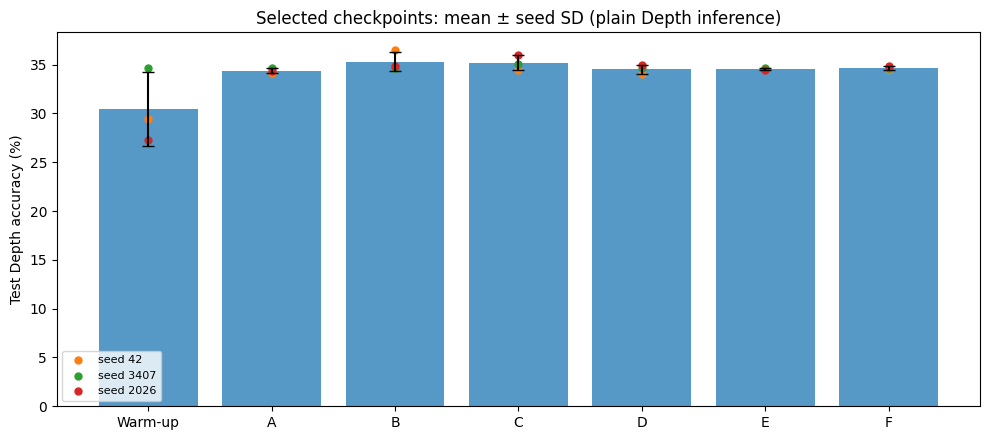

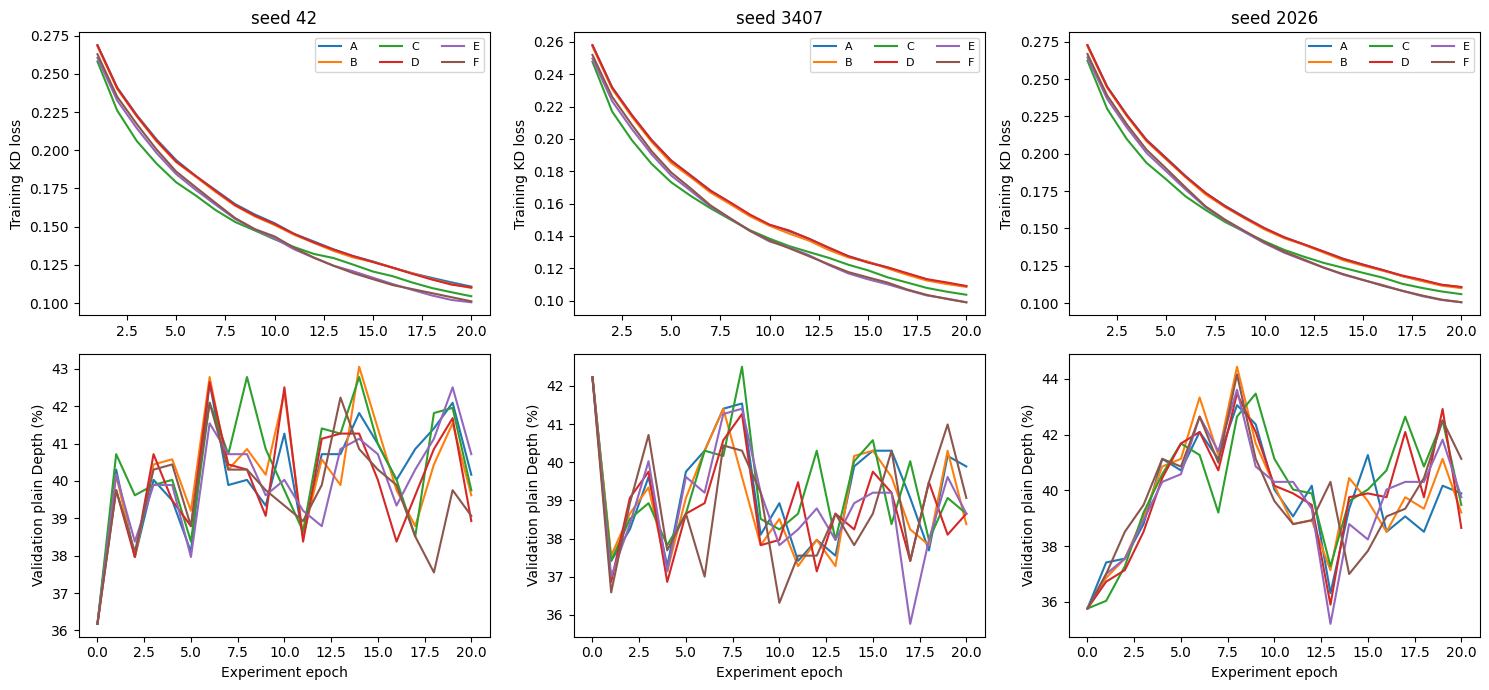

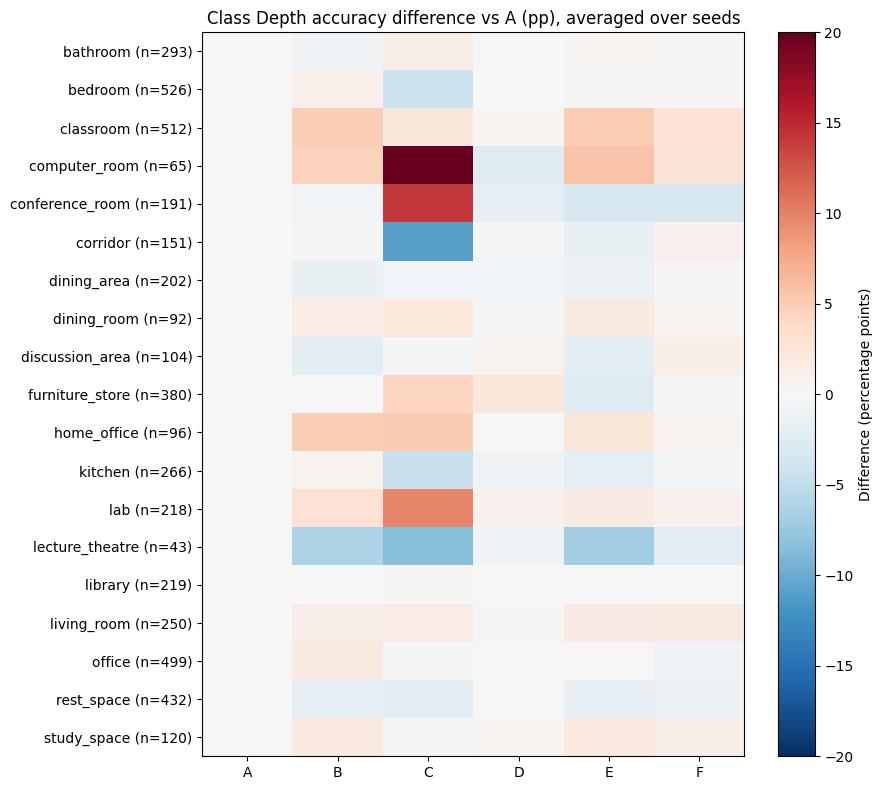

분석 결과 저장 경로: /content/drive/MyDrive/rgb_depth_kd_pilot/v4_attention_semantic/runs/aa278fd83cd6/evaluation_c451ccdb9fe1/analysis
해석: 표준편차는 seed 변동이며 신뢰구간이나 유의성 검정 결과가 아니다.
C paired 성능은 plain Depth validation으로 선택한 동일 checkpoint의 결과다.

Cell 20 완료 — V4 비교표·seed 차이·클래스 분석·학습 곡선 저장 완료


In [ ]:
# Cell 20 — Final tables, seed differences, learning curves and class analysis
assert len(TEST_SUMMARY) == 21 and len(LATENCY_SUMMARY) == 21
assert TEST_SUMMARY.groupby("mode").size().eq(3).all()

ANALYSIS_DIR = EVAL_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

mode_order = ["WARMUP"] + list(CFG["modes"])
metric_names = ["test_rgb_acc", "test_depth_acc", "test_mean_acc"]

stats = (
    TEST_SUMMARY.groupby("mode")[metric_names]
    .agg(["mean", "std"])
    .reindex(mode_order)
)
depth_by_seed = (
    TEST_SUMMARY.pivot(
        index="seed", columns="mode", values="test_depth_acc"
    )
    .reindex(CFG["seeds"])
)


def mean_std_percent(series):
    return (
        f"{100 * series.mean():.2f} ± "
        f"{100 * series.std(ddof=1):.2f}"
    )


# 1. 최종 비교표
final_rows = []

for mode in mode_order:
    group = TEST_SUMMARY[TEST_SUMMARY["mode"] == mode]
    timed = LATENCY_SUMMARY[
        (LATENCY_SUMMARY["mode"] == mode)
        & (LATENCY_SUMMARY["scope"] == "DEPTH_ONLY")
    ]

    final_rows.append({
        "mode": mode,
        "inference": "Depth only",
        "RGB (%)": mean_std_percent(group["test_rgb_acc"]),
        "Depth (%)": mean_std_percent(group["test_depth_acc"]),
        "Mean (%)": mean_std_percent(group["test_mean_acc"]),
        "Depth delta vs A (pp)": 100 * (
            group["test_depth_acc"].mean()
            - stats.loc["A_UNIFORM", ("test_depth_acc", "mean")]
        ),
        "Latency median (ms)": timed["median_ms"].mean(),
        "Parameters (M)": timed["deployed_parameters"].mean() / 1e6,
        "epoch 0 selected": (
            int(group["best_epoch"].eq(0).sum())
            if mode != "WARMUP" else None
        ),
    })

c_group = TEST_SUMMARY[TEST_SUMMARY["mode"] == "C_ADAPTER"]
c_timing = LATENCY_SUMMARY[
    LATENCY_SUMMARY["scope"] == "RGB_DEPTH_ADAPTER"
]

final_rows.append({
    "mode": "C_ADAPTER",
    "inference": "RGB + Depth adapter",
    "RGB (%)": mean_std_percent(c_group["test_rgb_acc"]),
    "Depth (%)": mean_std_percent(c_group["test_paired_depth_acc"]),
    "Mean (%)": mean_std_percent(c_group["test_paired_mean_acc"]),
    "Depth delta vs A (pp)": 100 * (
        c_group["test_paired_depth_acc"].mean()
        - stats.loc["A_UNIFORM", ("test_depth_acc", "mean")]
    ),
    "Latency median (ms)": c_timing["median_ms"].mean(),
    "Parameters (M)": c_timing["deployed_parameters"].mean() / 1e6,
    "epoch 0 selected": int(c_group["best_epoch"].eq(0).sum()),
})

FINAL_TABLE = pd.DataFrame(final_rows)

print("최종 성능: 평균 ± seed 간 표본 표준편차")
print("Latency: seed별 median의 평균; WARMUP latency는 미측정")
display(FINAL_TABLE.round(3))

FINAL_TABLE.to_csv(ANALYSIS_DIR / "final_table.csv", index=False)
stats.to_csv(ANALYSIS_DIR / "test_statistics.csv")


# 2. Seed별 차이
SEED_DELTAS = 100 * depth_by_seed[CFG["modes"]].sub(
    depth_by_seed["A_UNIFORM"], axis=0
)
SEED_DELTAS["E minus F"] = 100 * (
    depth_by_seed["E_ATTN_SEMANTIC"]
    - depth_by_seed["F_SHUFFLED_RGB"]
)
SEED_DELTAS["C paired minus plain"] = 100 * (
    c_group.set_index("seed")["test_paired_depth_acc"]
    - depth_by_seed["C_ADAPTER"]
)

print("Seed별 Depth 차이 (%p)")
display(SEED_DELTAS.round(3))
SEED_DELTAS.to_csv(ANALYSIS_DIR / "seed_depth_deltas.csv")


# 3. 저장된 예측으로 클래스별 정확도 계산
# 추가 모델 추론이나 학습은 수행하지 않는다.
class_rows = []
reference_pos, reference_labels = None, None

for row in TEST_SUMMARY.itertuples(index=False):
    payload = torch.load(
        row.prediction_path,
        map_location="cpu",
        weights_only=True,
    )
    identity = payload["identity"]
    predictions = payload["predictions"]

    assert identity["eval_id"] == EVAL_ID
    assert identity["seed"] == row.seed
    assert identity["mode"] == row.mode

    pos = predictions["pos"].numpy()
    labels = predictions["label"].numpy()

    if reference_pos is None:
        reference_pos = pos.copy()
        reference_labels = labels.copy()

    assert np.array_equal(pos, reference_pos)
    assert np.array_equal(labels, reference_labels)
    assert len(pos) == row.test_samples
    assert abs(
        np.mean(predictions["depth"].numpy() == labels)
        - row.test_depth_acc
    ) < 1e-10

    scopes = [("Depth only", "depth")]
    if row.mode == "C_ADAPTER":
        scopes.append(("RGB + Depth adapter", "paired_depth"))

    for scope, key in scopes:
        correct = predictions[key].numpy() == labels

        for class_id, class_name in enumerate(CFG["class_names"]):
            mask = labels == class_id
            class_rows.append({
                "seed": row.seed,
                "mode": row.mode,
                "inference": scope,
                "class": class_name,
                "support": int(mask.sum()),
                "depth_acc": (
                    float(correct[mask].mean())
                    if mask.any() else np.nan
                ),
            })

CLASS_RESULTS = pd.DataFrame(class_rows)
CLASS_SUMMARY = (
    CLASS_RESULTS.groupby(
        ["mode", "inference", "class"], sort=False
    )
    .agg(
        support=("support", "first"),
        depth_mean=("depth_acc", "mean"),
        depth_std=("depth_acc", "std"),
    )
)

CLASS_RESULTS.to_csv(
    ANALYSIS_DIR / "class_depth_by_seed.csv", index=False
)
CLASS_SUMMARY.to_csv(ANALYSIS_DIR / "class_depth_summary.csv")

class_plain = CLASS_RESULTS[
    CLASS_RESULTS["inference"] == "Depth only"
]
class_accuracy = (
    class_plain.groupby(["class", "mode"])["depth_acc"]
    .mean()
    .unstack()
    .reindex(CFG["class_names"])
)
CLASS_DELTA = 100 * class_accuracy[CFG["modes"]].sub(
    class_accuracy["A_UNIFORM"], axis=0
)
class_support = (
    CLASS_RESULTS.groupby("class")["support"]
    .first()
    .reindex(CFG["class_names"])
)

print("클래스별 Depth 개선 (%p); support는 test 샘플 수")
display(CLASS_DELTA.assign(support=class_support).round(3))
CLASS_DELTA.to_csv(
    ANALYSIS_DIR / "class_depth_delta_vs_A.csv"
)


# 4. 학습 기록 및 epoch 예산 분석
histories, budget_rows = [], []
warmup_val = WARMUP_SUMMARY.set_index("seed")["val_depth_acc"]

for seed, mode in EXPERIMENT_PLAN:
    history = pd.read_csv(
        experiment_paths(seed, mode)["history"]
    )

    assert history["epoch"].tolist() == list(range(1, 21))
    assert history["seed"].eq(seed).all()
    assert history["mode"].eq(mode).all()

    histories.append(history)

    best10 = max(
        float(warmup_val.loc[seed]),
        history.loc[
            history.epoch <= 10, "val_depth_acc"
        ].max(),
    )
    best20 = max(
        float(warmup_val.loc[seed]),
        history["val_depth_acc"].max(),
    )

    budget_rows.append({
        "seed": seed,
        "mode": mode,
        "best_val_depth_0_to_10": best10,
        "best_val_depth_0_to_20": best20,
        "extra_val_gain_pp": 100 * (best20 - best10),
    })

TRAIN_HISTORY = pd.concat(histories, ignore_index=True)
EPOCH_BUDGET_CHECK = pd.DataFrame(budget_rows)

TRAIN_HISTORY.to_csv(
    ANALYSIS_DIR / "all_training_history.csv", index=False
)
EPOCH_BUDGET_CHECK.to_csv(
    ANALYSIS_DIR / "epoch_budget_validation.csv", index=False
)

print(
    "10→20 epoch 추가 validation 개선 (%p). "
    "10-epoch test 성능을 나타내는 표는 아니다."
)
display(
    EPOCH_BUDGET_CHECK.pivot(
        index="seed", columns="mode", values="extra_val_gain_pp"
    ).round(3)
)


# 5. Test Depth 비교 그래프
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(mode_order))

ax.bar(
    x,
    100 * stats[("test_depth_acc", "mean")],
    yerr=100 * stats[("test_depth_acc", "std")],
    capsize=4,
    alpha=0.75,
)

for seed in CFG["seeds"]:
    ax.scatter(
        x,
        100 * depth_by_seed.loc[seed, mode_order],
        label=f"seed {seed}",
        s=25,
    )

ax.set_xticks(
    x,
    [
        m.split("_")[0] if m != "WARMUP" else "Warm-up"
        for m in mode_order
    ],
)
ax.set_ylabel("Test Depth accuracy (%)")
ax.set_title(
    "Selected checkpoints: mean ± seed SD "
    "(plain Depth inference)"
)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(
    ANALYSIS_DIR / "test_depth_comparison.png", dpi=180
)
plt.show()
plt.close(fig)


# 6. Seed별 학습 곡선
fig, axes = plt.subplots(
    2, len(CFG["seeds"]), figsize=(15, 7), squeeze=False
)

for column, seed in enumerate(CFG["seeds"]):
    for mode in CFG["modes"]:
        h = TRAIN_HISTORY[
            (TRAIN_HISTORY.seed == seed)
            & (TRAIN_HISTORY["mode"] == mode)
        ]

        axes[0, column].plot(
            h.epoch, h.loss, label=mode.split("_")[0]
        )
        axes[1, column].plot(
            [0] + h.epoch.tolist(),
            [100 * warmup_val.loc[seed]]
            + (100 * h.val_depth_acc).tolist(),
        )

    axes[0, column].set_title(f"seed {seed}")
    axes[0, column].set_ylabel("Training KD loss")
    axes[0, column].legend(ncol=3, fontsize=8)
    axes[1, column].set_ylabel("Validation plain Depth (%)")
    axes[1, column].set_xlabel("Experiment epoch")

fig.tight_layout()
fig.savefig(ANALYSIS_DIR / "learning_curves.png", dpi=180)
plt.show()
plt.close(fig)


# 7. 클래스별 A 대비 성능 차이
fig, ax = plt.subplots(figsize=(9, 8))
limit = max(
    1.0, float(np.nanmax(np.abs(CLASS_DELTA.to_numpy())))
)

im = ax.imshow(
    CLASS_DELTA.to_numpy(),
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
    aspect="auto",
)
ax.set_xticks(
    range(len(CFG["modes"])),
    [m.split("_")[0] for m in CFG["modes"]],
)
ax.set_yticks(
    range(len(CFG["class_names"])),
    [
        f"{name} (n={int(class_support.loc[name])})"
        for name in CFG["class_names"]
    ],
)
ax.set_title(
    "Class Depth accuracy difference vs A (pp), "
    "averaged over seeds"
)
fig.colorbar(
    im, ax=ax, label="Difference (percentage points)"
)

fig.tight_layout()
fig.savefig(
    ANALYSIS_DIR / "class_depth_deltas.png", dpi=180
)
plt.show()
plt.close(fig)

print("분석 결과 저장 경로:", ANALYSIS_DIR)
print(
    "해석: 표준편차는 seed 변동이며 "
    "신뢰구간이나 유의성 검정 결과가 아니다."
)
print(
    "C paired 성능은 plain Depth validation으로 선택한 "
    "동일 checkpoint의 결과다."
)
print(
    "\nCell 20 완료 — V4 비교표·seed 차이·"
    "클래스 분석·학습 곡선 저장 완료"
)